In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, glob, json
from pathlib import Path
import numpy as np
import jax
from jax import value_and_grad, jit, vmap, grad, random
import jax.numpy as jnp
import flax.linen as nn
import jax.lax as lax
from flax import serialization
import matplotlib.pyplot as plt
import optax

from action_angle_networks.sk_models import MyActionAngleNetwork
from action_angle_networks.simulation import harmonic_motion_simulation as hsim
from functools import partial
from dataclasses import dataclass
from typing import Any, Callable, Sequence, Optional, List, Tuple, Dict

%config InlineBackend.figure_format = 'retina'


In [3]:
import sys
from pathlib import Path

Path.cwd()

# SRC = (Path.cwd() / "kamiya_asymmetry" / "src").resolve() # /workspace/kamiya_asymmetry/src
# sys.path.insert(0, str(SRC))    

PosixPath('/work/gb20/b20109')

In [4]:
proj_path = (Path.cwd() / "ActionAngleNetworks" ).resolve() # /workspace/kamiya_asymmetry/src
#sys.path.insert(0, str(SRC))   
print(proj_path)

/work/gb20/b20109/ActionAngleNetworks


In [6]:
Path().resolve()

PosixPath('/work/gb20/b20109')

# Simulation 1d harmonic oscillator

\begin{equation}
H(q, p)=\sum_{i=1}^n \frac{p_i^2}{2 m_i}+\frac{k_{\text {wall }}}{2} \sum_{i=1}^n q_i^2+\frac{k_{\text {pair }}}{2} \sum_{1 \leq i < j \leq n} \left( q_i-q_j \right)^2 .
\end{equation}

Or, $H = T + V$, where $T$ is the motion energy and 
\begin{equation}
T = \frac{1}{2} p^\top M p,
\end{equation}
and
\begin{equation}
V=\frac{1}{2} q^\top\left(k_{\mathrm{wall}} I+k_{\mathrm{pair}}\left(n I-\mathbf{1 1}^{\top}\right)\right) q.
\end{equation}

### 等方振動子

$\omega > 0$ に対して

$$
H=\frac{1}{2} \sum_{i=1}^n\left(p_i^2+\omega^2 q_i^2\right),
$$

で与えられる系を等方振動子という. 

$$
\varphi: (\theta, I) \mapsto (q, p) =  \left(\sqrt{\frac{2I}{\omega}}\sin\theta, \sqrt{2I\omega}\cos\theta\right)
$$

により, $h= \varphi^*H = \omega(I_1 +\dots+I_n)$ となり, $\omega(I) = \nabla_I h = (\omega, \dots, \omega)$ であるから,
$$
\Lambda = \{k\in\mathbb{Z}^n \mid k_1+\dots+k_n=0\} \cong \mathbb{Z}^{n-1}. 
$$

基本ベクトル差 $k = e_i-e_j\in\Lambda\; (1 \le i < j \le n)$ に対して

$$
S_{e_i-e_j} = \sin(\theta_i-\theta_j) =\frac{L_{ij}}{2\sqrt{I_iI_j}},\quad 
C_{e_i-e_j} = \cos(\theta_i-\theta_j) = \frac{F_{ij}}{2\omega\sqrt{I_iI_j}}.
$$

ここで $L_{ij} = q_ip_j - q_jp_i$ は角運動量テンソル, $F_{ij}= p_ip_j + \omega^2q_iq_j$ はFradkin対称テンソル. 

**複素数を用いた表現**

また, 各 $1 \le i \le n$ に対して 

$$
a_i=\sqrt{I_i} e^{i \theta_i}=\frac{1}{\sqrt{2 \omega}}\left(\omega q_i+i p_i\right)
$$

とする. 行列

$$
\begin{align*}
Q_{i j}&:=a_i a_j^*=\sqrt{I_i I_j} e^{i\left(\theta_i-\theta_j\right)} \\
&= \underbrace{\sqrt{I_i I_j} \cos \left(\theta_i-\theta_j\right)}_{=F_{i j} /(2 \omega)}+i \underbrace{\sqrt{I_i I_j} \sin \left(\theta_i-\theta_j\right)}_{=L_{i j} / 2} .
\end{align*}
$$

を並べた $n\times n$ 行列 $Q=(Q_{ij})$ に対して, Poisson括弧は

$$
\left\{Q_{i j}, Q_{k l}\right\}=i\left(\delta_{j k} Q_{i l}-\delta_{i l} Q_{k j}\right)
$$

となり, これにより $Q_{ij}$ はリー代数 $\mathfrak{u}(n)$ をなす. 



# Define classes
To sample multiple initial values, we first rewirte the code into varialbe initial values.

First, let's sample $m$, $k_{\text{wall}}$ and $k_{\text{pair}}$.

In [8]:
n = 4
T = 1000
dt = 0.01


In [9]:
seed = 42
rng = np.random.default_rng(seed)
m = rng.uniform(*(0.1, 0.3), size=(n,)).astype(np.float64)

k_wall = 5.0
k_pair = 2.5

In [10]:

@dataclass
class HarmonicParamsSInitVal:
    n: int
    m: np.ndarray         # (n,) masses per oscillator
    k_wall: float         # wall spring constant
    k_pair: float         # pairwise coupling spring constant
    # A_modes: np.ndarray   # (n,) amplitudes per normal mode
    # phi_modes: np.ndarray # (n,) phases per normal mode (radians)

def set_harmonic_params(
    n: int,
    m: Tuple[float, ...],
    k_wall: float = 0.01,
    k_pair: float = 0.005,    
) -> HarmonicParamsSInitVal:
    # Normal-mode amplitudes/phases
    # A_modes = rng.uniform(*A_range, size=(n,)).astype(np.float64)
    # phi_modes = rng.uniform(0.0, 2*np.pi, size=(n,)).astype(np.float64)
    return HarmonicParamsSInitVal(
        n=n, m=m, k_wall=float(k_wall), k_pair=float(k_pair),
        # A_modes=A_modes, phi_modes=phi_modes
    )

def harmonic_hamiltonian(q: np.ndarray, p: np.ndarray, params: HarmonicParamsSInitVal) -> float:
    """
    q, p: (B, n)
    """
    n = params.n
    V_wall = 0.5 * params.k_wall * np.sum(q**2, axis=1)  # (B,)
    V_pair = 0.5 * params.k_pair * ((np.sum(q, axis=1)**2 - np.sum(q**2, axis=1))/2.0)  # (B,)
    V = V_wall + V_pair # (B,)
    T = 0.5 * np.sum((p**2) / params.m, axis=1)  # (B,)
    H = T + V
    return float(H)


def harmonic_hamiltonian_jax(q: jnp.ndarray, p: jnp.ndarray, params: HarmonicParamsSInitVal) -> jnp.ndarray:
    """
    q, p: (B, n)  -> returns (B,)
    NOTE: m を jnp に変換して計算
    """
    if isinstance(params, dict):
        m = jnp.asarray(params["m"])
        k_wall = jnp.asarray(params["k_wall"])
        k_pair = jnp.asarray(params["k_pair"])
    else:
        m = jnp.asarray(params.m)
        k_wall = jnp.asarray(params.k_wall)
        k_pair = jnp.asarray(params.k_pair)
    V_wall = 0.5 * k_wall * jnp.sum(q**2, axis=1)  # (B,)
    V_pair = 0.5 * k_pair * (
        (jnp.sum(q, axis=1) ** 2 - jnp.sum(q**2, axis=1)) / 2.0
    )
    T = 0.5 * jnp.sum((p**2) / m, axis=1)  # (B,)
    return T + V_wall + V_pair  # (B,)

def equation_of_motion(q: jnp.ndarray, p: jnp.ndarray, params: HarmonicParamsSInitVal) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Returns the time derivatives of the positions and momenta.
    """
    dqdt = p / params.m[None, :]  # (B, n)
    I = np.eye(n)
    J = np.ones((n, n))
    L = -(params.k_wall + n * params.k_pair) * I + params.k_pair * J
    dpdt = jnp.matmul(q, jnp.asarray(L).T)  # (B, n)
    #dpdt = -jnp.gradient(harmonic_hamiltonian_jax(q, p, params), axis=1)  # (B, n)
    return dqdt, dpdt

def _normal_mode_eigendecomposition(params: HarmonicParamsSInitVal):
    """
    Returns eigenvalues/eigenvectors for q¨ = M^{-1} L q.
    Repoに合わせて L = -(k_wall + n*k_pair) I + k_pair 1 1^T を用い、
    固有値は負になる（w = sqrt(-eigvals)）。
    """
    n = params.n
    I = jnp.eye(n)
    J = jnp.ones((n, n))
    L = -(params.k_wall + n * params.k_pair) * I + params.k_pair * J
    M_sqrt_inv = jnp.diag(1.0 / jnp.sqrt(params.m))

    # 対称化
    S = M_sqrt_inv @ L @ M_sqrt_inv
    eigvals, U = jnp.linalg.eigh(S)              # 決定的になりやすい
    V = M_sqrt_inv @ U                          # 元の一般化固有ベクトルへ
    return eigvals.real, V.real                 # (n,), (n,n)

    # M_inv = np.diag(1.0 / params.m)
    # M_inv_L = M_inv @ L
    # eigvals, eigvecs = np.linalg.eig(M_inv_L)
    # eigvals = eigvals.real
    # eigvecs = eigvecs.real
    # return eigvals, eigvecs  # (n,), (n,n)

def initial_modes_from_qp(q0, p0, m, V, w, eps=1e-12):
    """
    q0, p0: (n,)
    m: (n,), V: (n,n) with columns = mode vectors (your aux["eigvecs"])
    w: (n,) angular frequencies
    returns: A_modes (n,), phi_modes (n,)
    """
    M = jnp.diag(jnp.asarray(m))
    q0 = jnp.asarray(q0); p0 = jnp.asarray(p0)
    V = jnp.asarray(V);   w  = jnp.asarray(w)

    q_mode0   = V.T @ (M @ q0)        # shape (n,)
    qdot_mode0= V.T @ p0              # since p = M qdot

    # handle near-zero frequencies safely
    w_safe = jnp.where(w < eps, eps, w)

    A = jnp.sqrt(q_mode0**2 + (qdot_mode0 / w_safe)**2)
    phi = jnp.arctan2(-qdot_mode0 / w_safe, q_mode0)

    # (optional) if you truly have zero-frequency modes (e.g., k_wall=0),
    # their motion is linear in time and (A, phi) is not well-defined.
    # You can mark them, or set (A, phi) via a convention:
    zero_mask = (w < eps)
    # e.g., keep A = |q_mode0|, phi = 0 for zeros (or any consistent choice)
    A = jnp.where(zero_mask, jnp.abs(q_mode0), A)
    phi = jnp.where(zero_mask, 0.0, phi)

    return A, phi


def simulate_coupled_1d_harmonic_init_values(
    params: HarmonicParamsSInitVal,
    num_steps: int,
    dt: float,
    q0: jnp.ndarray,
    p0: jnp.ndarray
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, Dict]:
    """
    Returns:
      t: (T,)
      q: (T, n) positions
      p: (T, n) momenta  (p = m * dq/dt)
      aux: dict with eigvals/eigvecs/w
    """
    n = params.n
    t = jnp.arange(num_steps, dtype=jnp.float64) * float(dt)

    # Normal modes
    eigvals, V = _normal_mode_eigendecomposition(params)
    w = jnp.sqrt(jnp.clip(-eigvals, a_min=0.0, a_max=None))  # angular freq

    # compute A_modes, phi_modes from (q0, p0)
    M = jnp.diag(jnp.asarray(params.m))
    q_mode0   = V.T @ (M @ q0)        # shape (n,)
    qdot_mode0= V.T @ p0              # since p = M qdot

    # # handle near-zero frequencies safely
    # w_safe = jnp.where(w < eps, eps, w)

    A = jnp.sqrt(q_mode0**2 + (qdot_mode0 / w)**2)
    phi = jnp.arctan2(-qdot_mode0 / w, q_mode0)

    # Mode-space trajectories
    Wt_phi = t[:, None] * w[None, :] + phi[None, :]  # (T, n)
    q_mode = A[None, :] * jnp.cos(Wt_phi)              # (T, n)
    qdot_mode = -A[None, :] * (w[None, :]) * jnp.sin(Wt_phi)  # (T, n)

    # Map back to physical coords: q = V q_mode, qdot = V qdot_mode
    q = q_mode @ V.T
    qdot = qdot_mode @ V.T
    p = qdot * params.m[None, :]  # momentum = m * qdot

    aux = {"eigvals": eigvals, "eigvecs": V, "w": w}
    return t, q, p, aux

def flow_coupled_1d_harmonic_init_values(
    params: HarmonicParamsSInitVal,
    num_steps: tuple[int, ...],
    dt: float,
    q0: jnp.ndarray,
    p0: jnp.ndarray
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, Dict]:
    """
    Returns:
      t: tuple with B integers, times for each batch
      q0: (B, n) positions for each batch
      p0: (B, n) momenta  (p = m * dq/dt) for each batch
      aux: dict with eigvals/eigvecs/w
    """
    n = params.n
    # t = jnp.arange(num_steps, dtype=jnp.float64) * float(dt)
    t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)

    # Normal modes
    eigvals, V = _normal_mode_eigendecomposition(params)
    w = jnp.sqrt(jnp.clip(-eigvals, a_min=0.0, a_max=None))  # (n,) angular freq

    # compute A_modes, phi_modes from (q0, p0)
    M = jnp.diag(jnp.asarray(params.m)) # (n,n)
    # M_inv = jnp.diag(jnp.asarray(1. / params.m)) # (n,n)
    q_mode0   = (q0 @ M) @ V    # elementwis
    qdot_mode0= p0 @ V              # since p = M qdot

    # q_mode0   = V.T @ (M @ q0)        # shape (n,)
    # qdot_mode0= V.T @ p0              # since p = M qdot

    # # handle near-zero frequencies safely
    # w_safe = jnp.where(w < eps, eps, w)

    A = jnp.sqrt(q_mode0**2 + (qdot_mode0 / w)**2) # (B,n)
    phi = jnp.arctan2(-qdot_mode0 / w, q_mode0)    # (B,n)

    # Mode-space trajectories
    wt_phi = t[:, None] * w[None, :] + phi    # (B, n)
    q_mode = A * jnp.cos(wt_phi)              # (B, n)
    qdot_mode = -A * (w[None, :]) * jnp.sin(wt_phi)  # (B, n)

    # Map back to physical coords: q = V q_mode, qdot = V qdot_mode
    q = q_mode @ V.T
    qdot = qdot_mode @ V.T
    p = qdot * params.m[None, :]  # momentum = m * qdot

    aux = {"eigvals": eigvals, "eigvecs": V, "w": w}
    return t, q, p, aux


In [11]:

B = 300
Ts = tuple(np.arange(0, B).tolist())
#Ts = tuple(np.random.randint(500, 1500, size=(B,)).tolist())
t, q, p, aux = flow_coupled_1d_harmonic_init_values(
    params=set_harmonic_params(n=n, m=m, k_wall=k_wall, k_pair=k_pair),
    num_steps=Ts,
    dt=0.01,
    q0=jax.random.normal(jax.random.PRNGKey(0), (1,n)),
    p0=jax.random.normal(jax.random.PRNGKey(0), (1,n)),
)



/tmp/ipykernel_135/4020243990.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


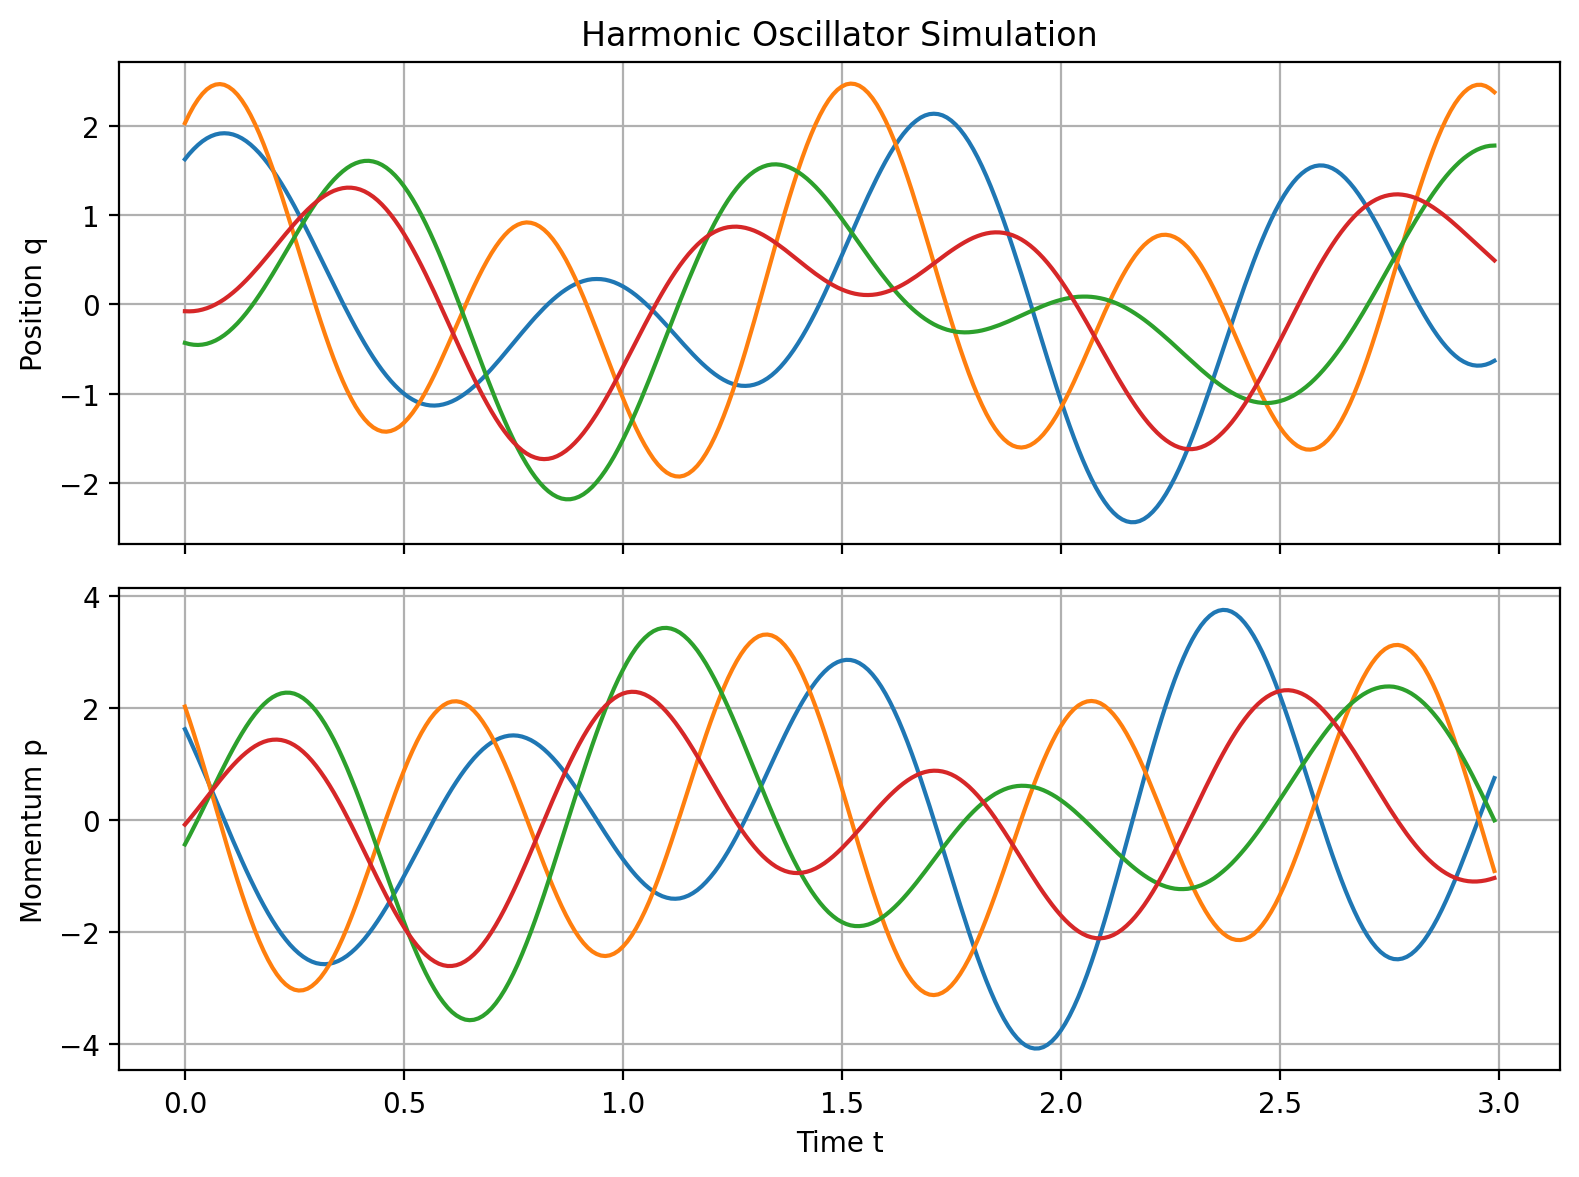

In [12]:
# plot q and p
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t, q)
ax[0].set_ylabel('Position q')
ax[0].set_title('Harmonic Oscillator Simulation')
ax[0].grid()
ax[1].plot(t, p)
ax[1].set_ylabel('Momentum p')
ax[1].set_xlabel('Time t')
ax[1].grid()
plt.tight_layout()
plt.show()


fig.savefig(str(proj_path / "results" / "e2025_1109_hhn_vs_aan_cleaner" / "gt_traj_plot.pdf"), bbox_inches="tight")  # PDFで保存

# Prepare the dataset
Here we settle up the dataset for training. Let $x=(q, p) \in X,\; \dot{x} = (\dot{q}, \dot{p})$, and the flow $\varphi_t: X \to X$ follow $\dot{x} = J\nabla_xH$. We define the dataset $\mathcal{D}$ as
\begin{equation}
\mathcal{D} = \{(x_0, \dot{x}_0, x(t), t) \mid x_0 \in X,\; \dot{x}_0 = J\nabla H(x_0),\; x(t) = \varphi_t(x),\; t\in\mathbb{R}_{>0}\}.
\end{equation}

To create such a dataset (technically, a finite subset of the dataset define above), we sample 
+ $x_0$ from a compact set
+ $t$ with an upper bount $t_{\text{max}}$


In [13]:
#hyper_params = set_harmonic_params(n=n, m=m, k_wall=k_wall, k_pair=k_pair)
hyper_params = set_harmonic_params(n=n, m=m[:n], k_wall=k_wall, k_pair=k_pair)



In [14]:
def create_dataset(x0, steps, dt=dt, hyper_params=hyper_params):
    """
    x0: (B, 2n) initial conditions
    steps: (B,) time steps for each batch
    Returns:
    x0: (B, 2n)
    x0_dot: (B, 2n)
    xt: (B, 2n)
    t: (B,)
    """
    B, dim = x0.shape
    n = dim // 2
    q0 = x0[:, :n]
    p0 = x0[:, n:]

    t, q, p, _ = flow_coupled_1d_harmonic_init_values(
        params=set_harmonic_params(n=n, m=hyper_params.m, k_wall=hyper_params.k_wall, k_pair=hyper_params.k_pair),
        num_steps=tuple(steps.tolist()),
        dt=dt,
        q0=q0,
        p0=p0
    )
    xt = jnp.concatenate([q, p], axis=1)  # (B, 2n)

    # compute x0_dot
    dqdt0 = p0 / hyper_params.m[None, :]  # (B, n)
    I = np.eye(n)
    J = np.ones((n, n))
    L = -(hyper_params.k_wall + n * hyper_params.k_pair) * I + hyper_params.k_pair * J
    dpdt0 = jnp.matmul(q0, jnp.asarray(L).T)  # (B, n)
    x0_dot = jnp.concatenate([dqdt0, dpdt0], axis=1)  # (B, 2n)

    return x0, x0_dot, xt, t
    

In [15]:
N_train = 5000
N_test  = 5000
delta_t_max = 0.1
train_t_dist = "LNP" # "uniform", "step_scheduling", "LNP", "step_scheduling_over_all_epochs"

# delta_t_max_test = 0.5

# Below ignored unless "LNP"
delta_t_mean = 0.1
sigma2 = 0.2

# Below ignored unless "step_scheduling_over_all_epochs"
# epochs = 200

key = jax.random.PRNGKey(0)
q_train_key, p_train_key, dt_train_key, key = jax.random.split(key, 4)
q0_train = jax.random.uniform(q_train_key, shape=(N_train, n), minval=-3.0, maxval=3.0)
p0_train = jax.random.uniform(p_train_key, shape=(N_train, n), minval=-3.0, maxval=3.0)

if train_t_dist == "uniform":
    delta_t_train = jnp.clip(
        dt * jax.random.randint(dt_train_key, shape=(N_train,), minval=1, maxval=delta_t_max),
        min=dt,
        max=delta_t_max
    )
elif train_t_dist == "step_scheduling":
    unif_vec = jax.random.uniform(dt_train_key, shape=(N_train,), minval=0.0, maxval=1.0)
    delta_t_train = jnp.clip(
        dt * jnp.ceil( unif_vec * ((delta_t_max * jnp.arange(N_train)/N_train)//dt)),
        min=dt,
        max=delta_t_max
    )
elif train_t_dist == "LNP":
    sigma2 =  1.0 / 2.0
    dt_train_key, dt_train_key2 = jax.random.split(dt_train_key, 2)
    tau = jnp.sqrt(sigma2) * jax.random.normal( key=dt_train_key, shape=(N_train,) ) + jnp.log( float(delta_t_mean//dt-1) ) - 0.5 * sigma2
    # tau ~ N(log(T_mean-1)-0.5*sigma^2, sigma)
    delta_t_train = dt* (jax.random.poisson(key=dt_train_key2, lam=jnp.exp(tau)) + 1)
# elif train_t_dist == "step_scheduling_over_all_epochs":
#     delta_t_train = jnp.clip(
#         dt * jax.random.randint(dt_train_key, shape=(epochs*N_train,), minval=1, maxval=delta_t_max),
#         min=dt,
#         max=delta_t_max
#     )

step_counts_train = jnp.maximum(1, jnp.round(delta_t_train / dt).astype(int))
train_dataset = create_dataset(
    x0=jnp.concatenate([q0_train, p0_train], axis=1),
    steps=step_counts_train,
    dt=dt,
    hyper_params=hyper_params
)


/tmp/ipykernel_135/4020243990.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


In [16]:
# q_test_key, p_test_key, dt_test_key = jax.random.split(key, 3)
# q0_test = jax.random.uniform(q_test_key, shape=(N_test, n), minval=-3.0, maxval=3.0)
# p0_test = jax.random.uniform(p_test_key, shape=(N_test, n), minval=-3.0, maxval=3.0)
# delta_t_test = jax.random.uniform(dt_test_key, shape=(N_test,), minval=dt, maxval=delta_t_max_test)


# step_counts_test = jnp.maximum(1, jnp.round(delta_t_test / dt).astype(int))


# test_dataset = create_dataset(
#     x0=jnp.concatenate([q0_test, p0_test], axis=1),
#     steps=step_counts_test,
#     dt=dt,
#     hyper_params=hyper_params
# )

In [17]:
# # another way to create training
# # use short trajectories
# N_train_traj = 500
# l_traj = 10
# q_train_key, p_train_key, dt_train_key = jax.random.split(key, 3)
# q0_train = jax.random.uniform(q_train_key, shape=(N_train_traj, n), minval=-3.0, maxval=3.0)
# p0_train = jax.random.uniform(p_train_key, shape=(N_train_traj, n), minval=-3.0, maxval=3.0)

# steps_to_train = [i for i in range(1, l_traj+1)]  # 1 to 10 steps

# #delta_t_train = jnp.repeat(jnp.array(steps_to_train, dtype=jnp.float64) * dt, repeats=N_train, axis=0)

# #delta_t_train = jax.random.uniform(dt_train_key, shape=(N_train,), minval=dt, maxval=delta_t_max_train)
# #step_counts_train = jnp.maximum(1, jnp.round(delta_t_train / dt).astype(int))


# train_dataset = create_dataset(
#     x0=jnp.concatenate([jnp.repeat(q0_train, repeats=len(steps_to_train), axis=0), jnp.repeat(p0_train, repeats=len(steps_to_train), axis=0)], axis=1),
#     steps=jnp.tile(jnp.array(steps_to_train, dtype=int), reps=N_train_traj),
#     dt=dt,
#     hyper_params=hyper_params
# )

In [18]:
# another way to create test
# use predetermined steps
q_test_key, p_test_key, dt_test_key = jax.random.split(key, 3)
q0_test = jax.random.uniform(q_test_key, shape=(N_test, n), minval=-3.0, maxval=3.0)
p0_test = jax.random.uniform(p_test_key, shape=(N_test, n), minval=-3.0, maxval=3.0)

steps_to_test = [1,2,5,10,20,50]

delta_t_test = jnp.tile(jnp.array(steps_to_test, dtype=int), reps=N_test) * dt
step_counts_test = jnp.tile(jnp.array(steps_to_test, dtype=int), reps=N_test)
#delta_t_test = jax.random.uniform(dt_test_key, shape=(N_test,), minval=dt, maxval=delta_t_max_test)
#step_counts_test = jnp.maximum(1, jnp.round(delta_t_test / dt).astype(int))


test_dataset = create_dataset(
    x0=jnp.concatenate([jnp.repeat(q0_test, repeats=len(steps_to_test), axis=0), jnp.repeat(p0_test, repeats=len(steps_to_test), axis=0)], axis=1),
    steps=step_counts_test,
    dt=dt,
    hyper_params=hyper_params
)

/tmp/ipykernel_135/4020243990.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


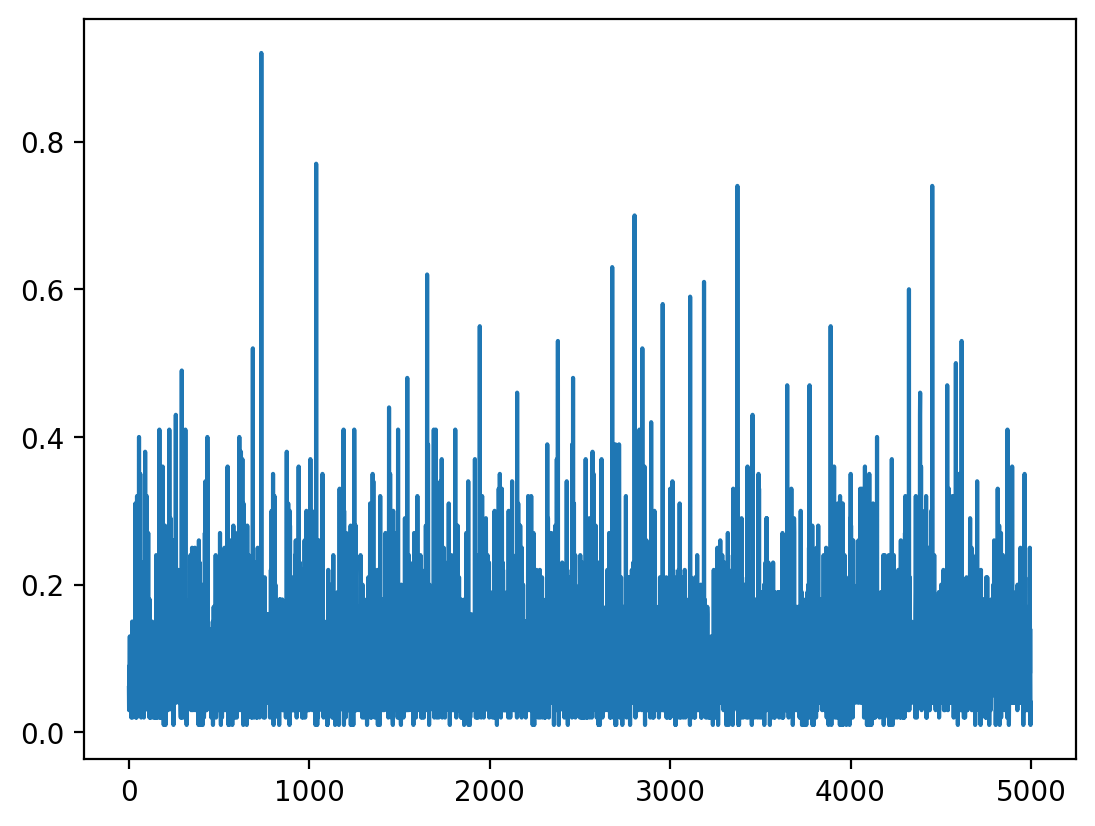

In [19]:
plt.plot(delta_t_train)

In [20]:
test_dataset[0].shape

(30000, 8)

# Build model & train

In [24]:
model = MyActionAngleNetwork(
    dim_config=n,
    dim_hidden=128,
    dim_hidden_list=[32,128,32],
    num_gsblocks=30,
    type_polar="canonical",
    activation=nn.silu,#nn.sigmoid,
    mlp_res_connection=False,
    theta_predictor="gradient",
    learn_scale=False
)


In [25]:
rng = jax.random.PRNGKey(0)
q0 = jnp.zeros((1, int(n)))
p0 = jnp.zeros((1, int(n)))
delta_t0 = jnp.asarray(0.1)

variables = model.init(rng, q0, p0, delta_t0)
params = variables['params']
num_params = sum(jax.tree_util.tree_leaves(jax.tree_util.tree_map(lambda x: x.size, params)))
print(f'Total parameters: {num_params}')


Total parameters: 32065


# Training

In [26]:
def train_step(params,
               opt_state,
               dtst_batch,
               apply_fn,
               tx,
               loss_weights=(1.0, 1.0, 0.0, 0.1),
               action_loss_type='var'):
    x, x_dot, y, delta_t = dtst_batch  # x, x_dot, y: (B, 2n), delta_t: (B,)    
    
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]  # (B, n), (B, n)
    q_dot, p_dot = x_dot[:, :n], x_dot[:, n:]

    
    def loss_fn(pp):
        q_, p_, I, _ = apply_fn({'params': pp}, q, p, delta_t, train=True)

        loss_q_se = ((1./(1.+delta_t))*(((q_ - y[:, :n]) ** 2).sum(axis=1))).sum()#.mean()
        loss_p_se = ((1./(1.+delta_t))*(((p_ - y[:, n:]) ** 2).sum(axis=1))).sum()#.mean()
        
        def H_hat_single(qi, pi):
            return apply_fn({'params': pp}, qi[None, :], pi[None, :],
                            method=model.hamiltonian).squeeze()
        
        def H_of_I_sum(I_in):
            return apply_fn({'params': pp}, I_in, method=model.h_of_I).sum()

        omega = jax.grad(H_of_I_sum)(I)  # (B,n)
        omega_norm = jnp.mean(jnp.linalg.norm(omega, axis=1))  # スカラー

        dHdq_model = jax.vmap(lambda qi, pi: jax.grad(H_hat_single, argnums=0)(qi, pi))(q, p)
        dHdp_model = jax.vmap(lambda qi, pi: jax.grad(H_hat_single, argnums=1)(qi, pi))(q, p)

        L_HNN = ((dHdq_model + p_dot) ** 2).mean() + ((dHdp_model - q_dot) ** 2).mean()

        if action_loss_type=='var':
            L_action = lax.cond(
                loss_weights[2] > 0.0,
                lambda I: jnp.var(I, axis=0).sum(),
                lambda I: 0.0,
                I
            )
        elif action_loss_type=='quadratic_variation':
            L_action = jnp.sum(jnp.square(I[1:, :] - I[:-1, :])) / I.shape[0]


        return (loss_weights[0] * loss_q_se +
                loss_weights[1] * loss_p_se +
                loss_weights[2] * L_action +
                loss_weights[3] * L_HNN), omega_norm

    (loss, omega_norm), grads = value_and_grad(loss_fn, has_aux=True)(params)
    #loss, grads = value_and_grad(loss_fn)(params)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    grad_norm = optax.global_norm(grads)
    return params, opt_state, loss, grad_norm, omega_norm


train_step_jit = jax.jit(train_step, static_argnames=('apply_fn', 'tx'))


In [27]:
@partial(jax.jit, static_argnames=('apply_fn',))
def eval_batch(params, x, y, delta_t, *, apply_fn):
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]

    q_, p_, _, _ = apply_fn({'params': params}, q, p, delta_t, train=False)

    loss_q_se = ((1./(1.+delta_t))*(((q_ - y[:, :n]) ** 2).sum(axis=1))).sum()#.mean()
    loss_p_se = ((1./(1.+delta_t))*(((p_ - y[:, n:]) ** 2).sum(axis=1))).sum()#.mean()
    
    return loss_q_se + loss_p_se


In [28]:
# --- Replace: 学習ループの該当部分 ---
seed = 201
lr = 1e-3
batch_size = 256



In [29]:


epochs = 200
ep_shuffle_chunks = 4

log_every = 50
loss_weights = (1.0, 1.0, 0.0, 0.0)
#delta_t = dt  # base time step
#delta_t_max = 0.5 # max jump multiplier during training


key = jax.random.PRNGKey(seed)
variables = model.init(key, jnp.zeros((1, n)), jnp.zeros((1, n)), jnp.asarray(dt))
nn_params = variables['params']

tx = optax.chain(
    optax.clip_by_global_norm(max_norm=1.0),  # Clip gradients by their global norm
    optax.adam(learning_rate=lr)            # Use Adam optimizer
)
#tx = optax.adam(learning_rate=lr)
opt_state = tx.init(nn_params)

idx_serial_batch = 0
batch_losses = []
grad_norms = []
omega_norms = []

for ep in range(epochs):
    
    if train_t_dist == "step_scheduling":
        if ep == 0:
            x0_train, x0_dot_train, xt_train, t_train = train_dataset
        else:
            # Shuffle training data
            # なんとなくtを最初の方は短く→あとで長くとトレーニングしたいので、何チャンクかにわけてそのチャンク内でシャッフル
            # epochs=1なら関係ない
            for idx_ep in range(ep_shuffle_chunks):
                perm_key, key = jax.random.split(key)
                perm = jax.random.permutation(perm_key, N_train // ep_shuffle_chunks)
                start_idx = idx_ep * (N_train // ep_shuffle_chunks)
                end_idx = (idx_ep + 1) * (N_train // ep_shuffle_chunks)
                x0_train, x0_dot_train, xt_train, t_train = train_dataset
                x0_train = x0_train.at[start_idx:end_idx].set(x0_train[start_idx:end_idx][perm])
                x0_dot_train = x0_dot_train.at[start_idx:end_idx].set(x0_dot_train[start_idx:end_idx][perm])
                xt_train = xt_train.at[start_idx:end_idx].set(xt_train[start_idx:end_idx][perm])
                t_train = t_train.at[start_idx:end_idx].set(t_train[start_idx:end_idx][perm])
    else:
        # Shuffle training data
        perm_key, key = jax.random.split(key)
        perm = jax.random.permutation(perm_key, N_train)
        x0_train, x0_dot_train, xt_train, t_train = train_dataset
        x0_train = x0_train[perm]
        x0_dot_train = x0_dot_train[perm]
        xt_train = xt_train[perm]
        t_train = t_train[perm]
    
    # Mini-batch training
    num_batches = N_train // batch_size
    epoch_loss = 0.0

    for i in range(num_batches):
        batch_x0     = x0_train[i*batch_size:(i+1)*batch_size]
        batch_x0_dot = x0_dot_train[i*batch_size:(i+1)*batch_size]
        batch_xt     = xt_train[i*batch_size:(i+1)*batch_size]
        batch_t      = t_train[i*batch_size:(i+1)*batch_size]

        nn_params, opt_state, batch_loss, grad_norm, omega_norm = train_step_jit(
            nn_params, opt_state,
            (batch_x0, batch_x0_dot, batch_xt, batch_t),
            apply_fn=model.apply, tx=tx,
            loss_weights=loss_weights
        )
        total_batch_loss = batch_loss * len(batch_t)
        epoch_loss += total_batch_loss
        #epoch_loss += batch_loss *         
        batch_losses.append(batch_loss)
        grad_norms.append(grad_norm)
        omega_norms.append(omega_norm)

        if (idx_serial_batch + 1) % log_every == 0:
            print(f"Epoch {ep+1}, Batch {i+1}/{num_batches}, Loss: {batch_loss:.6f}")

        if (idx_serial_batch + 1) % log_every == 0 or idx_serial_batch == 1 or (ep==epochs-1 and i==num_batches-1):
            test_losses = []
            num_test_batches = N_test // batch_size
            for j in range(num_test_batches):
                batch_x0_test = test_dataset[0][j*batch_size:(j+1)*batch_size]
                batch_x0_dot_test = test_dataset[1][j*batch_size:(j+1)*batch_size]
                batch_xt_test = test_dataset[2][j*batch_size:(j+1)*batch_size]
                batch_t_test = test_dataset[3][j*batch_size:(j+1)*batch_size]

                test_loss = eval_batch(
                    nn_params,
                    batch_x0_test,
                    batch_xt_test,
                    batch_t_test,
                    apply_fn=model.apply
                )
                test_losses.append(test_loss * len(batch_t_test))
            total_test_loss = sum(test_losses) / N_test
            print(f"*** Test Loss after {idx_serial_batch} batches: {total_test_loss:.6f} ***")
        
        idx_serial_batch += 1

    epoch_loss /= N_train
    print(f"Epoch {ep+1} completed. Average Loss: {epoch_loss:.6f}")

    


*** Test Loss after 1 batches: 2412011323392.000000 ***
Epoch 1 completed. Average Loss: 615313375232.000000
Epoch 2 completed. Average Loss: 19065806.000000
Epoch 3, Batch 12/19, Loss: 287031.125000
*** Test Loss after 49 batches: 771076.187500 ***
Epoch 3 completed. Average Loss: 443109.000000
Epoch 4 completed. Average Loss: 187802.953125
Epoch 5 completed. Average Loss: 121142.890625
Epoch 6, Batch 5/19, Loss: 57577.117188
*** Test Loss after 99 batches: 115267.476562 ***
Epoch 6 completed. Average Loss: 67764.531250
Epoch 7 completed. Average Loss: 37398.652344
Epoch 8, Batch 17/19, Loss: 13139.908203
*** Test Loss after 149 batches: 17198.425781 ***
Epoch 8 completed. Average Loss: 13338.754883
Epoch 9 completed. Average Loss: 6734.981934
Epoch 10 completed. Average Loss: 5119.897461
Epoch 11, Batch 10/19, Loss: 4856.824219
*** Test Loss after 199 batches: 8434.981445 ***
Epoch 11 completed. Average Loss: 4336.059570
Epoch 12 completed. Average Loss: 4400.268066
Epoch 13 complete

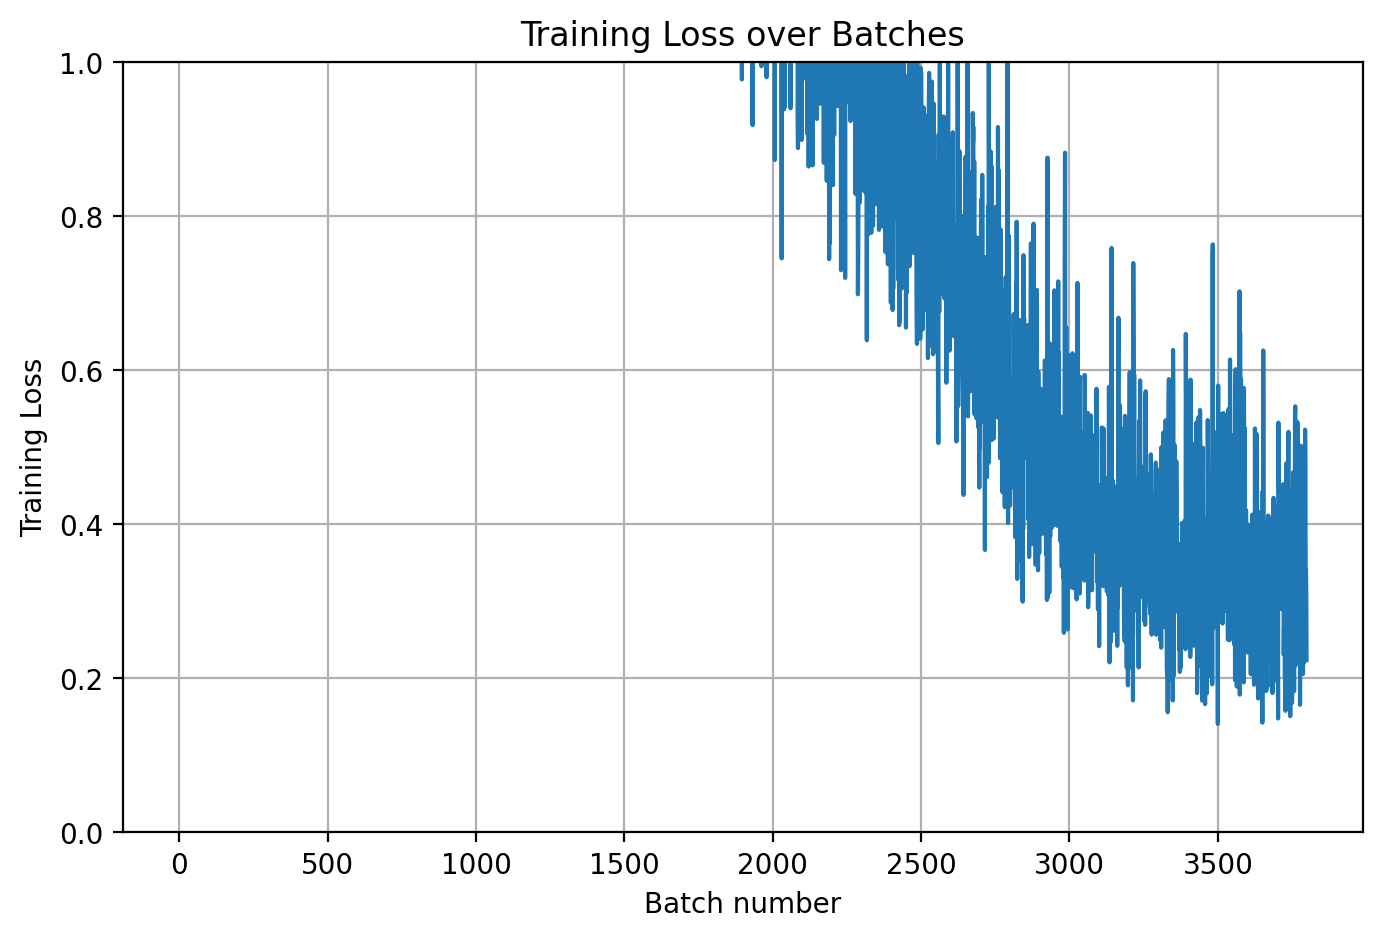

In [33]:
ax, fig = plt.subplots(figsize=(8, 5))
fig.plot(batch_losses)
#fig.set_yscale('log')
fig.set_ylim(0.0, 1.0)
fig.set_xlabel('Batch number')
fig.set_ylabel('Training Loss')
fig.set_title('Training Loss over Batches')
fig.grid()
plt.show()

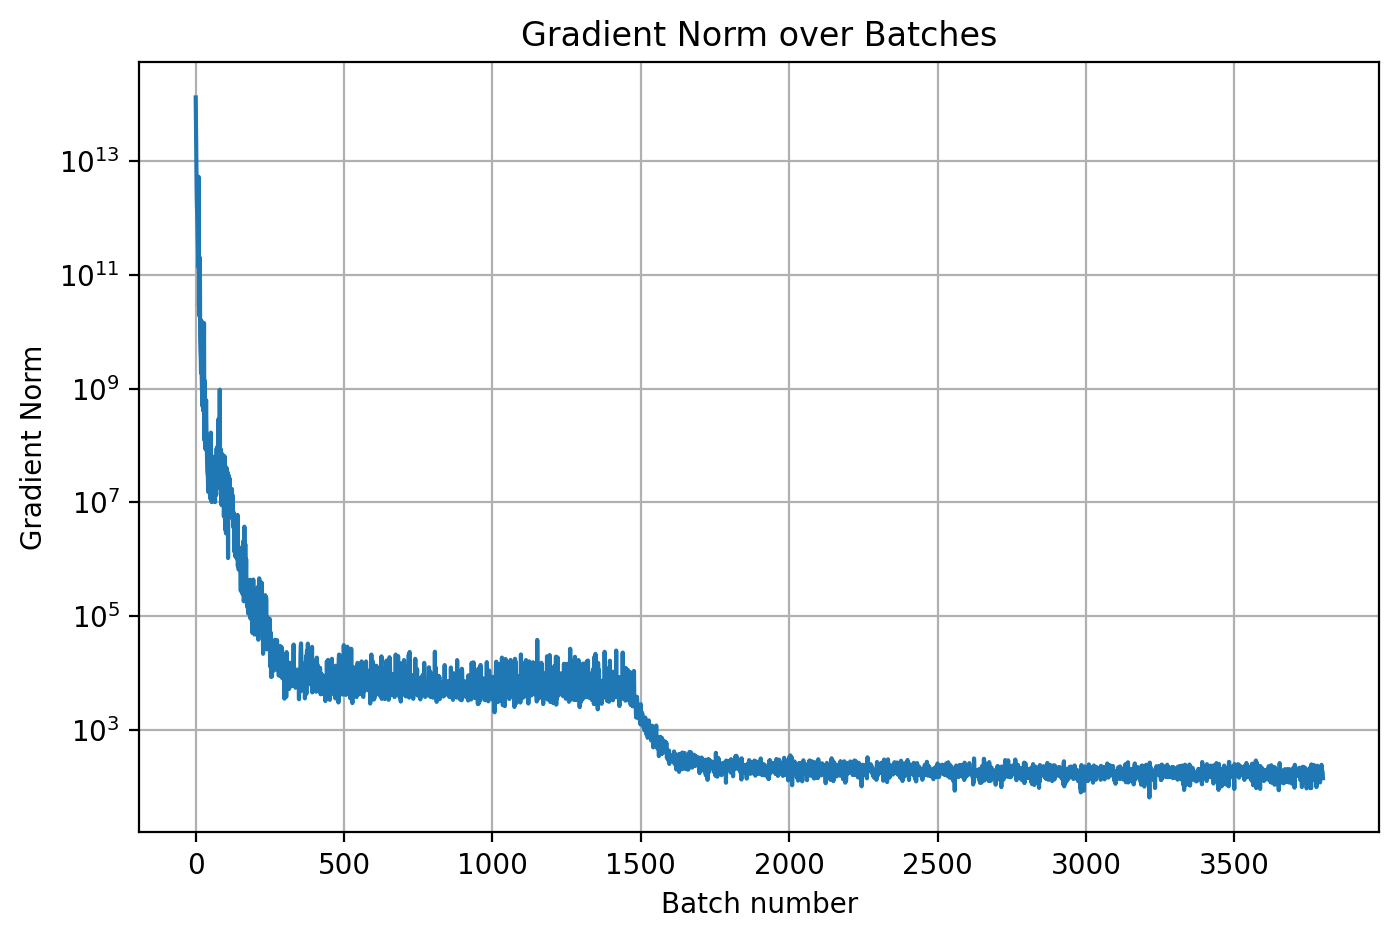

In [34]:
ax, fig = plt.subplots(figsize=(8, 5))
fig.plot(grad_norms)
fig.set_yscale('log')
fig.set_xlabel('Batch number')
fig.set_ylabel('Gradient Norm')
fig.set_title('Gradient Norm over Batches')
fig.grid()
plt.show()

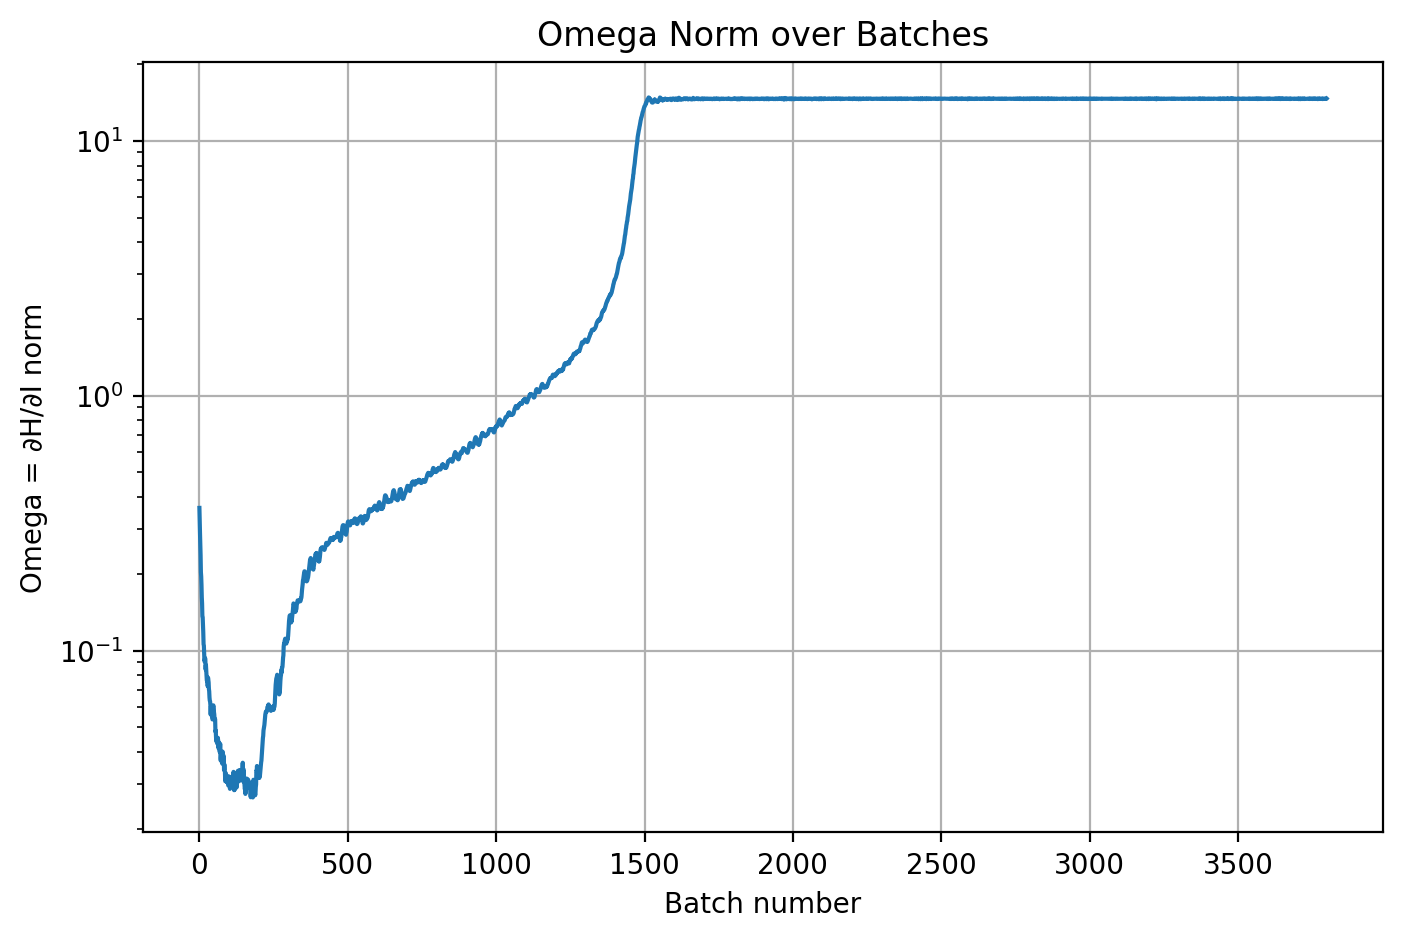

In [35]:
ax, fig = plt.subplots(figsize=(8, 5))
fig.plot(omega_norms)
fig.set_yscale('log')
fig.set_xlabel('Batch number')
fig.set_ylabel('Omega = ∂H/∂I norm')
fig.set_title('Omega Norm over Batches')
fig.grid()
plt.show()

/tmp/ipykernel_135/4020243990.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


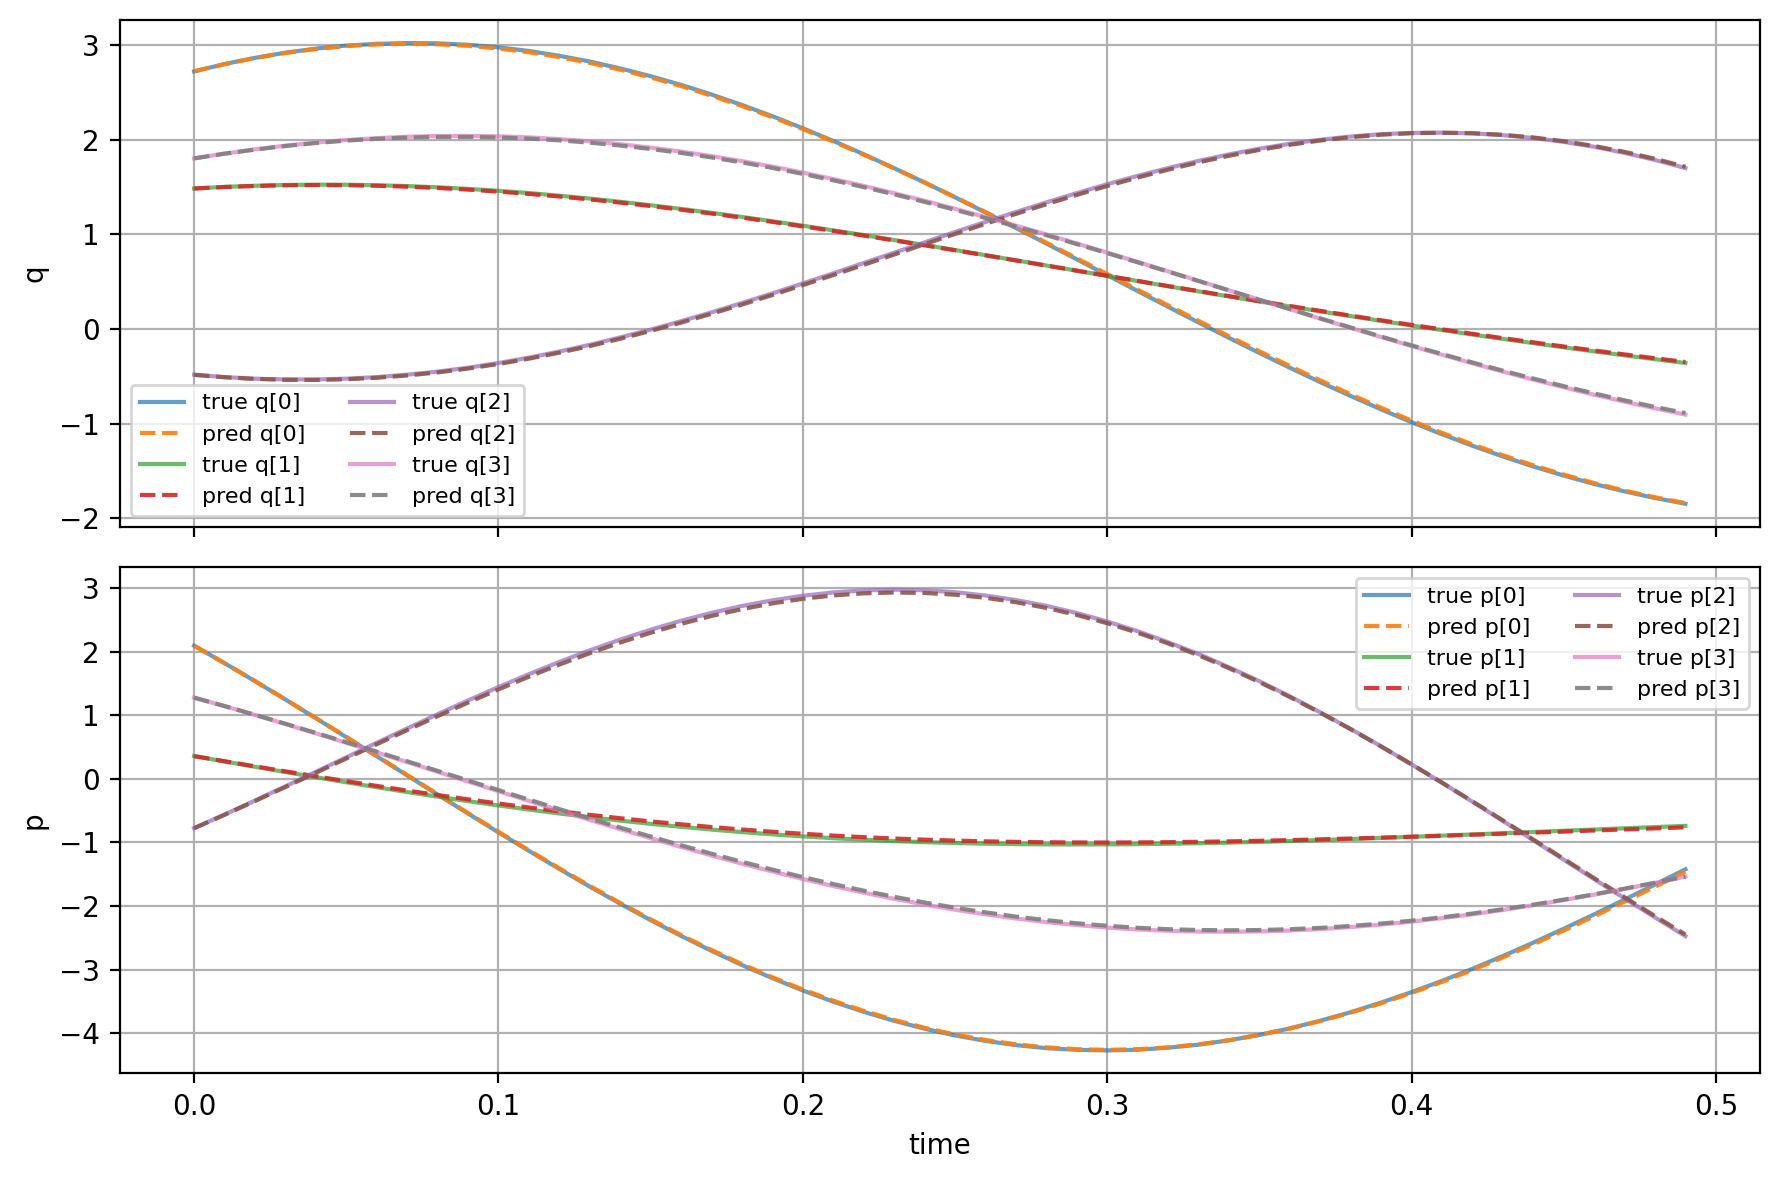

In [36]:

# --- 真値 vs モデル予測（同一初期値）---


#Ts = tuple(np.random.randint(500, 1500, size=(B,)).tolist())


T_total = 50  # 欲しいステップ数に合わせて調整

Ts = tuple(np.arange(0, T_total).tolist())

q0 = test_dataset[0][0:1, :n]  # shape (1, n)
p0 = test_dataset[0][0:1, n:]
#delta_t_infer = test_dataset[3][0:1]
# q0 = q_true[:1]  # shape (1, n)
# p0 = p_true[:1]
# delta_t_infer = jnp.asarray(dt)

# train_idx = 10
# q0 = train_dataset[0][train_idx:train_idx+1, :n]  # shape (1, n)
# p0 = train_dataset[0][train_idx:train_idx+1, n:]
# delta_t_infer = train_dataset[3][train_idx:train_idx+1]
# print(delta_t_infer)

t_vec, q_true, p_true, _ = flow_coupled_1d_harmonic_init_values(
    params=set_harmonic_params(n=n, m=m, k_wall=k_wall, k_pair=k_pair),
    num_steps=Ts,
    dt=dt,
    q0=q0,
    p0=p0,
)


def step_fn(carry, _):
    q_curr, p_curr = carry
    q_next, p_next, _, _ = model.apply(
        {'params': nn_params}, q_curr, p_curr, dt, train=False
    )
    return (q_next, p_next), (q_next, p_next)

if T_total <= 1:
    q_pred = q0
    p_pred = p0
else:
    (_, _), (qs_seq, ps_seq) = jax.lax.scan(
        step_fn, (q0, p0), None, length=T_total - 1
    )
    if qs_seq.ndim == 3:
        qs_seq = jnp.squeeze(qs_seq, axis=1)
        ps_seq = jnp.squeeze(ps_seq, axis=1)
    q_pred = jnp.concatenate([q0, qs_seq], axis=0)
    p_pred = jnp.concatenate([p0, ps_seq], axis=0)

t_arr = np.asarray(t[:T_total])
q_true_np = np.asarray(q_true)[:T_total]
p_true_np = np.asarray(p_true)[:T_total]
q_pred_np = np.asarray(q_pred)
p_pred_np = np.asarray(p_pred)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for i in range(q_pred_np.shape[1]):
    axes[0].plot(t_arr, q_true_np[:, i], label=f'true q[{i}]', alpha=0.7)
    axes[0].plot(t_arr, q_pred_np[:, i], '--', label=f'pred q[{i}]', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].grid(True)
axes[0].legend(ncol=2, fontsize=8)

for i in range(p_pred_np.shape[1]):
    axes[1].plot(t_arr, p_true_np[:, i], label=f'true p[{i}]', alpha=0.7)
    axes[1].plot(t_arr, p_pred_np[:, i], '--', label=f'pred p[{i}]', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].grid(True)
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()



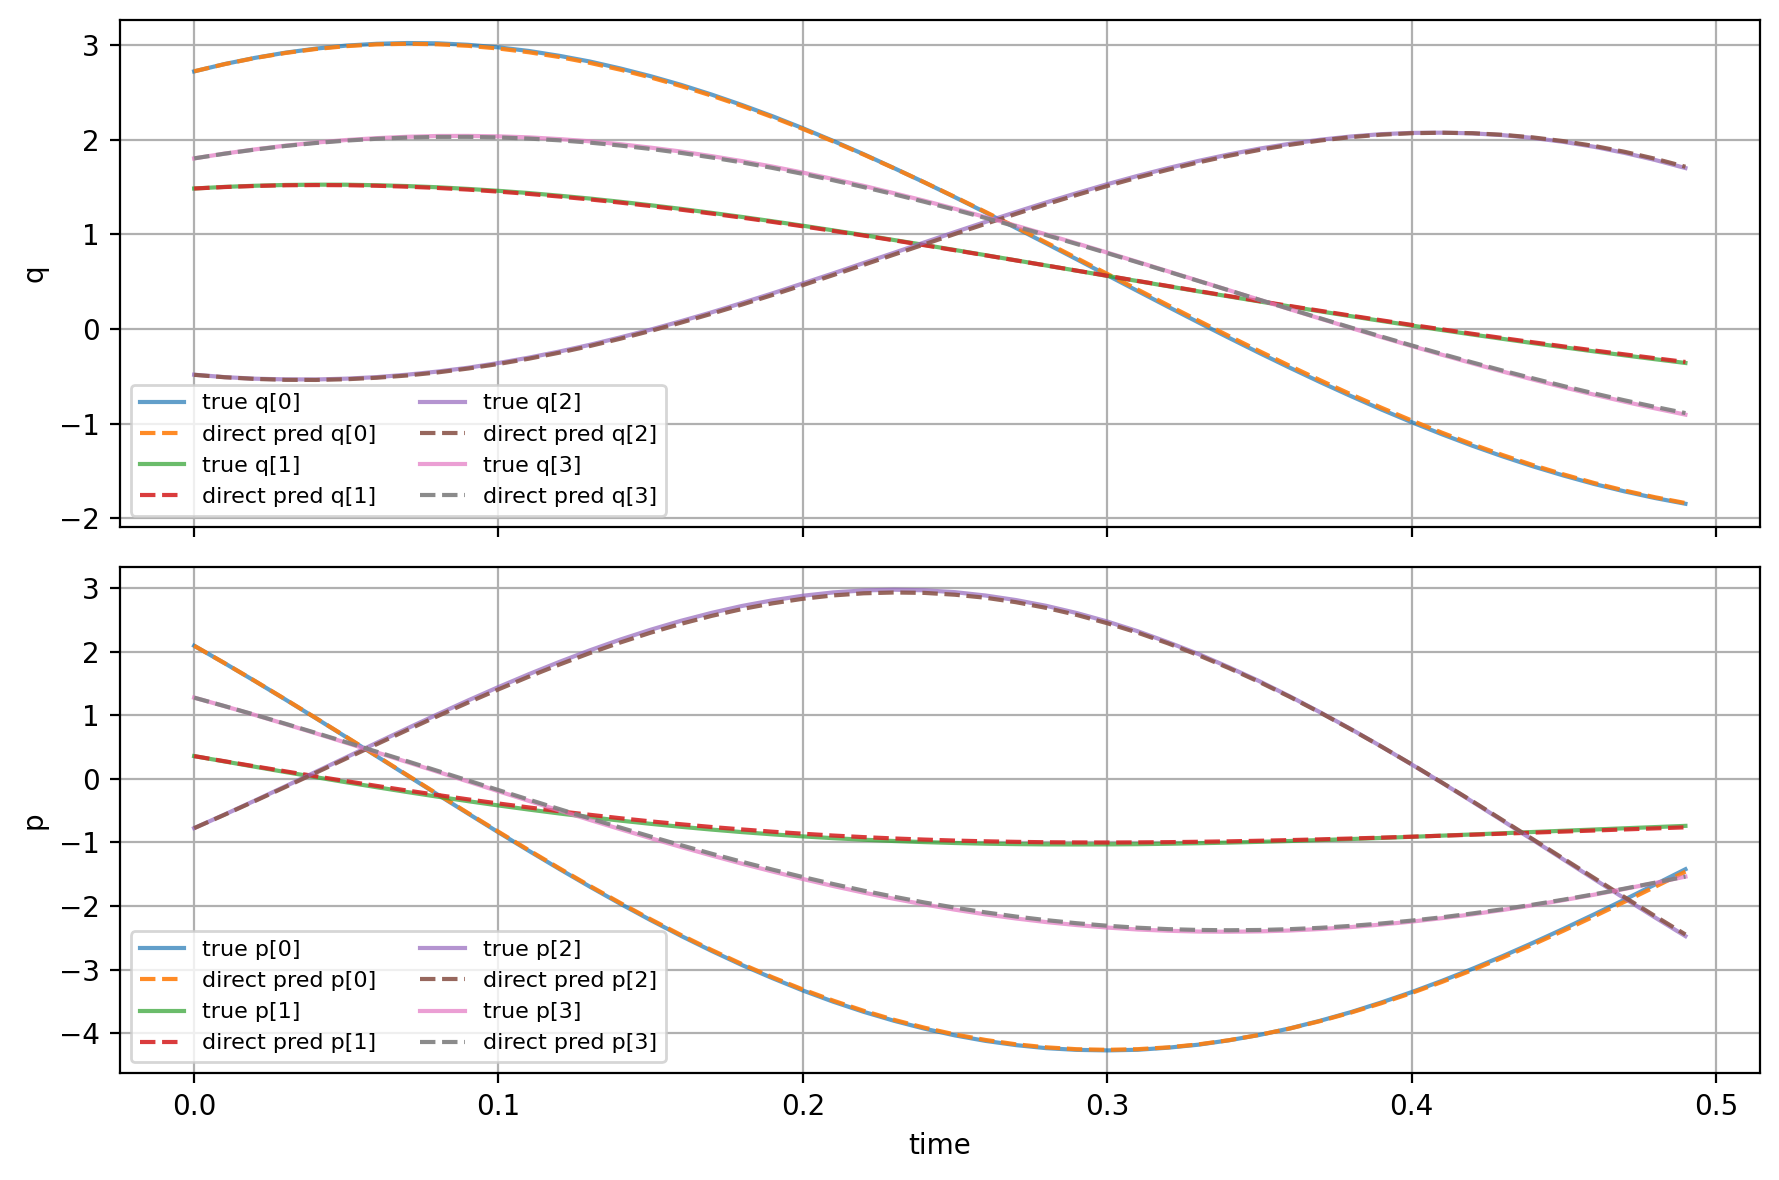

In [37]:
# --- 真値 vs モデル予測（同一初期値；直接推定）---

delta_t_vec = jnp.arange(T_total) * dt

q0_batch = jnp.repeat(q0, repeats=T_total, axis=0)
p0_batch = jnp.repeat(p0, repeats=T_total, axis=0)

q_pred_direct, p_pred_direct, _, _ = model.apply(
    {'params': nn_params}, q0_batch, p0_batch, delta_t_vec, train=False
)

q_pred_direct_np = np.asarray(q_pred_direct)
p_pred_direct_np = np.asarray(p_pred_direct)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for i in range(q_pred_direct_np.shape[1]):
    axes[0].plot(t_arr, q_true_np[:, i], label=f'true q[{i}]', alpha=0.7)
    axes[0].plot(t_arr, q_pred_direct_np[:, i], '--', label=f'direct pred q[{i}]', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].grid(True)
axes[0].legend(ncol=2, fontsize=8)

for i in range(p_pred_direct_np.shape[1]):
    axes[1].plot(t_arr, p_true_np[:, i], label=f'true p[{i}]', alpha=0.7)
    axes[1].plot(t_arr, p_pred_direct_np[:, i], '--', label=f'direct pred p[{i}]', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].grid(True)
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()


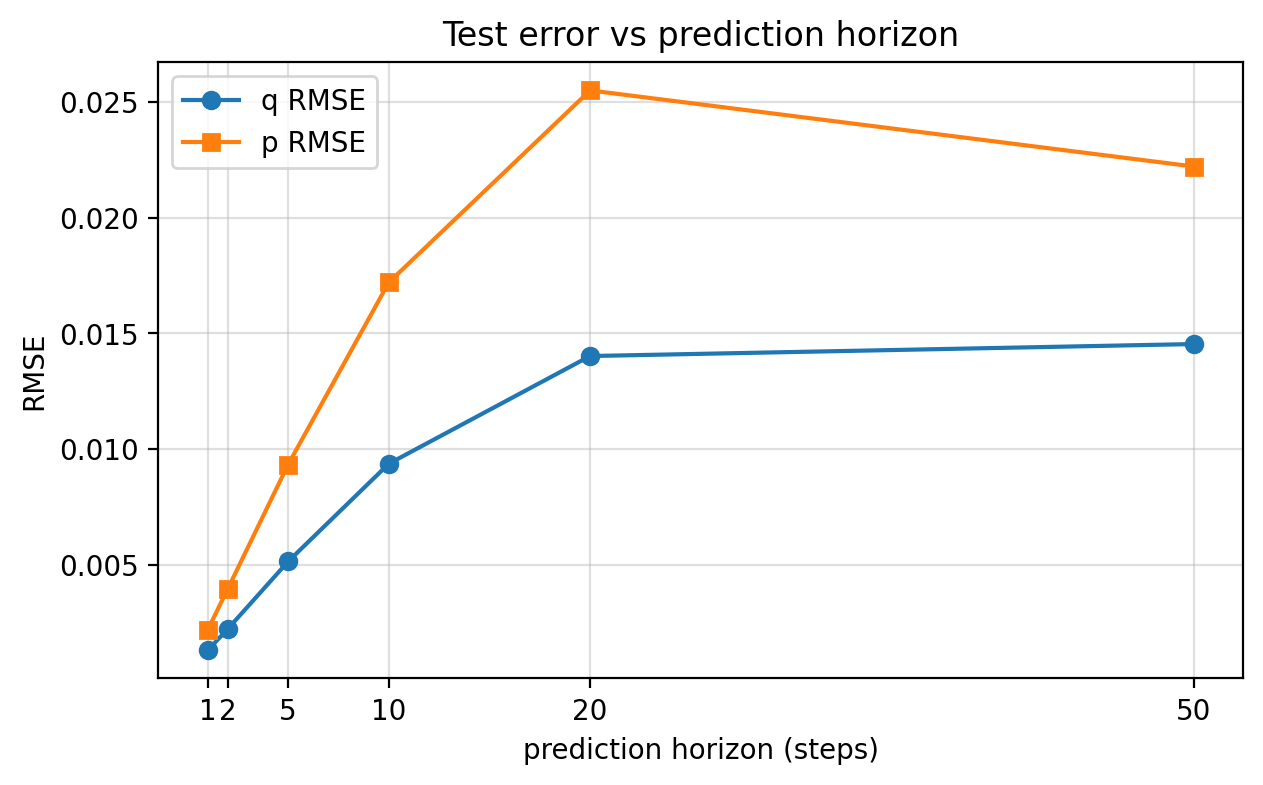

In [38]:
# evaluate test errors on test_dataset for each delta_t

x_test, _, y_test, delta_t_test = test_dataset
n_conf = x_test.shape[1] // 2

q_test = x_test[:, :n_conf]
p_test = x_test[:, n_conf:]
q_target = y_test[:, :n_conf]
p_target = y_test[:, n_conf:]

q_pred_test, p_pred_test, _, _ = model.apply(
    {'params': nn_params}, q_test, p_test, delta_t_test, train=False
)

per_sample_q_rmse = jnp.sqrt(jnp.mean((q_pred_test - q_target) ** 2, axis=1))
per_sample_p_rmse = jnp.sqrt(jnp.mean((p_pred_test - p_target) ** 2, axis=1))

delta_t_np = np.asarray(delta_t_test)
step_counts_per_sample = np.rint(delta_t_np / float(dt)).astype(int)
unique_steps = np.unique(step_counts_per_sample)

per_sample_q_rmse_np = np.asarray(per_sample_q_rmse)
per_sample_p_rmse_np = np.asarray(per_sample_p_rmse)
q_rmse_by_step = []
p_rmse_by_step = []
for step in unique_steps:
    mask = step_counts_per_sample == step
    q_rmse_by_step.append(per_sample_q_rmse_np[mask].mean())
    p_rmse_by_step.append(per_sample_p_rmse_np[mask].mean())

plt.figure(figsize=(7, 4))
plt.plot(unique_steps, q_rmse_by_step, 'o-', label='q RMSE')
plt.plot(unique_steps, p_rmse_by_step, 's-', label='p RMSE')
plt.xticks(unique_steps)
plt.xlabel('prediction horizon (steps)')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.4)
plt.legend()
plt.title('Test error vs prediction horizon')
plt.show()


## Diagnostics

We compare our model to the ground truth Hamiltonian:
\begin{equation}
H(q, p)=\sum_{i=1}^n \frac{p_i^2}{2 m_i}+\frac{k_{\text {wall }}}{2} \sum_{i=1}^n q_i^2+\frac{k_{\text {pair }}}{2} \sum_{1 \leq i < j \leq n} \left( q_i-q_j \right)^2, 
\end{equation}
or
\begin{align}
H =~& \frac{1}{2} p^\top M p + \frac{1}{2} q^\top\left(k_{\mathrm{wall}} I+k_{\mathrm{pair}}\left(n I-\mathbf{1 1}^{\top}\right)\right) q \\
=~&  \frac{1}{2} p^\top M p + \frac{1}{2} q^\top K q
\end{align}
and the ground truth action and anlge:
\begin{equation}
I_j = \frac{1}{2\omega_j} (p)
\end{equation}
(unfinished cell)

In [39]:

# --- Hamiltonian diagnostics utilities ---
import numpy as np

def _make_m_k(sim_params):
    n_loc = int(sim_params.n)
    m_loc = jnp.asarray(sim_params.m, dtype=float)
    k_wall_loc = float(sim_params.k_wall)
    k_pair_loc = float(sim_params.k_pair)
    M = jnp.diag(m_loc)
    J = jnp.ones((n_loc, n_loc))
    K = k_wall_loc * jnp.eye(n_loc) + k_pair_loc * (n_loc * jnp.eye(n_loc) - J)
    return M, K

def H_ground_truth(q_arr, p_arr, sim_params):
    q_arr = jnp.atleast_2d(jnp.asarray(q_arr))
    p_arr = jnp.atleast_2d(jnp.asarray(p_arr))
    M, K = _make_m_k(sim_params)
    Minv = jnp.linalg.inv(M)
    kin = 0.5 * jnp.einsum('ti,ij,tj->t', p_arr, Minv, p_arr)
    pot = 0.5 * jnp.einsum('ti,ij,tj->t', q_arr, K, q_arr)
    return kin + pot

def action_angle_ground_truth(q_arr, p_arr, sim_params):
    q_arr = jnp.atleast_2d(jnp.asarray(q_arr))
    p_arr = jnp.atleast_2d(jnp.asarray(p_arr))
    n_loc = int(sim_params.n)
    m_loc = jnp.asarray(sim_params.m, dtype=float)
    M = jnp.diag(m_loc)
    Minv_sqrt = jnp.diag(1.0 / jnp.sqrt(m_loc))
    Msqrt = jnp.diag(jnp.sqrt(m_loc))
    _, K = _make_m_k(sim_params)
    A = Minv_sqrt @ K @ Minv_sqrt
    w2, U = jnp.linalg.eigh(A)
    omega = jnp.sqrt(jnp.clip(w2, a_min=0.0, a_max=None))
    y = (Msqrt @ q_arr.T).T
    pi = (Minv_sqrt @ p_arr.T).T
    xi = (U.T @ y.T).T
    rho = (U.T @ pi.T).T
    omega_safe = jnp.where(omega > 0, omega, 1.0)
    I = 0.5 * ((rho ** 2) + (omega[None, :] ** 2) * (xi ** 2)) / omega_safe[None, :]
    theta = jnp.arctan2(omega[None, :] * xi, rho)
    return I, theta, omega, U

def predict_hamiltonian(nn_params,q_arr, p_arr):
    q_j = jnp.asarray(q_arr)
    p_j = jnp.asarray(p_arr)
    if q_j.ndim == 1:
        q_j = q_j[None, :]
    if p_j.ndim == 1:
        p_j = p_j[None, :]
    H_pred = model.apply({'params': nn_params}, q_j, p_j,
                         method=MyActionAngleNetwork.hamiltonian)
    return np.asarray(H_pred)

def predict_action_angle(nn_params, q_arr, p_arr):
    q_j = jnp.asarray(q_arr)
    p_j = jnp.asarray(p_arr)
    if q_j.ndim == 1:
        q_j = q_j[None, :]
    if p_j.ndim == 1:
        p_j = p_j[None, :]
    _, _, I_pred, theta_pred = model.apply({'params': nn_params}, q_j, p_j,
                                           jnp.asarray(0.0), train=False)
    return np.asarray(I_pred), np.asarray(theta_pred)



In [ ]:

# --- Hamiltonian / action diagnostics ---
sim_params = hyper_params

q_plot = jnp.asarray(q_true_np)
p_plot = jnp.asarray(p_true_np)

H_true_vals = H_ground_truth(q_plot, p_plot, sim_params)
I_true_vals, theta_true_vals, omega_vals, U_vals = action_angle_ground_truth(q_plot, p_plot, sim_params)

H_pred_vals = predict_hamiltonian(nn_params, q_pred_direct_np, p_pred_direct_np)
I_pred_vals, theta_pred_vals = predict_action_angle(nn_params, q_pred_direct_np, p_pred_direct_np)

# H_pred_vals = predict_hamiltonian(nn_params, q_true_np, p_true_np)
# I_pred_vals, theta_pred_vals = predict_action_angle(nn_params, q_true_np, p_true_np)

plt.figure()
plt.plot(H_true_vals-jnp.mean(H_true_vals), label='H (ground truth)')
plt.plot(H_pred_vals-jnp.mean(H_pred_vals), '--', label='H (predicted)')
plt.xlabel('time index')
plt.ylabel('Hamiltonian')
plt.title('Hamiltonian along trajectory')
plt.legend()
plt.show()

max_modes = min(4, I_true_vals.shape[1])
for j_mode in range(max_modes):
    plt.figure()
    plt.plot(I_true_vals[:, j_mode], label=f'I{j_mode} (gt)')
    plt.plot(I_pred_vals[:, j_mode], '--', label=f'I{j_mode} (pred)')
    plt.xlabel('time index')
    plt.ylabel(f'I_{j_mode}')
    plt.title(f'Action I_{j_mode} along trajectory')
    plt.legend()
    plt.show()

# def _wrap_pi(arr):
#     return (arr + np.pi) % (2 * np.pi) - np.pi

# for j_mode in range(max_modes):
#     plt.figure()
#     plt.plot(_wrap_pi(theta_true_vals[:, j_mode]), label=f'theta{j_mode} (gt)')
#     plt.plot(_wrap_pi(theta_pred_vals[:, j_mode]), '--', label=f'theta{j_mode} (pred)')
#     plt.xlabel('time index')
#     plt.ylabel(f'theta_{j_mode}')
#     plt.title(f'Angle theta_{j_mode} along trajectory')
#     plt.legend()
#     plt.show()



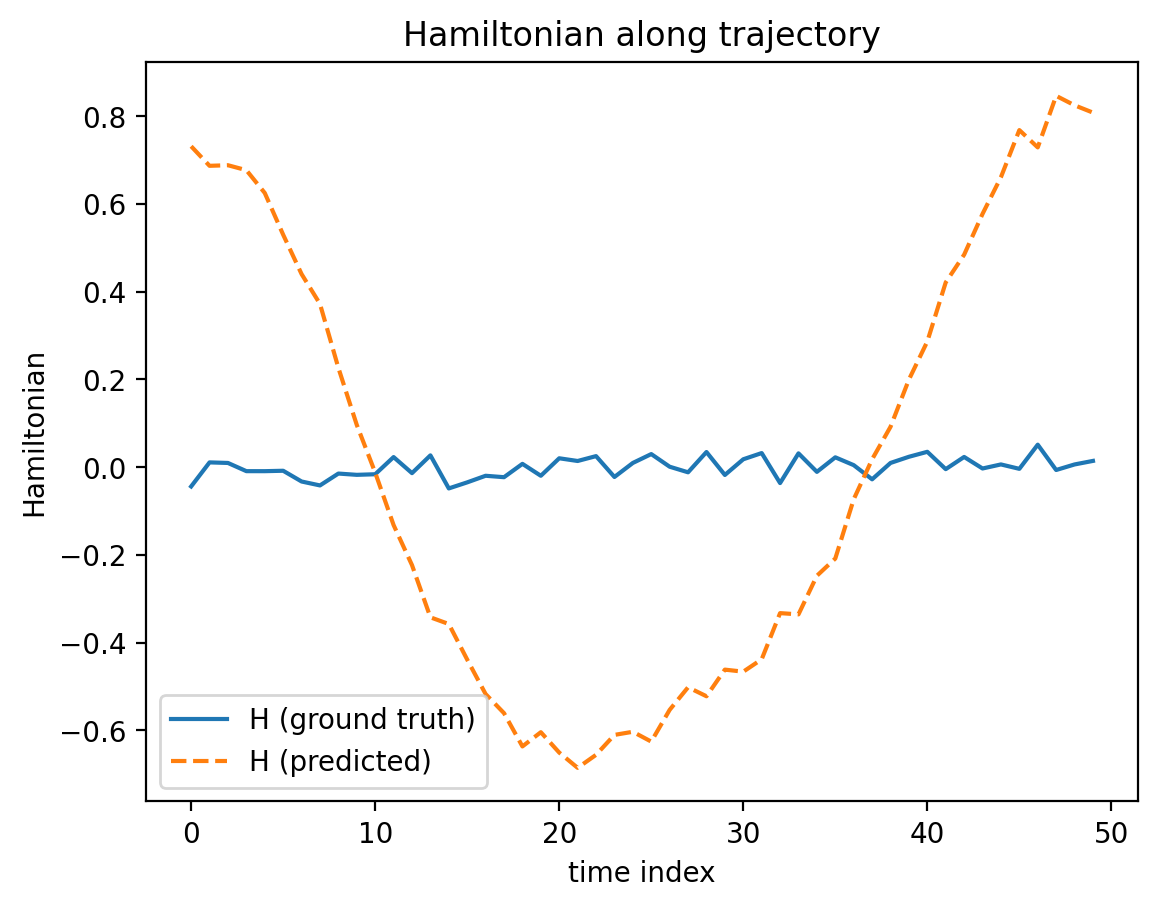

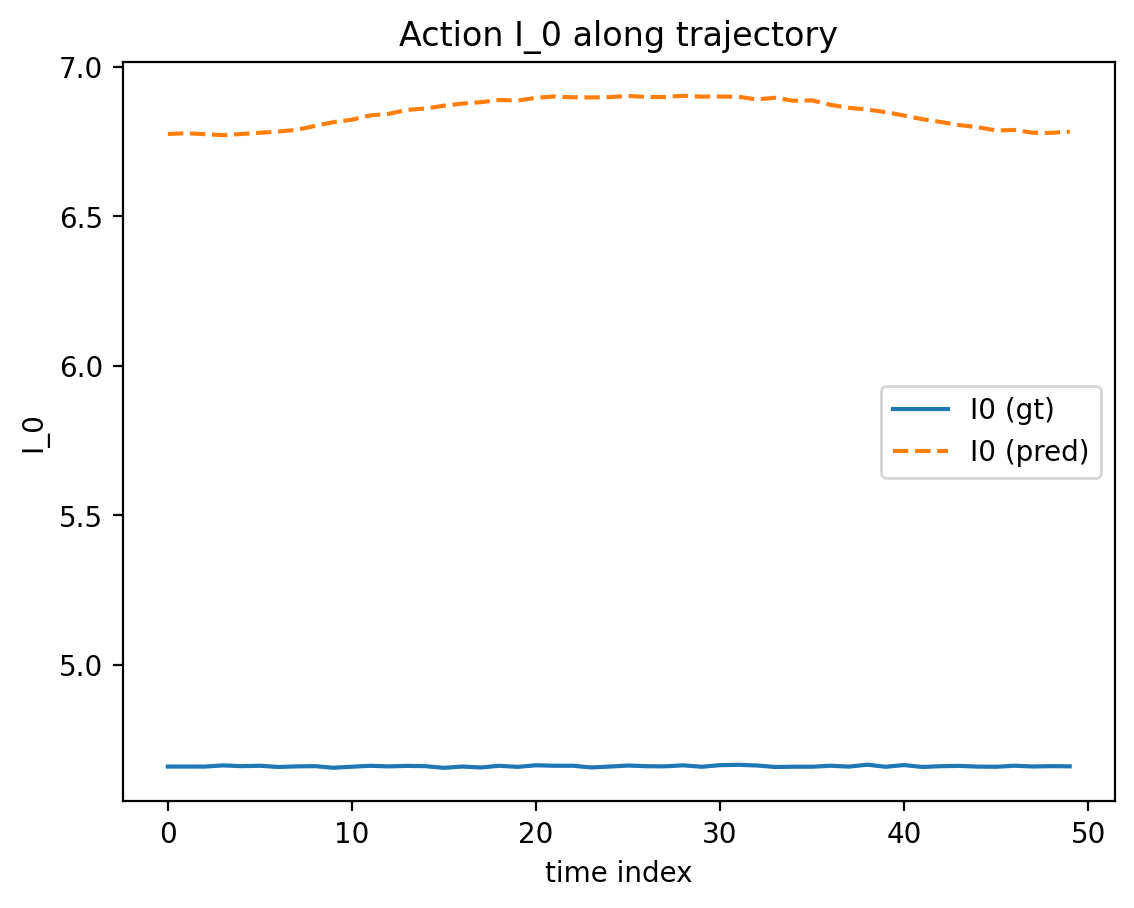

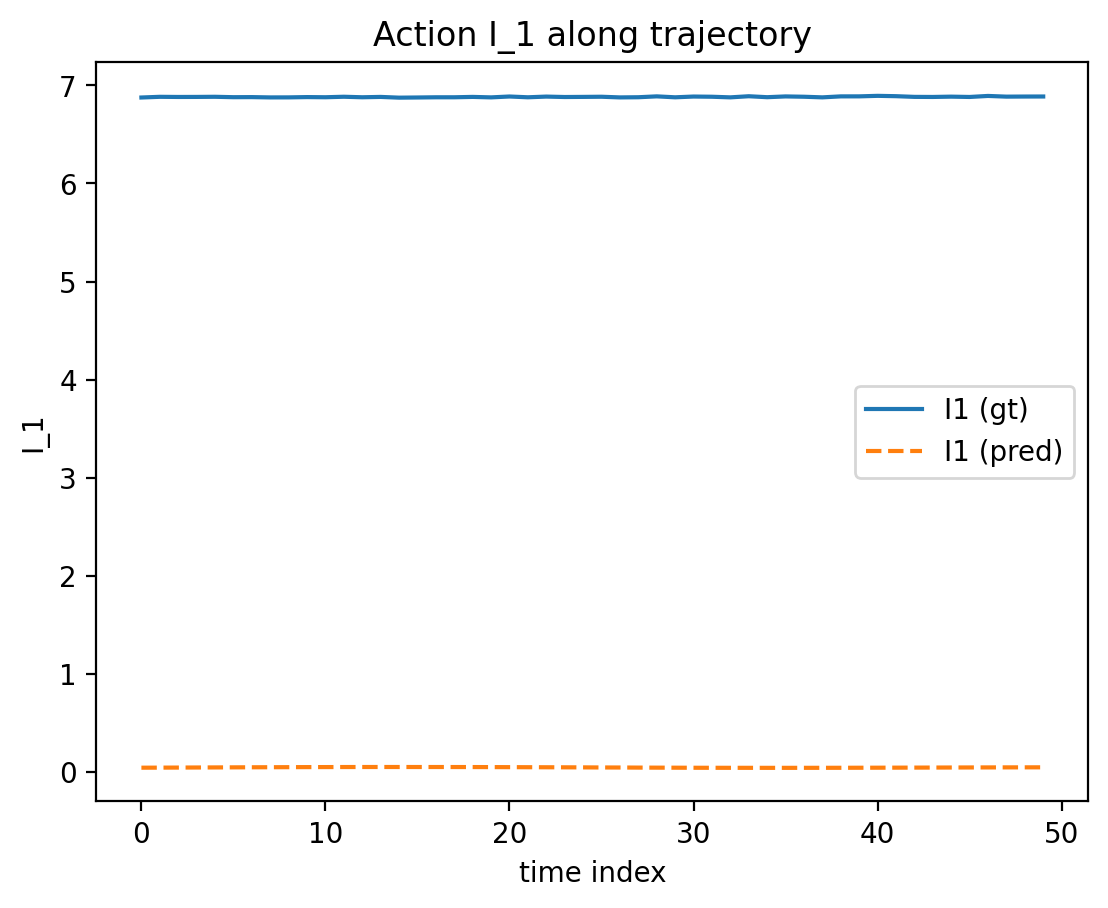

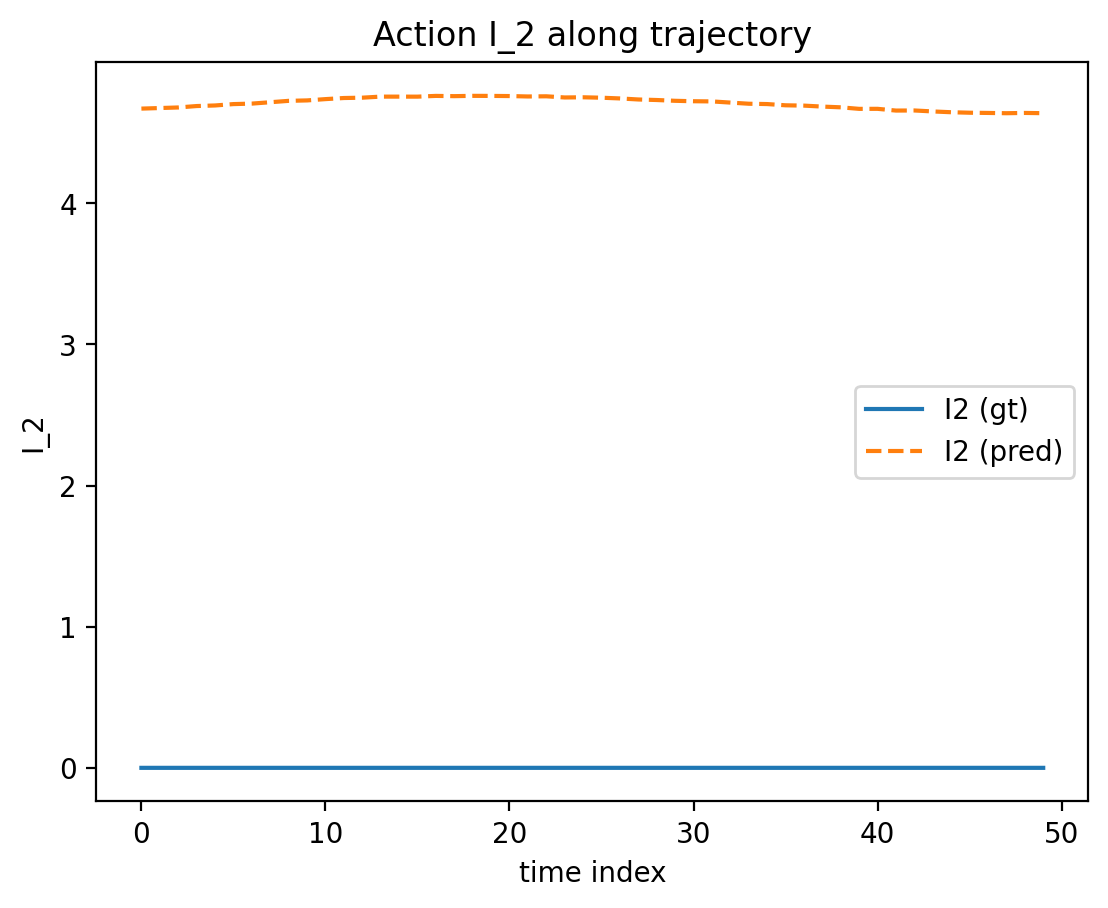

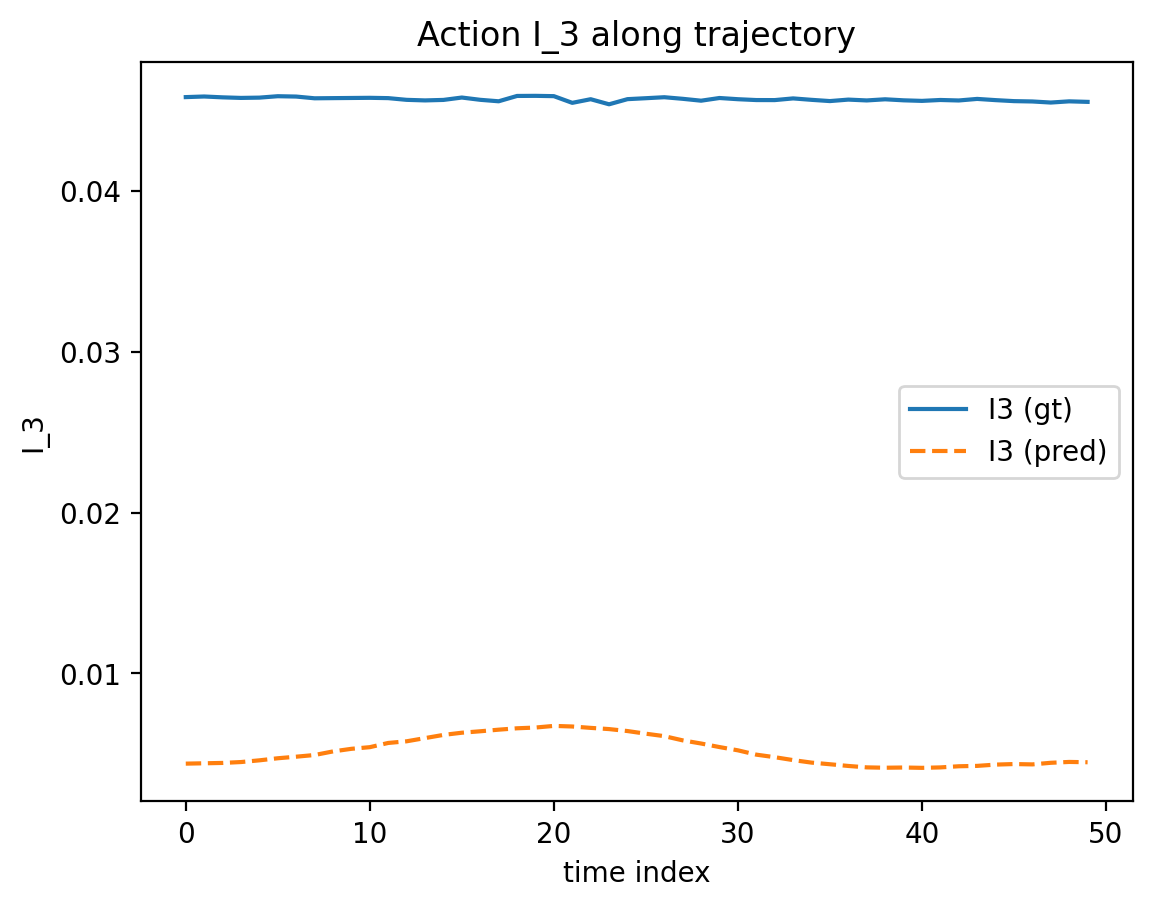

In [40]:

# --- Hamiltonian / action diagnostics ---
sim_params = hyper_params

q_plot = jnp.asarray(q_true_np)
p_plot = jnp.asarray(p_true_np)

H_true_vals = H_ground_truth(q_plot, p_plot, sim_params)
I_true_vals, theta_true_vals, omega_vals, U_vals = action_angle_ground_truth(q_plot, p_plot, sim_params)

# H_pred_vals = predict_hamiltonian(nn_params, q_pred_direct_np, p_pred_direct_np)
# I_pred_vals, theta_pred_vals = predict_action_angle(nn_params, q_pred_direct_np, p_pred_direct_np)

H_pred_vals = predict_hamiltonian(nn_params, q_true_np, p_true_np)
I_pred_vals, theta_pred_vals = predict_action_angle(nn_params, q_true_np, p_true_np)

plt.figure()
plt.plot(H_true_vals-jnp.mean(H_true_vals), label='H (ground truth)')
plt.plot(H_pred_vals-jnp.mean(H_pred_vals), '--', label='H (predicted)')
plt.xlabel('time index')
plt.ylabel('Hamiltonian')
plt.title('Hamiltonian along trajectory')
plt.legend()
plt.show()

max_modes = min(4, I_true_vals.shape[1])
for j_mode in range(max_modes):
    plt.figure()
    plt.plot(I_true_vals[:, j_mode], label=f'I{j_mode} (gt)')
    plt.plot(I_pred_vals[:, j_mode], '--', label=f'I{j_mode} (pred)')
    plt.xlabel('time index')
    plt.ylabel(f'I_{j_mode}')
    plt.title(f'Action I_{j_mode} along trajectory')
    plt.legend()
    plt.show()

# def _wrap_pi(arr):
#     return (arr + np.pi) % (2 * np.pi) - np.pi

# for j_mode in range(max_modes):
#     plt.figure()
#     plt.plot(_wrap_pi(theta_true_vals[:, j_mode]), label=f'theta{j_mode} (gt)')
#     plt.plot(_wrap_pi(theta_pred_vals[:, j_mode]), '--', label=f'theta{j_mode} (pred)')
#     plt.xlabel('time index')
#     plt.ylabel(f'theta_{j_mode}')
#     plt.title(f'Angle theta_{j_mode} along trajectory')
#     plt.legend()
#     plt.show()



In [41]:
t_vec, q_test_traj, p_test_traj, _ = vmap( lambda x: flow_coupled_1d_harmonic_init_values(
    params=set_harmonic_params(n=n, m=m, k_wall=k_wall, k_pair=k_pair),
    num_steps=Ts,
    dt=dt,
    q0=x[:n],
    p0=x[n:]
    ), in_axes=0 )( jnp.concatenate([q0_test, p0_test], axis=1) )

/tmp/1118436.4946/ipykernel_705193/4020243990.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


In [42]:

q_test_pred, p_test_pred, _, _ = model.apply(
    {'params': nn_params}, q0_test, p0_test, jnp.array(dt * jnp.arange(len(Ts)))[...,None], train=False
)

q_test_pred = jnp.asarray(q_test_pred)
p_test_pred = jnp.asarray(p_test_pred)

H_pred_vals = predict_hamiltonian(nn_params, q_test_pred, p_test_pred)
H_pred_vals = H_pred_vals - np.mean(H_pred_vals, axis=0)

2025-11-25 15:56:59.046155: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-11-25 15:56:59.983952: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-11-25 15:57:01.947757: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


 ...]

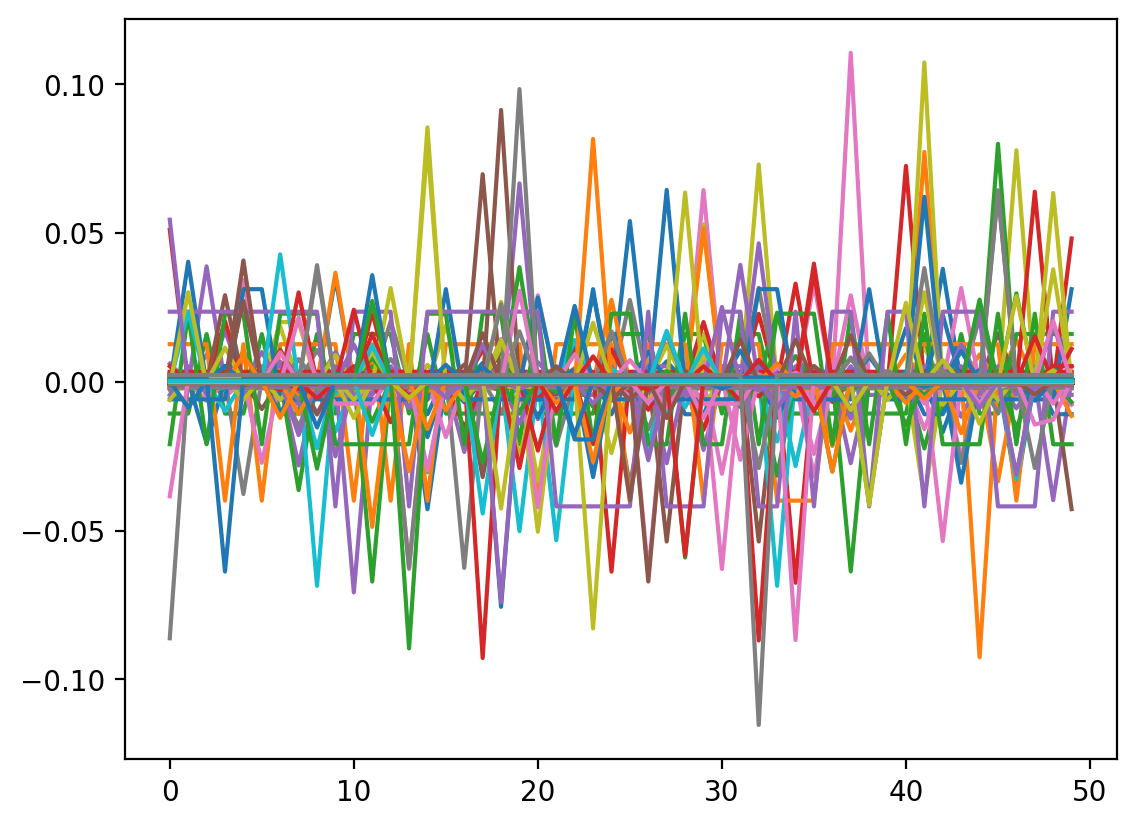

In [43]:
plt.plot(H_pred_vals)

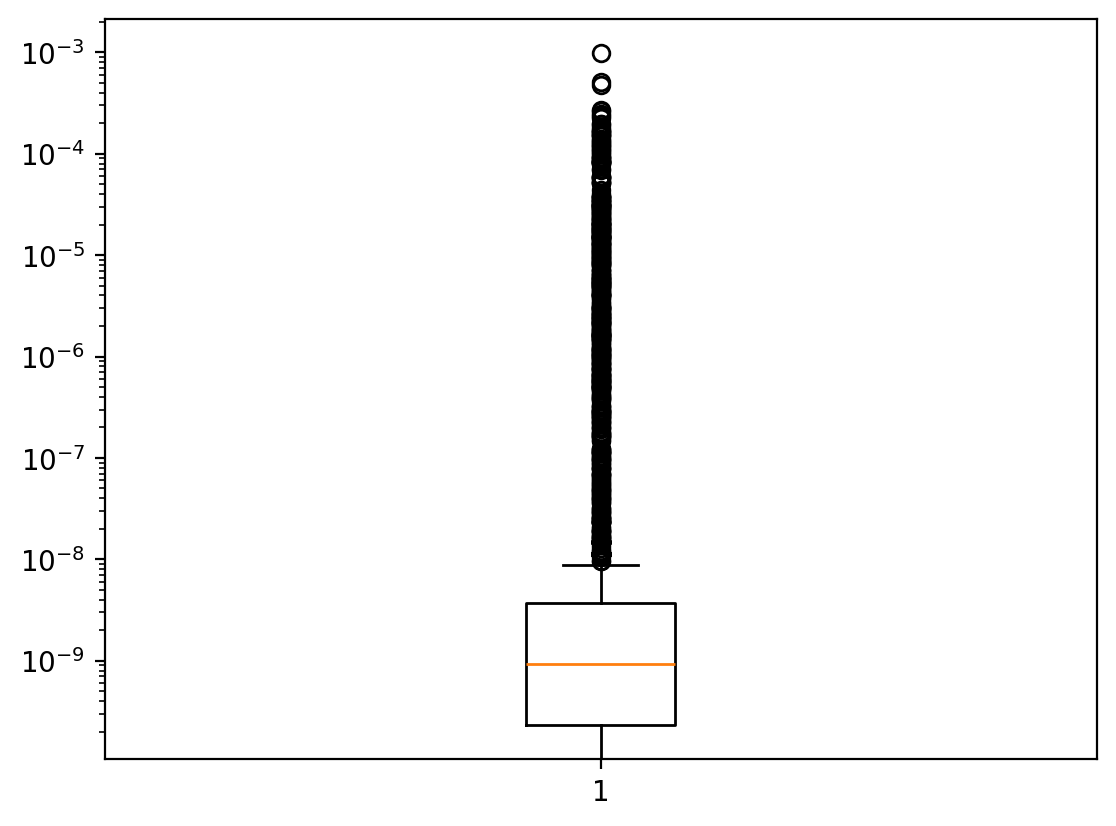

In [44]:
plt.boxplot( (H_pred_vals**2).mean(axis=0) )
plt.yscale('log')

# Change loss weights

In [45]:
rng = jax.random.PRNGKey(0)
q0 = jnp.zeros((1, int(n)))
p0 = jnp.zeros((1, int(n)))
delta_t0 = jnp.asarray(0.1)

variables = model.init(rng, q0, p0, delta_t0)
params_old = variables['params']
num_params = sum(jax.tree_util.tree_leaves(jax.tree_util.tree_map(lambda x: x.size, params_old)))
print(f'Total parameters: {num_params}')


Total parameters: 65089


In [46]:
w_hnn = 0.001
epochs = 400

In [47]:

loss_weights = (1.0, 1.0, 0.0, w_hnn)
#delta_t = dt  # base time step
#delta_t_max = 0.5 # max jump multiplier during training


key = jax.random.PRNGKey(seed)
variables = model.init(key, jnp.zeros((1, n)), jnp.zeros((1, n)), jnp.asarray(dt))
nn_params_dif_loss = variables['params']

tx = optax.chain(
    optax.clip_by_global_norm(max_norm=1.0),  # Clip gradients by their global norm
    optax.adam(learning_rate=lr)            # Use Adam optimizer
)
#tx = optax.adam(learning_rate=lr)
opt_state = tx.init(nn_params_dif_loss)

idx_serial_batch = 0
batch_losses = []
grad_norms = []
omega_norms = []

for ep in range(epochs):
    
    if ep == 0:
        x0_train, x0_dot_train, xt_train, t_train = train_dataset
    else:
        # Shuffle training data
        # なんとなくtを最初の方は短く→あとで長くとトレーニングしたいので、何チャンクかにわけてそのチャンク内でシャッフル
        # epochs=1なら関係ない
        for idx_ep in range(ep_shuffle_chunks):
            perm_key, key = jax.random.split(key)
            perm = jax.random.permutation(perm_key, N_train // ep_shuffle_chunks)
            start_idx = idx_ep * (N_train // ep_shuffle_chunks)
            end_idx = (idx_ep + 1) * (N_train // ep_shuffle_chunks)
            x0_train, x0_dot_train, xt_train, t_train = train_dataset
            x0_train = x0_train.at[start_idx:end_idx].set(x0_train[start_idx:end_idx][perm])
            x0_dot_train = x0_dot_train.at[start_idx:end_idx].set(x0_dot_train[start_idx:end_idx][perm])
            xt_train = xt_train.at[start_idx:end_idx].set(xt_train[start_idx:end_idx][perm])
            t_train = t_train.at[start_idx:end_idx].set(t_train[start_idx:end_idx][perm])
    
    # Mini-batch training
    num_batches = N_train // batch_size
    epoch_loss = 0.0

    for i in range(num_batches):
        batch_x0     = x0_train[i*batch_size:(i+1)*batch_size]
        batch_x0_dot = x0_dot_train[i*batch_size:(i+1)*batch_size]
        batch_xt     = xt_train[i*batch_size:(i+1)*batch_size]
        batch_t      = t_train[i*batch_size:(i+1)*batch_size]

        nn_params_dif_loss, opt_state, batch_loss, grad_norm, omega_norm = train_step_jit(
            nn_params_dif_loss, opt_state,
            (batch_x0, batch_x0_dot, batch_xt, batch_t),
            apply_fn=model.apply, tx=tx,
            loss_weights=loss_weights
        )
        total_batch_loss = batch_loss * len(batch_t)
        epoch_loss += total_batch_loss
        #epoch_loss += batch_loss *         
        batch_losses.append(batch_loss)
        grad_norms.append(grad_norm)
        omega_norms.append(omega_norm)

        if (idx_serial_batch + 1) % log_every == 0:
            print(f"Epoch {ep+1}, Batch {i+1}/{num_batches}, Loss: {batch_loss:.6f}")

        if (idx_serial_batch + 1) % log_every == 0 or idx_serial_batch == 1 or (ep==epochs-1 and i==num_batches-1):
            test_losses = []
            num_test_batches = N_test // batch_size
            for j in range(num_test_batches):
                batch_x0_test = test_dataset[0][j*batch_size:(j+1)*batch_size]
                batch_x0_dot_test = test_dataset[1][j*batch_size:(j+1)*batch_size]
                batch_xt_test = test_dataset[2][j*batch_size:(j+1)*batch_size]
                batch_t_test = test_dataset[3][j*batch_size:(j+1)*batch_size]

                test_loss = eval_batch(
                    nn_params,
                    batch_x0_test,
                    batch_xt_test,
                    batch_t_test,
                    apply_fn=model.apply
                )
                test_losses.append(test_loss * len(batch_t_test))
            total_test_loss = sum(test_losses) / N_test
            print(f"*** Test Loss after {idx_serial_batch} batches: {total_test_loss:.6f} ***")
        
        idx_serial_batch += 1

    epoch_loss /= N_train
    print(f"Epoch {ep+1} completed. Average Loss: {epoch_loss:.6f}")

    


*** Test Loss after 1 batches: 0.306107 ***
Epoch 1 completed. Average Loss: 75849252864.000000
Epoch 2 completed. Average Loss: 76963472.000000
Epoch 3, Batch 12/19, Loss: 9715729.000000
*** Test Loss after 49 batches: 0.306107 ***
Epoch 3 completed. Average Loss: 20534852.000000
Epoch 4 completed. Average Loss: 5829453.000000
Epoch 5 completed. Average Loss: 1241392.625000
Epoch 6, Batch 5/19, Loss: 852222.375000
*** Test Loss after 99 batches: 0.306107 ***
Epoch 6 completed. Average Loss: 571346.437500
Epoch 7 completed. Average Loss: 888817.937500
Epoch 8, Batch 17/19, Loss: 104518.007812
*** Test Loss after 149 batches: 0.306107 ***
Epoch 8 completed. Average Loss: 207645.828125
Epoch 9 completed. Average Loss: 38690.035156
Epoch 10 completed. Average Loss: 9924.368164
Epoch 11, Batch 10/19, Loss: 6049.328613
*** Test Loss after 199 batches: 0.306107 ***
Epoch 11 completed. Average Loss: 8325.562500
Epoch 12 completed. Average Loss: 5061.996094
Epoch 13 completed. Average Loss: 40

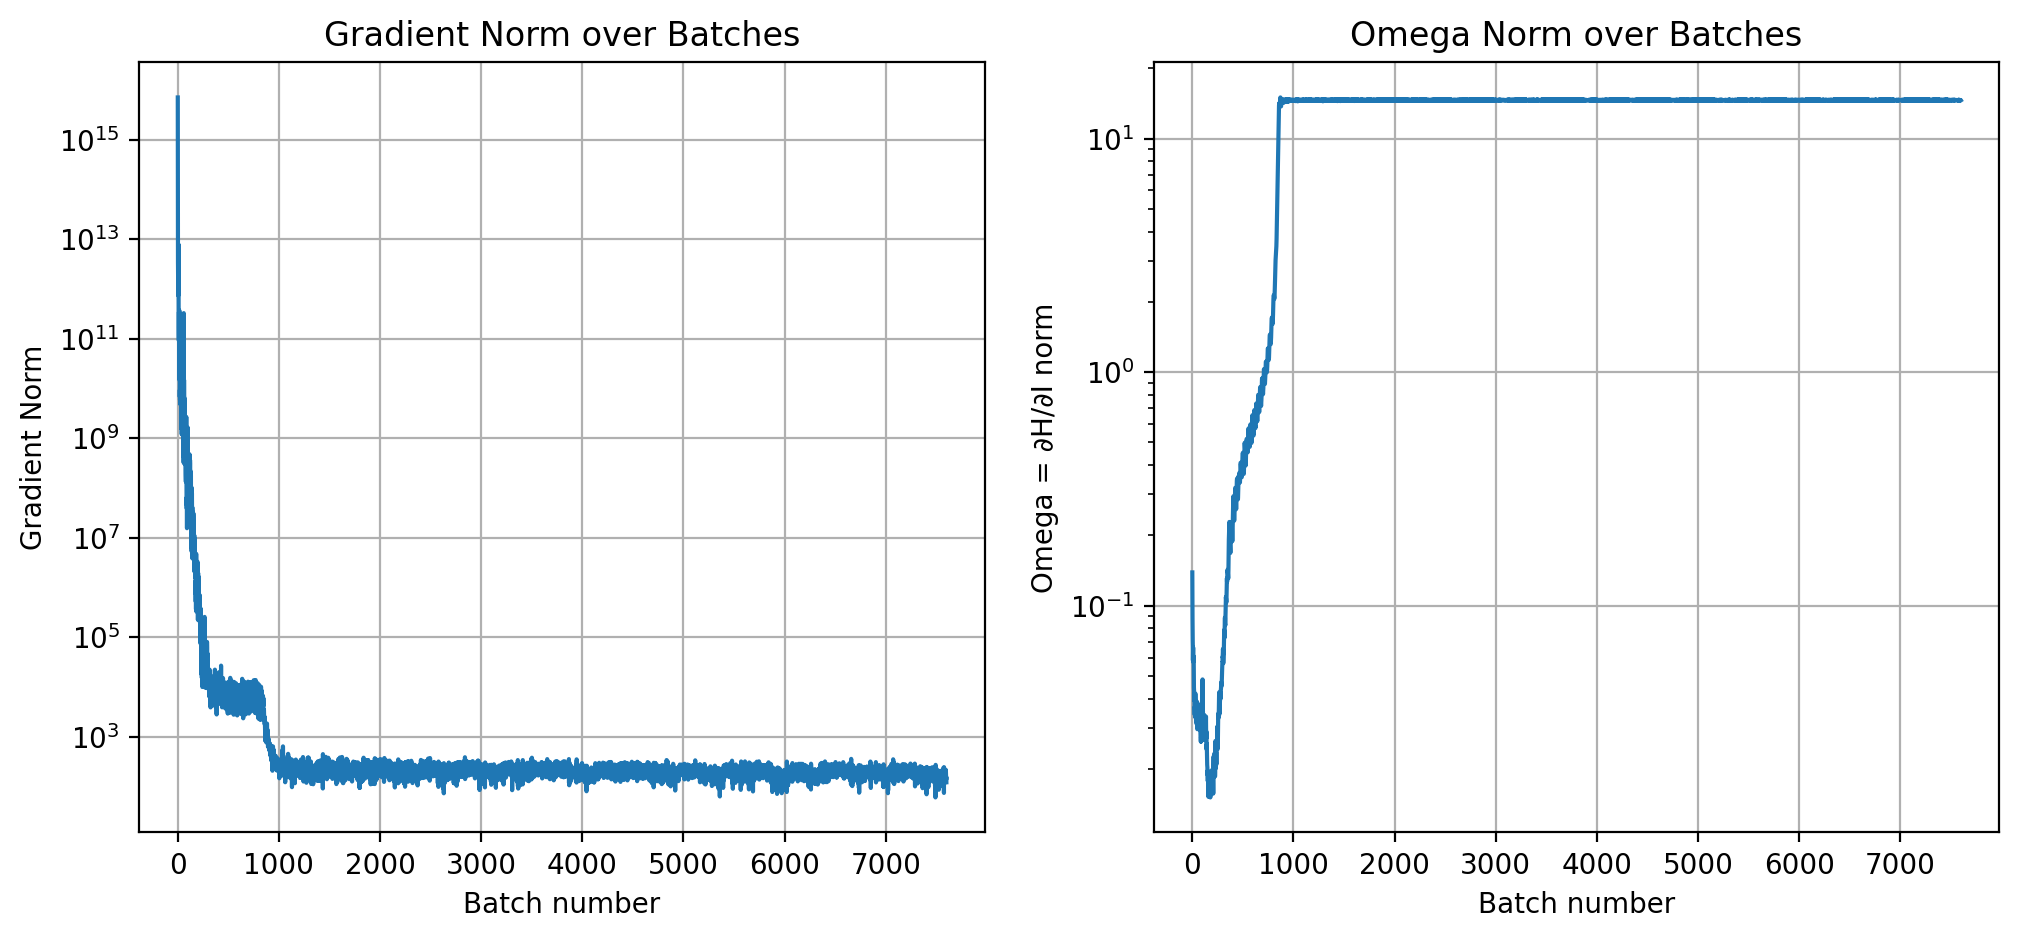

In [48]:
fig, axes = plt.subplots(1,2,figsize=(12, 5))
axes[0].plot(grad_norms)
axes[0].set_yscale('log')
axes[0].set_xlabel('Batch number')
axes[0].set_ylabel('Gradient Norm')
axes[0].set_title('Gradient Norm over Batches')
axes[0].grid()

axes[1].plot(omega_norms)
axes[1].set_yscale('log')
axes[1].set_xlabel('Batch number')
axes[1].set_ylabel('Omega = ∂H/∂I norm')
axes[1].set_title('Omega Norm over Batches')
axes[1].grid()

plt.show()

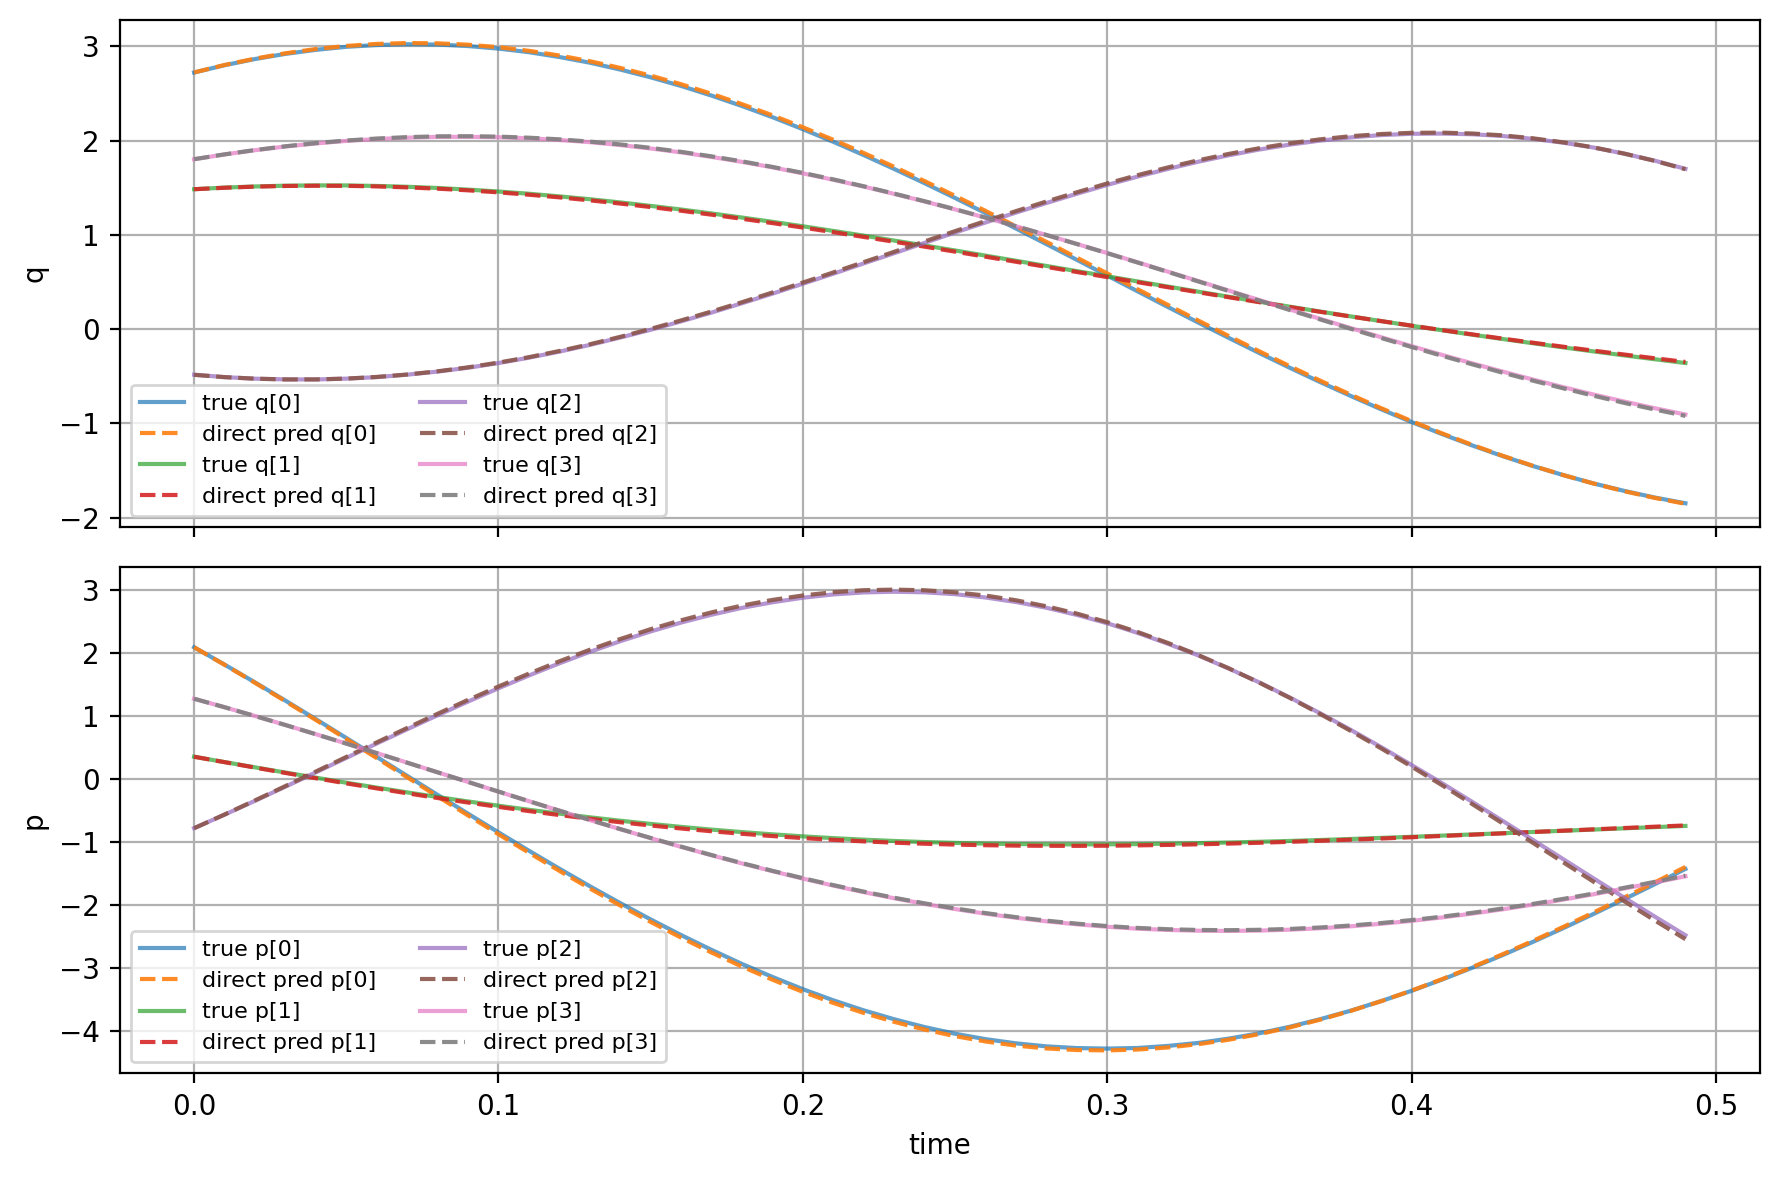

In [49]:
# --- 真値 vs モデル予測（同一初期値；直接推定）---
T_total = 50  # 欲しいステップ数に合わせて調整

Ts = tuple(np.arange(0, T_total).tolist())

q0 = test_dataset[0][0:1, :n]  # shape (1, n)
p0 = test_dataset[0][0:1, n:]

delta_t_vec = jnp.arange(T_total) * dt

q0_batch = jnp.repeat(q0, repeats=T_total, axis=0)
p0_batch = jnp.repeat(p0, repeats=T_total, axis=0)

q_pred_direct_dif_loss, p_pred_direct_dif_loss, _, _ = model.apply(
    {'params': nn_params_dif_loss}, q0_batch, p0_batch, delta_t_vec, train=False
)

q_pred_direct_dif_loss_np = np.asarray(q_pred_direct_dif_loss)
p_pred_direct_dif_loss_np = np.asarray(p_pred_direct_dif_loss)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for i in range(q_pred_direct_dif_loss_np.shape[1]):
    axes[0].plot(t_arr, q_true_np[:, i], label=f'true q[{i}]', alpha=0.7)
    axes[0].plot(t_arr, q_pred_direct_dif_loss_np[:, i], '--', label=f'direct pred q[{i}]', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].grid(True)
axes[0].legend(ncol=2, fontsize=8)

for i in range(p_pred_direct_dif_loss_np.shape[1]):
    axes[1].plot(t_arr, p_true_np[:, i], label=f'true p[{i}]', alpha=0.7)
    axes[1].plot(t_arr, p_pred_direct_dif_loss_np[:, i], '--', label=f'direct pred p[{i}]', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].grid(True)
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()


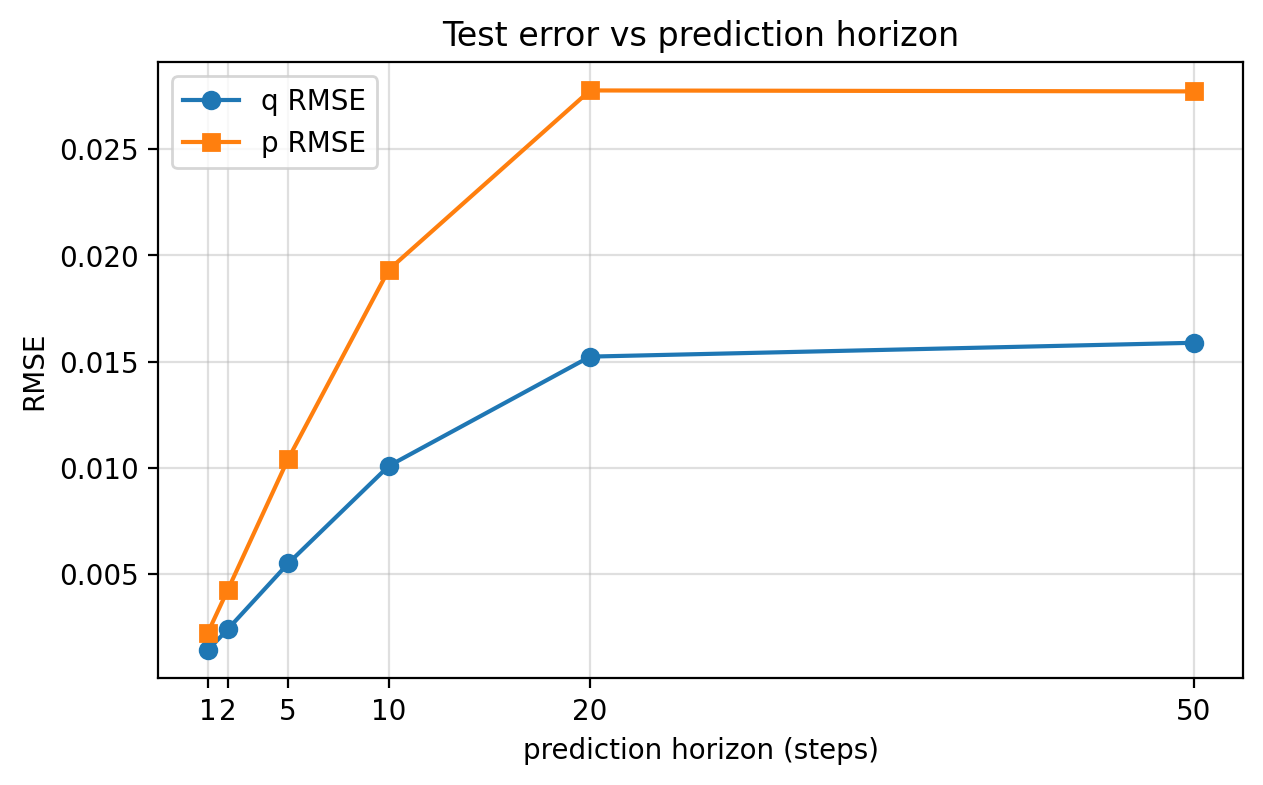

In [50]:
# evaluate test errors on test_dataset for each delta_t

x_test, _, y_test, delta_t_test = test_dataset
n_conf = x_test.shape[1] // 2

q_test = x_test[:, :n_conf]
p_test = x_test[:, n_conf:]
q_target = y_test[:, :n_conf]
p_target = y_test[:, n_conf:]

q_pred_test_dif_loss, p_pred_test_dif_loss, _, _ = model.apply(
    {'params': nn_params_dif_loss}, q_test, p_test, delta_t_test, train=False
)

per_sample_q_rmse = jnp.sqrt(jnp.mean((q_pred_test_dif_loss - q_target) ** 2, axis=1))
per_sample_p_rmse = jnp.sqrt(jnp.mean((p_pred_test_dif_loss - p_target) ** 2, axis=1))

delta_t_np = np.asarray(delta_t_test)
step_counts_per_sample = np.rint(delta_t_np / float(dt)).astype(int)
unique_steps = np.unique(step_counts_per_sample)

per_sample_q_rmse_np = np.asarray(per_sample_q_rmse)
per_sample_p_rmse_np = np.asarray(per_sample_p_rmse)
q_rmse_by_step = []
p_rmse_by_step = []
for step in unique_steps:
    mask = step_counts_per_sample == step
    q_rmse_by_step.append(per_sample_q_rmse_np[mask].mean())
    p_rmse_by_step.append(per_sample_p_rmse_np[mask].mean())

plt.figure(figsize=(7, 4))
plt.plot(unique_steps, q_rmse_by_step, 'o-', label='q RMSE')
plt.plot(unique_steps, p_rmse_by_step, 's-', label='p RMSE')
plt.xticks(unique_steps)
plt.xlabel('prediction horizon (steps)')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.4)
plt.legend()
plt.title('Test error vs prediction horizon')
plt.show()


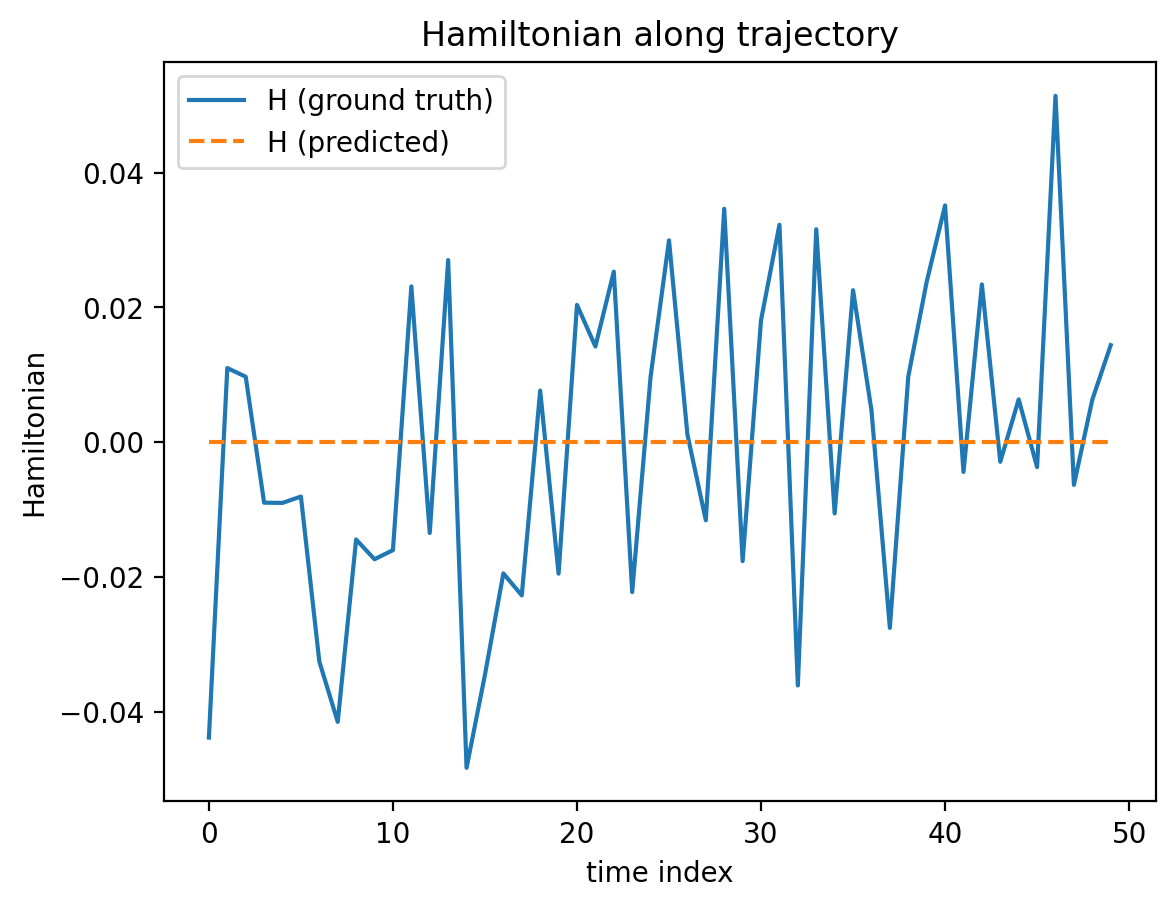

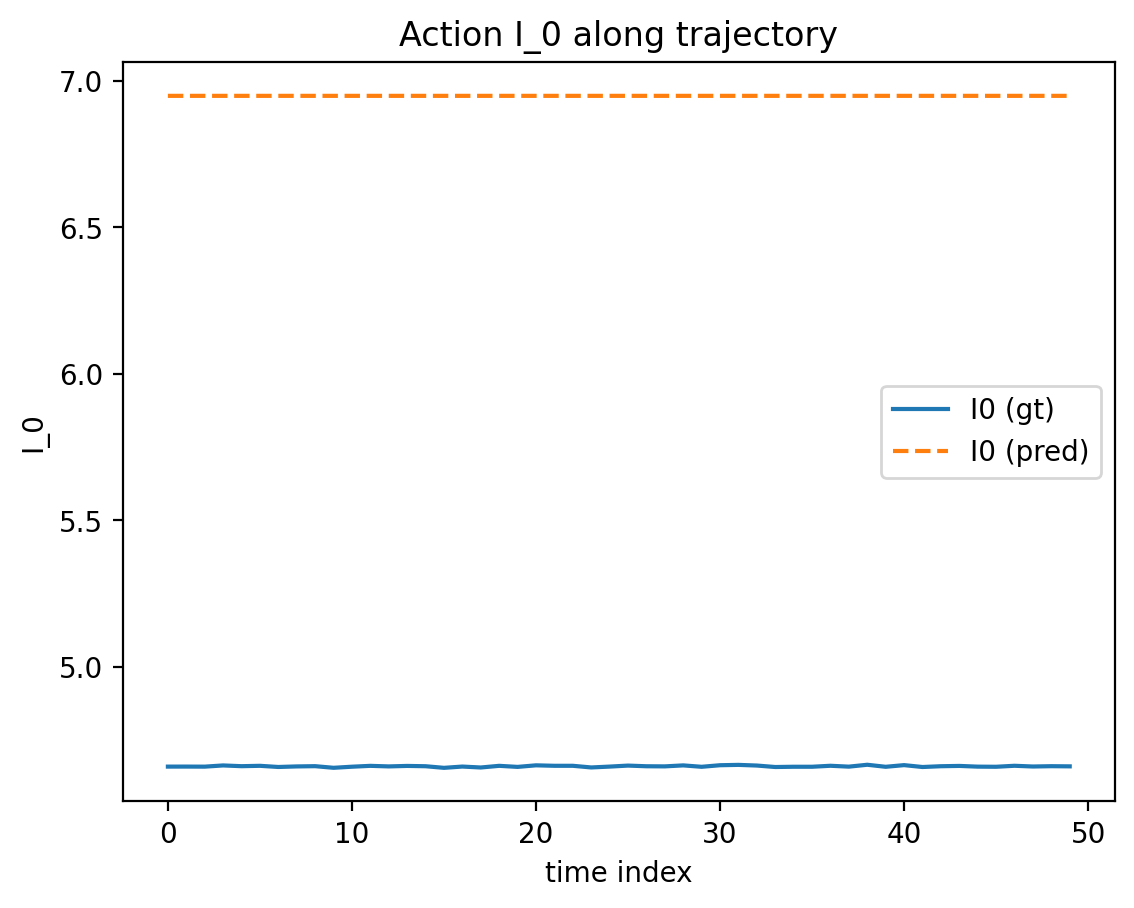

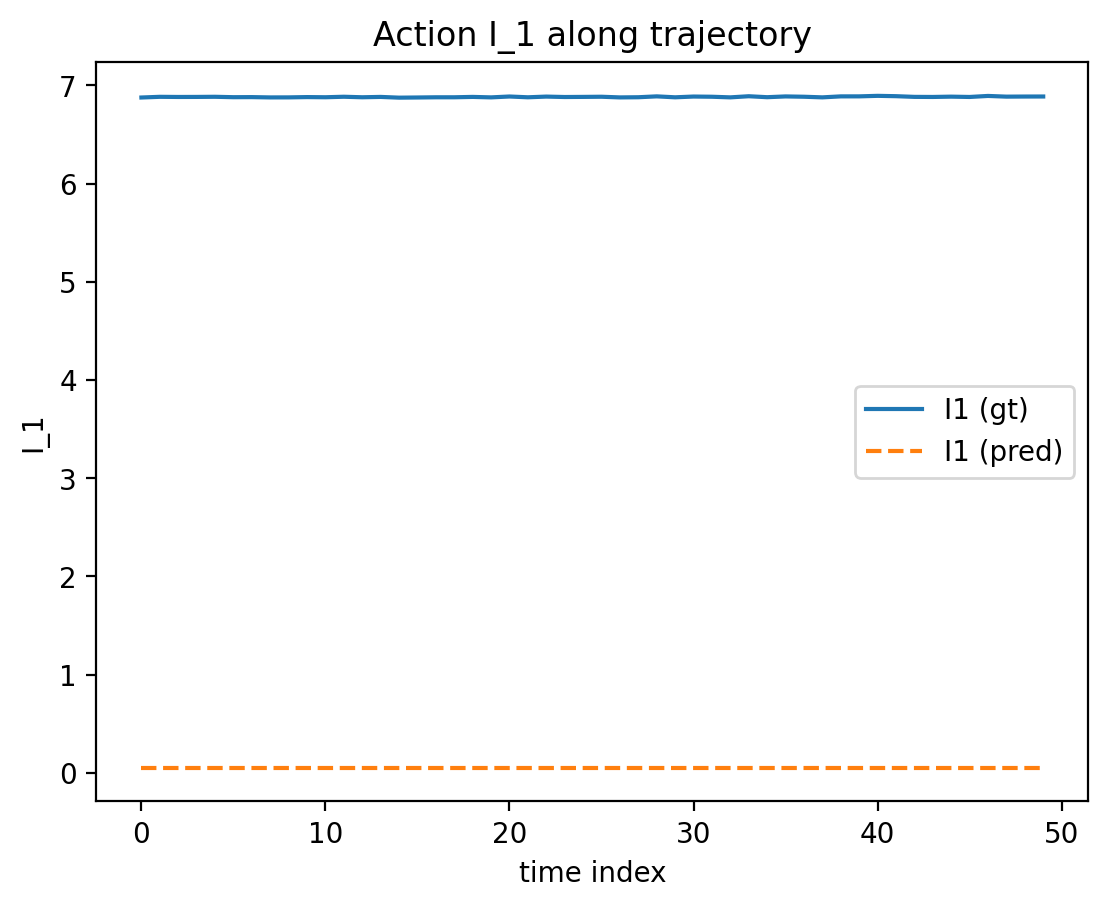

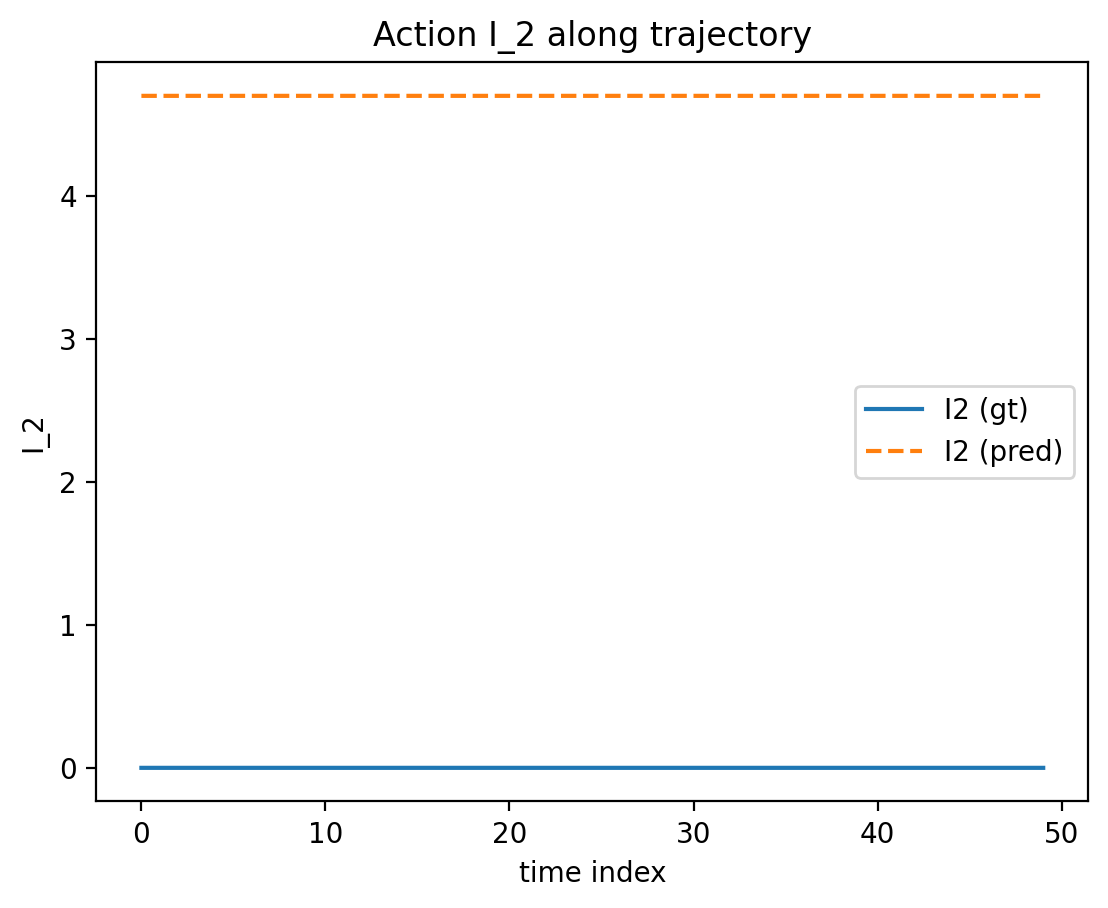

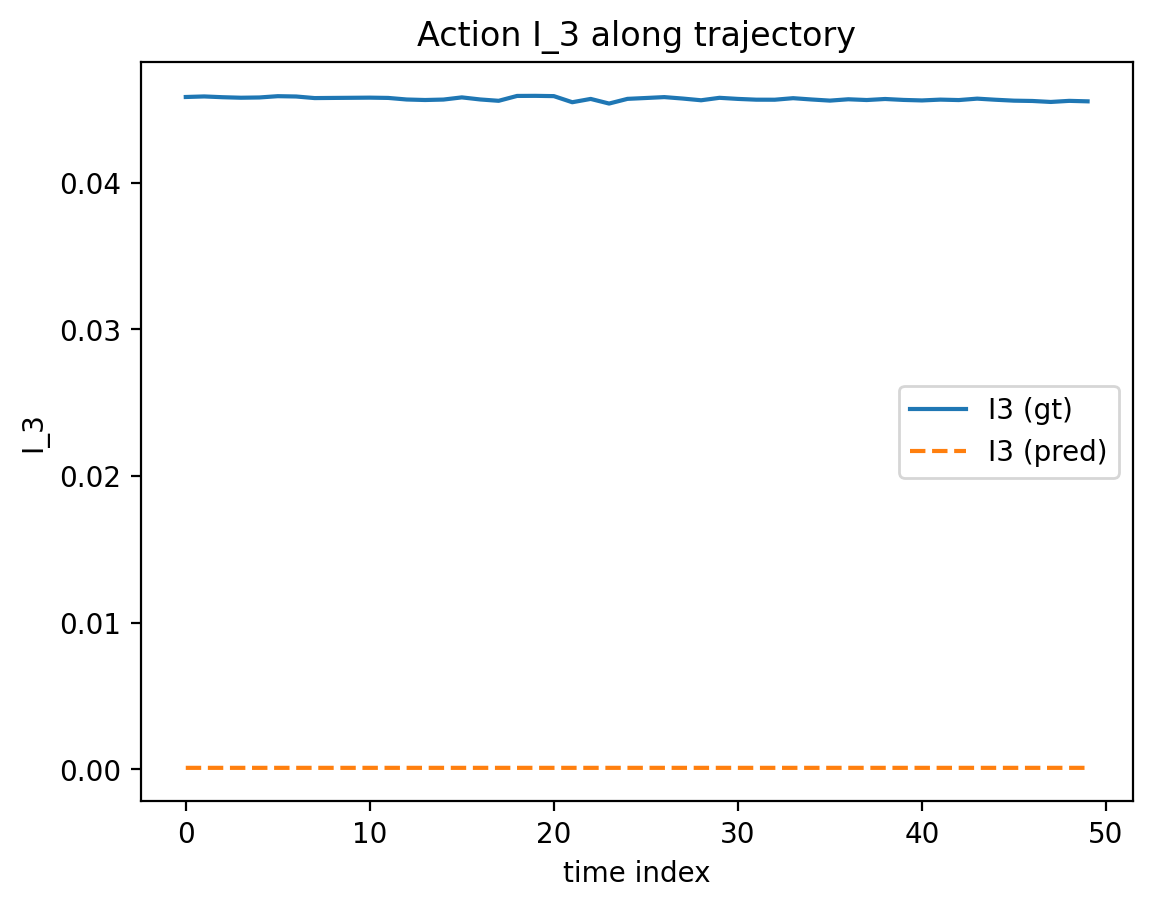

In [51]:

# --- Hamiltonian / action diagnostics ---
sim_params = hyper_params

q_plot = np.asarray(q_true_np)
p_plot = np.asarray(p_true_np)

H_true_vals = H_ground_truth(q_plot, p_plot, sim_params)
I_true_vals, theta_true_vals, omega_vals, U_vals = action_angle_ground_truth(q_plot, p_plot, sim_params)

H_pred_vals = predict_hamiltonian(nn_params_dif_loss, q_pred_direct_dif_loss_np, p_pred_direct_dif_loss_np)
I_pred_vals, theta_pred_vals = predict_action_angle(nn_params_dif_loss, q_pred_direct_dif_loss_np, p_pred_direct_dif_loss_np)

plt.figure()
plt.plot(H_true_vals-jnp.mean(H_true_vals), label='H (ground truth)')
plt.plot(H_pred_vals-jnp.mean(H_pred_vals), '--', label='H (predicted)')
plt.xlabel('time index')
plt.ylabel('Hamiltonian')
plt.title('Hamiltonian along trajectory')
plt.legend()
plt.show()

max_modes = min(4, I_true_vals.shape[1])
for j_mode in range(max_modes):
    plt.figure()
    plt.plot(I_true_vals[:, j_mode], label=f'I{j_mode} (gt)')
    plt.plot(I_pred_vals[:, j_mode], '--', label=f'I{j_mode} (pred)')
    plt.xlabel('time index')
    plt.ylabel(f'I_{j_mode}')
    plt.title(f'Action I_{j_mode} along trajectory')
    plt.legend()
    plt.show()




# Previous way of training (use long trajectory)

In [ ]:
rng = jax.random.PRNGKey(0)
q0 = jnp.zeros((1, int(n)))
p0 = jnp.zeros((1, int(n)))
delta_t0 = jnp.asarray(0.1)

variables = model.init(rng, q0, p0, delta_t0)
params_old = variables['params']
num_params = sum(jax.tree_util.tree_leaves(jax.tree_util.tree_map(lambda x: x.size, params_old)))
print(f'Total parameters: {num_params}')


In [ ]:
# t, q, p は前セルのシミュレーション出力。q, p の shape は (T, n)
sub1, sub2 = jax.random.split(jax.random.PRNGKey(42), 2)

T_steps = 5000
t, q, p, aux = flow_coupled_1d_harmonic_init_values(
    params=set_harmonic_params(n=n, m=m, k_wall=k_wall, k_pair=k_pair),
    num_steps=tuple(np.arange(0, T_steps).tolist()),
    dt=dt,
    q0=jax.random.normal(sub1, (1,n)),
    p0=jax.random.normal(sub2, (1,n)),
)


# 時系列で分割（情報漏洩を防ぐため、時間で切る）
frac_train = 0.2
#frac_test  = 0.5

T_train = int(T_steps * frac_train)
#T_test  = int(T * frac_test)

q_train = jnp.asarray(q[:T_train])
p_train = jnp.asarray(p[:T_train])

# q_test  = jnp.asarray(q[-T_test:])
# p_test  = jnp.asarray(p[-T_test:])


In [ ]:
@jit
def train_step_old(params, opt_state, x, y, delta_t, alpha, key):
    # x: (B, 2n) current (q, p)
    # y: (B, 2n) target  (q, p)
    T = x.shape[0]
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]  # (B, n), (B, n)

    def loss_fn(pp):
        q_, p_, I, _ = model.apply({'params': pp}, q, p, delta_t, train=True, rngs={'noise': key})
        #x_ = jnp.concatenate([q_, p_], axis=-1)
        # q_, p_: (B, n), (B, n)
        # I: (B, n) actions
        
        # prediction loss
        loss_q_se = (1./(1.+delta_t))*((q_ - y[:, :n]) ** 2).sum()#.mean()
        loss_p_se = (1./(1.+delta_t))*((p_ - y[:, n:]) ** 2).sum()#.mean()

        # actions should be constant
        loss_action = jnp.var(I, axis=0).sum()
        # ここではqとpは同じ初期値からスタートした軌道上の点たちなので、actionは一定であるべきという制約である

        return loss_q_se + loss_p_se + alpha * loss_action

    loss, grads = value_and_grad(loss_fn)(params)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

@jit
def eval_batch_old(params, x, y, delta_t, key):
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]  # (B, 3), (B, 3)
    
    q_, p_, _, _ = model.apply({'params': params}, q, p, delta_t, train=False, rngs={'noise': key})
    #x_ = jnp.concatenate([q_, p_], axis=-1)

    loss_q_mse = ((q_ - y[:, :n]) ** 2).mean()
    loss_p_mse = ((p_ - y[:, n:]) ** 2).mean()

    return loss_q_mse + loss_p_mse


In [ ]:
num_steps = 5000
delta_t_max = dt*10 # maximum jump (see Eq.(10) in the paper)

batch_size = 100
log_every = 100
test_time_jumps = [1,2,5,10,20,50]
alpha = 1 #0.5  # weight for action constancy loss

normalize_qp = True

key = random.PRNGKey(0)
eval_key  = random.PRNGKey(42)

delta_t_train_list = []

print("Start training...")
print(f"num_steps: {num_steps}, delta_t_max: {delta_t_max}, batch_size: {batch_size}, log_every: {log_every}")
print(f"test_time_jumps: {test_time_jumps}")
print(f"alpha (weight for action constancy loss): {alpha}")


for step in range(1, num_steps + 1):
    rng, sub1, sub2, sub3 = jax.random.split(rng, 4)

    # jump幅をサンプル
    max_time_jump_for_step = 1 + (step / num_steps) * (delta_t_max//dt - 1)
    jump = jax.random.randint(sub1, shape=(), minval=1, maxval=max_time_jump_for_step + 1)
    # jump_max = jax.random.randint(sub1, shape=(), minval=1, maxval=int( step/num_steps * delta_t_max ) + 1 )
    # jump = jax.random.randint(sub2, shape=(), minval=1, maxval=jump_max+1)
    # jumpはあくまでステップ幅であり実時間ではない、実時間を計算
    delta_t_scalar = jnp.asarray(dt * jump)
    delta_t_train_list.append(float(delta_t_scalar))
    
    # n_train - jump このペアを作る
    curr_q, curr_p = q_train[:-jump], p_train[:-jump]
    tgt_q, tgt_p = q_train[jump:], p_train[jump:]

    # 重複を許してbatch_size個サンプル
    batch_size = min(batch_size, curr_q.shape[0]) # curr_qの数がとても小さいときはそれを上限にする
    idx_sample = jax.random.choice(
        sub3, curr_q.shape[0], shape=(batch_size,), replace=False
    )
    batch = (
        curr_q[idx_sample], curr_p[idx_sample],
        tgt_q[idx_sample], tgt_p[idx_sample],
    )

    #batch = sample_train_batch(sub)
    # batch = train_curr_q[idx], train_curr_p[idx], train_tgt_q[idx],  train_tgt_p[idx],

    params_old, opt_state, train_loss = train_step_old(
        params=params_old,
        opt_state=opt_state,
        x=jnp.concatenate([batch[0], batch[1]], axis=-1),
        y=jnp.concatenate([batch[2], batch[3]], axis=-1),
        alpha=alpha,
        delta_t=delta_t_scalar,
        key=rng
    )

    if step % log_every == 0 or step == 1:

        test_loss_list = []
        for jump in test_time_jumps:
            test_curr_q, test_curr_p = q_test[:-jump], p_test[:-jump] # (T-jump, n)
            test_tgt_q, test_tgt_p = q_test[jump:], p_test[jump:] # (T-jump, n)
            delta_t_test = dt * jump
            test_loss_jump = eval_batch_old(
                params=params_old,
                x=jnp.concatenate([test_curr_q, test_curr_p], axis=-1), 
                y=jnp.concatenate([test_tgt_q, test_tgt_p], axis=-1),
                delta_t=delta_t_test,
                key=eval_key
            )
            test_loss_list.append(test_loss_jump)
        
        test_str = ", ".join(f"jump={j}: {float(l):.6f}"
                            for j, l in zip(test_time_jumps, test_loss_list))
        print(f"step {step:5d}  train_loss {float(train_loss):.6f}  test_loss [{test_str}]")

        # print(f"step {step:5d}  train_loss {float(train_loss):.6f}  test_loss {float(test_loss_list):.6f}")
        # wandb.log({
        #     "train/loss": float(train_loss),
        #     "test/loss": float(test_loss),
        #     "step": step,
        # })



        # for jump in test_time_jumps:
        #     test_curr_q.append( q_test[:-jump] )
        #     test_curr_p.append( p_test[:-jump] )
        #     test_tgt_q.append( q_test[jump:] )
        #     test_tgt_p.append( p_test[jump:] )
        #     delta_t_test.append(jnp.repeat(dt * jump, q_test.shape[0]-jump))
        # test_curr_q = jnp.concatenate(test_curr_q, axis=0)
        # test_curr_p = jnp.concatenate(test_curr_p, axis=0)
        # test_tgt_q  = jnp.concatenate(test_tgt_q, axis=0)
        # test_tgt_p  = jnp.concatenate(test_tgt_p, axis=0)
        # delta_t_test = jnp.concatenate(delta_t_test, axis=0)

        
        # test_loss = eval_batch(
        #     params=params,
        #     x=jnp.concatenate([test_curr_q, test_curr_p], axis=-1), 
        #     y=jnp.concatenate([test_tgt_q, test_tgt_p], axis=-1),
        #     delta_t=delta_t_test,
        #     key=eval_key
        # )
        

In [ ]:
plt.plot(delta_t_train_list)


In [ ]:
1 + (step / num_steps) * (delta_t_max//dt - 1)

In [ ]:

T_total = 50  # 欲しいステップ数に合わせて調整

Ts = tuple(np.arange(0, T_total).tolist())

q0 = test_dataset[0][0:1, :n]  # shape (1, n)
p0 = test_dataset[0][0:1, n:]

# train_idx = 0
# q0 = train_dataset[0][train_idx:train_idx+1, :n]  # shape (1, n)
# p0 = train_dataset[0][train_idx:train_idx+1, n:]
# delta_t_infer = train_dataset[3][train_idx:train_idx+1]
# print(delta_t_infer)


t_vec, q_true, p_true, _ = flow_coupled_1d_harmonic_init_values(
    params=set_harmonic_params(n=n, m=m, k_wall=k_wall, k_pair=k_pair),
    num_steps=tuple(np.arange(0, T_total).tolist()),
    dt=dt,
    q0=q0,
    p0=p0,
)


def step_fn(carry, _):
    q_curr, p_curr = carry
    q_next, p_next, _, _ = model.apply(
        {'params': params_old}, q_curr, p_curr, dt, train=False
    )
    return (q_next, p_next), (q_next, p_next)

if T_total <= 1:
    q_pred = q0
    p_pred = p0
else:
    (_, _), (qs_seq, ps_seq) = jax.lax.scan(
        step_fn, (q0, p0), None, length=T_total - 1
    )
    if qs_seq.ndim == 3:
        qs_seq = jnp.squeeze(qs_seq, axis=1)
        ps_seq = jnp.squeeze(ps_seq, axis=1)
    q_pred = jnp.concatenate([q0, qs_seq], axis=0)
    p_pred = jnp.concatenate([p0, ps_seq], axis=0)

t_arr = np.asarray(t[:T_total])
q_true_np = np.asarray(q_true)[:T_total]
p_true_np = np.asarray(p_true)[:T_total]
q_pred_np = np.asarray(q_pred)
p_pred_np = np.asarray(p_pred)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for i in range(q_pred_np.shape[1]):
    axes[0].plot(t_arr, q_true_np[:, i], label=f'true q[{i}]', alpha=0.7)
    axes[0].plot(t_arr, q_pred_np[:, i], '--', label=f'pred q[{i}]', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].grid(True)
axes[0].legend(ncol=2, fontsize=8)

for i in range(p_pred_np.shape[1]):
    axes[1].plot(t_arr, p_true_np[:, i], label=f'true p[{i}]', alpha=0.7)
    axes[1].plot(t_arr, p_pred_np[:, i], '--', label=f'pred p[{i}]', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].grid(True)
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()



In [ ]:
# --- 真値 vs モデル予測（同一初期値；直接推定）---

delta_t_vec = jnp.arange(T_total) * dt

q0_batch = jnp.repeat(q0, repeats=T_total, axis=0)
p0_batch = jnp.repeat(p0, repeats=T_total, axis=0)

q_pred_direct, p_pred_direct, _, _ = model.apply(
    {'params': params_old}, q0_batch, p0_batch, delta_t_vec, train=False
)

q_pred_direct_np = np.asarray(q_pred_direct)
p_pred_direct_np = np.asarray(p_pred_direct)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for i in range(q_pred_direct_np.shape[1]):
    axes[0].plot(t_arr, q_true_np[:, i], label=f'true q[{i}]', alpha=0.7)
    axes[0].plot(t_arr, q_pred_direct_np[:, i], '--', label=f'direct pred q[{i}]', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].grid(True)
axes[0].legend(ncol=2, fontsize=8)

for i in range(p_pred_direct_np.shape[1]):
    axes[1].plot(t_arr, p_true_np[:, i], label=f'true p[{i}]', alpha=0.7)
    axes[1].plot(t_arr, p_pred_direct_np[:, i], '--', label=f'direct pred p[{i}]', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].grid(True)
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# evaluate test errors on test_dataset for each delta_t

x_test, _, y_test, delta_t_test = test_dataset
n_conf = x_test.shape[1] // 2

q_test = x_test[:, :n_conf]
p_test = x_test[:, n_conf:]
q_target = y_test[:, :n_conf]
p_target = y_test[:, n_conf:]

q_pred_test_orig_aan, p_pred_test_orig_aan, _, _ = model.apply(
    {'params': params}, q_test, p_test, delta_t_test, train=False
)

per_sample_q_orig_aan_rmse = jnp.sqrt(jnp.mean((q_pred_test_orig_aan - q_target) ** 2, axis=1))
per_sample_p_orig_aan_rmse = jnp.sqrt(jnp.mean((p_pred_test_orig_aan - p_target) ** 2, axis=1))

delta_t_np = np.asarray(delta_t_test)
step_counts_per_sample = np.rint(delta_t_np / float(dt)).astype(int)
unique_steps = np.unique(step_counts_per_sample)

per_sample_q_orig_aan_rmse_np = np.asarray(per_sample_q_orig_aan_rmse)
per_sample_p_orig_aan_rmse_np = np.asarray(per_sample_p_orig_aan_rmse)
q_rmse_by_step_orig_aan = []
p_rmse_by_step_orig_aan = []
for step in unique_steps:
    mask = step_counts_per_sample == step
    q_rmse_by_step_orig_aan.append(per_sample_q_orig_aan_rmse_np[mask].mean())
    p_rmse_by_step_orig_aan.append(per_sample_p_orig_aan_rmse_np[mask].mean())

plt.figure(figsize=(7, 4))
plt.plot(unique_steps, q_rmse_by_step_orig_aan, 'o-', label='q RMSE')
plt.plot(unique_steps, p_rmse_by_step_orig_aan, 's-', label='p RMSE')
plt.xticks(unique_steps)
plt.xlabel('prediction horizon (steps)')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.4)
plt.legend()
plt.title('Test error vs prediction horizon')
plt.show()


In [ ]:

# --- Hamiltonian / action diagnostics ---
sim_params = hyper_params

q_plot = np.asarray(q_true_np)
p_plot = np.asarray(p_true_np)

H_true_vals = H_ground_truth(q_plot, p_plot, sim_params)
I_true_vals, theta_true_vals, omega_vals, U_vals = action_angle_ground_truth(q_plot, p_plot, sim_params)

H_pred_vals = predict_hamiltonian(params, q_plot, p_plot)
I_pred_vals, theta_pred_vals = predict_action_angle(params, q_plot, p_plot)

plt.figure()
plt.plot(H_true_vals-jnp.mean(H_true_vals), label='H (ground truth)')
plt.plot(H_pred_vals-jnp.mean(H_pred_vals), '--', label='H (predicted)')
plt.xlabel('time index')
plt.ylabel('Hamiltonian')
plt.title('Hamiltonian along trajectory')
plt.legend()
plt.show()

# plt.figure()
# plt.plot(H_pred_vals - H_true_vals)
# plt.xlabel('time index')
# plt.ylabel('H_pred - H_true')
# plt.title('Hamiltonian error along trajectory')
# plt.show()

max_modes = min(4, I_true_vals.shape[1])
for j_mode in range(max_modes):
    plt.figure()
    plt.plot(I_true_vals[:, j_mode], label=f'I{j_mode} (gt)')
    plt.plot(I_pred_vals[:, j_mode], '--', label=f'I{j_mode} (pred)')
    plt.xlabel('time index')
    plt.ylabel(f'I_{j_mode}')
    plt.title(f'Action I_{j_mode} along trajectory')
    plt.legend()
    plt.show()

# def _wrap_pi(arr):
#     return (arr + np.pi) % (2 * np.pi) - np.pi

# for j_mode in range(max_modes):
#     plt.figure()
#     plt.plot(_wrap_pi(theta_true_vals[:, j_mode]), label=f'theta{j_mode} (gt)')
#     plt.plot(_wrap_pi(theta_pred_vals[:, j_mode]), '--', label=f'theta{j_mode} (pred)')
#     plt.xlabel('time index')
#     plt.ylabel(f'theta_{j_mode}')
#     plt.title(f'Angle theta_{j_mode} along trajectory')
#     plt.legend()
#     plt.show()



# HHN

In [52]:
x0_train, x0_dot_train, xt_train, t_train = train_dataset
x0_test, x0_dot_test, xt_test, t_test     = test_dataset

Total parameters: 17793


2025-11-25 15:59:42.049073: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-11-25 15:59:42.049112: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


[HNN] Epoch 1/100  test MSE: 2.898514e+02
[HNN] Epoch 2/100  test MSE: 2.895659e+02
[HNN] Epoch 3/100  test MSE: 2.886235e+02
[HNN] Epoch 4/100  test MSE: 2.856798e+02
[HNN] Epoch 5/100  test MSE: 2.784685e+02
[HNN] Epoch 6/100  test MSE: 2.664153e+02
[HNN] Epoch 7/100  test MSE: 2.527233e+02
[HNN] Epoch 8/100  test MSE: 2.400300e+02
[HNN] Epoch 9/100  test MSE: 2.285356e+02
[HNN] Epoch 10/100  test MSE: 2.184543e+02
[HNN] Epoch 11/100  test MSE: 2.091689e+02
[HNN] Epoch 12/100  test MSE: 2.005866e+02
[HNN] Epoch 13/100  test MSE: 1.926132e+02
[HNN] Epoch 14/100  test MSE: 1.849814e+02
[HNN] Epoch 15/100  test MSE: 1.780840e+02
[HNN] Epoch 16/100  test MSE: 1.710423e+02
[HNN] Epoch 17/100  test MSE: 1.646487e+02
[HNN] Epoch 18/100  test MSE: 1.586953e+02
[HNN] Epoch 19/100  test MSE: 1.529893e+02
[HNN] Epoch 20/100  test MSE: 1.474599e+02
[HNN] Epoch 21/100  test MSE: 1.422359e+02
[HNN] Epoch 22/100  test MSE: 1.373902e+02
[HNN] Epoch 23/100  test MSE: 1.327787e+02
[HNN] Epoch 24/100  

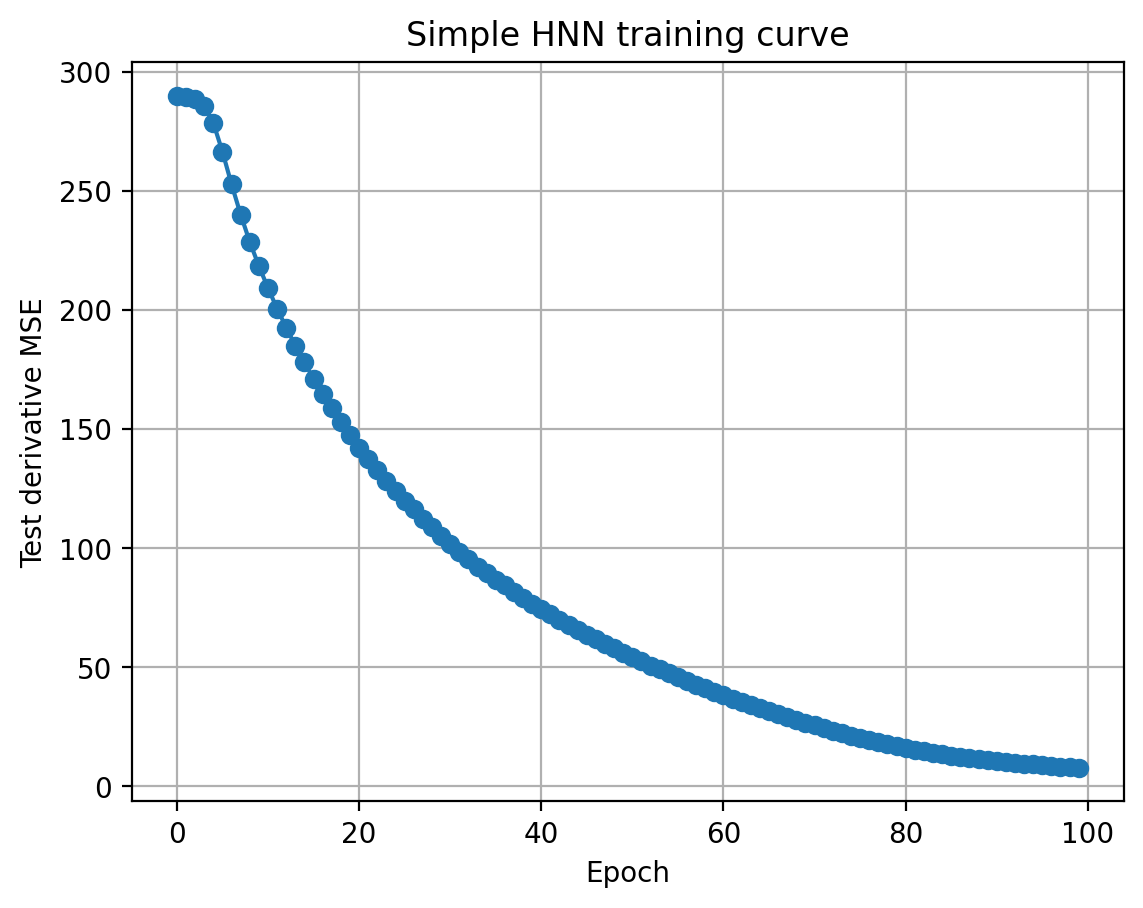

In [53]:

# --- Simple Hamiltonian Neural Network (HNN) training demo ---
import functools
#from flax import linen as fnn
import optax

class SimpleHNN(nn.Module):
    dim: int
    hidden: int = 128

    @nn.compact
    def __call__(self, coords):
        x = coords # (B, 2n)
        x = nn.tanh(nn.Dense(self.hidden)(x))
        x = nn.tanh(nn.Dense(self.hidden)(x))
        H = nn.Dense(1)(x)
        return H.squeeze(-1)

def hnn_time_derivative(params, model, coords):
    def total_energy(z):
        return model.apply(params, z).sum()
    grad_H = jax.grad(total_energy)(coords)
    n_dim = coords.shape[-1] // 2
    dqdt = grad_H[:, n_dim:]
    dpdt = -grad_H[:, :n_dim]
    return jnp.concatenate([dqdt, dpdt], axis=-1)

# Use the same training data but only current coordinates and their time-derivatives.
coords_test = test_dataset[0]
derivs_test = test_dataset[1]

hnn_model = SimpleHNN(dim=x0_train.shape[1])
rng = jax.random.PRNGKey(123)
params_hnn = hnn_model.init(rng, x0_train[:batch_size])

num_params = sum(jax.tree_util.tree_leaves(jax.tree_util.tree_map(lambda x: x.size, params_hnn['params'])))
print(f'Total parameters: {num_params}')

tx_hnn = optax.adam(learning_rate=1e-3)
opt_state_hnn = tx_hnn.init(params_hnn)

@functools.partial(jax.jit, static_argnums=0)
def train_step_hnn(model, params, opt_state, coords, derivs):
    def loss_fn(p):
        pred = hnn_time_derivative(p, model, coords)
        return jnp.mean((pred - derivs) ** 2)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = tx_hnn.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

@functools.partial(jax.jit, static_argnums=0)
def eval_step_hnn(model, params, coords, derivs):
    pred = hnn_time_derivative(params, model, coords)
    return jnp.mean((pred - derivs) ** 2)


hnn_epochs = 100
hnn_losses = []
for ep in range(hnn_epochs):
    perm_key, rng = jax.random.split(rng)
    perm = jax.random.permutation(perm_key, x0_train.shape[0])
    x0_train = x0_train[perm]
    x0_dot_train = x0_dot_train[perm]
    num_batches = x0_train.shape[0] // batch_size
    for i in range(num_batches):
        batch_coords = x0_train[i*batch_size:(i+1)*batch_size]
        batch_derivs = x0_dot_train[i*batch_size:(i+1)*batch_size]
        params_hnn, opt_state_hnn, loss_val = train_step_hnn(
            hnn_model, params_hnn, opt_state_hnn, batch_coords, batch_derivs
        )
    test_loss = eval_step_hnn(hnn_model, params_hnn, coords_test, derivs_test)
    hnn_losses.append(float(test_loss))
    print(f"[HNN] Epoch {ep+1}/{hnn_epochs}  test MSE: {float(test_loss):.6e}")

plt.figure()
plt.plot(hnn_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Test derivative MSE')
plt.title('Simple HNN training curve')
plt.grid(True)
plt.show()


In [54]:
test_loss = eval_step_hnn(hnn_model, params_hnn, coords_test, derivs_test)

In [55]:
# q0=jax.random.normal(jax.random.PRNGKey(0), (1,n)),
# p0=jax.random.normal(jax.random.PRNGKey(42), (1,n)),
# coords0 = jnp.concatenate([jnp.array(q0), jnp.array(p0)], axis=-1)

# idx_train = 10
# q0 = train_dataset[0][idx_train:idx_train+1, :n]  # shape (1, n)
# p0 = train_dataset[0][idx_train:idx_train+1, n:]
# coords0 = jnp.concatenate([q0, p0], axis=-1)

q0 = test_dataset[0][0:1, :n]  # shape (1, n)
p0 = test_dataset[0][0:1, n:]
coords0 = jnp.concatenate([q0, p0], axis=-1)


T_total = 50  # 欲しいステップ数に合わせて調整

# ground truth
t_vec, q_true, p_true, _ = flow_coupled_1d_harmonic_init_values(
    params=set_harmonic_params(n=n, m=m, k_wall=k_wall, k_pair=k_pair),
    num_steps=tuple(np.arange(0, T_total).tolist()),
    dt=dt,
    q0=q0,
    p0=p0
)


# Estimates using HNN

def step_hnn(carry, _):
    coords = carry
    q_curr = coords[:, :n]
    p_curr = coords[:, n:]
    derivs = hnn_time_derivative(params_hnn, hnn_model, jnp.concatenate([q_curr, p_curr], axis=-1))
    next_coords = coords + derivs * dt
    return next_coords, next_coords

# Ensure the length is consistent with the expected number of steps
scan_length = 200
_, coords_scan = jax.lax.scan(step_hnn, coords0, None, length=scan_length)
coords_scan = jnp.concatenate([coords0[None,...], coords_scan], axis=0)
coords_scan = np.asarray(coords_scan)
q_hnn_pred = np.squeeze(coords_scan[..., :n], axis=1)
p_hnn_pred = np.squeeze(coords_scan[..., n:], axis=1)
if q_hnn_pred.ndim == 1:
    q_hnn_pred = q_hnn_pred[:, None]
if p_hnn_pred.ndim == 1:
    p_hnn_pred = p_hnn_pred[:, None]

/tmp/1118436.4946/ipykernel_705193/4020243990.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


In [56]:
q_hnn_pred.shape

(201, 4)

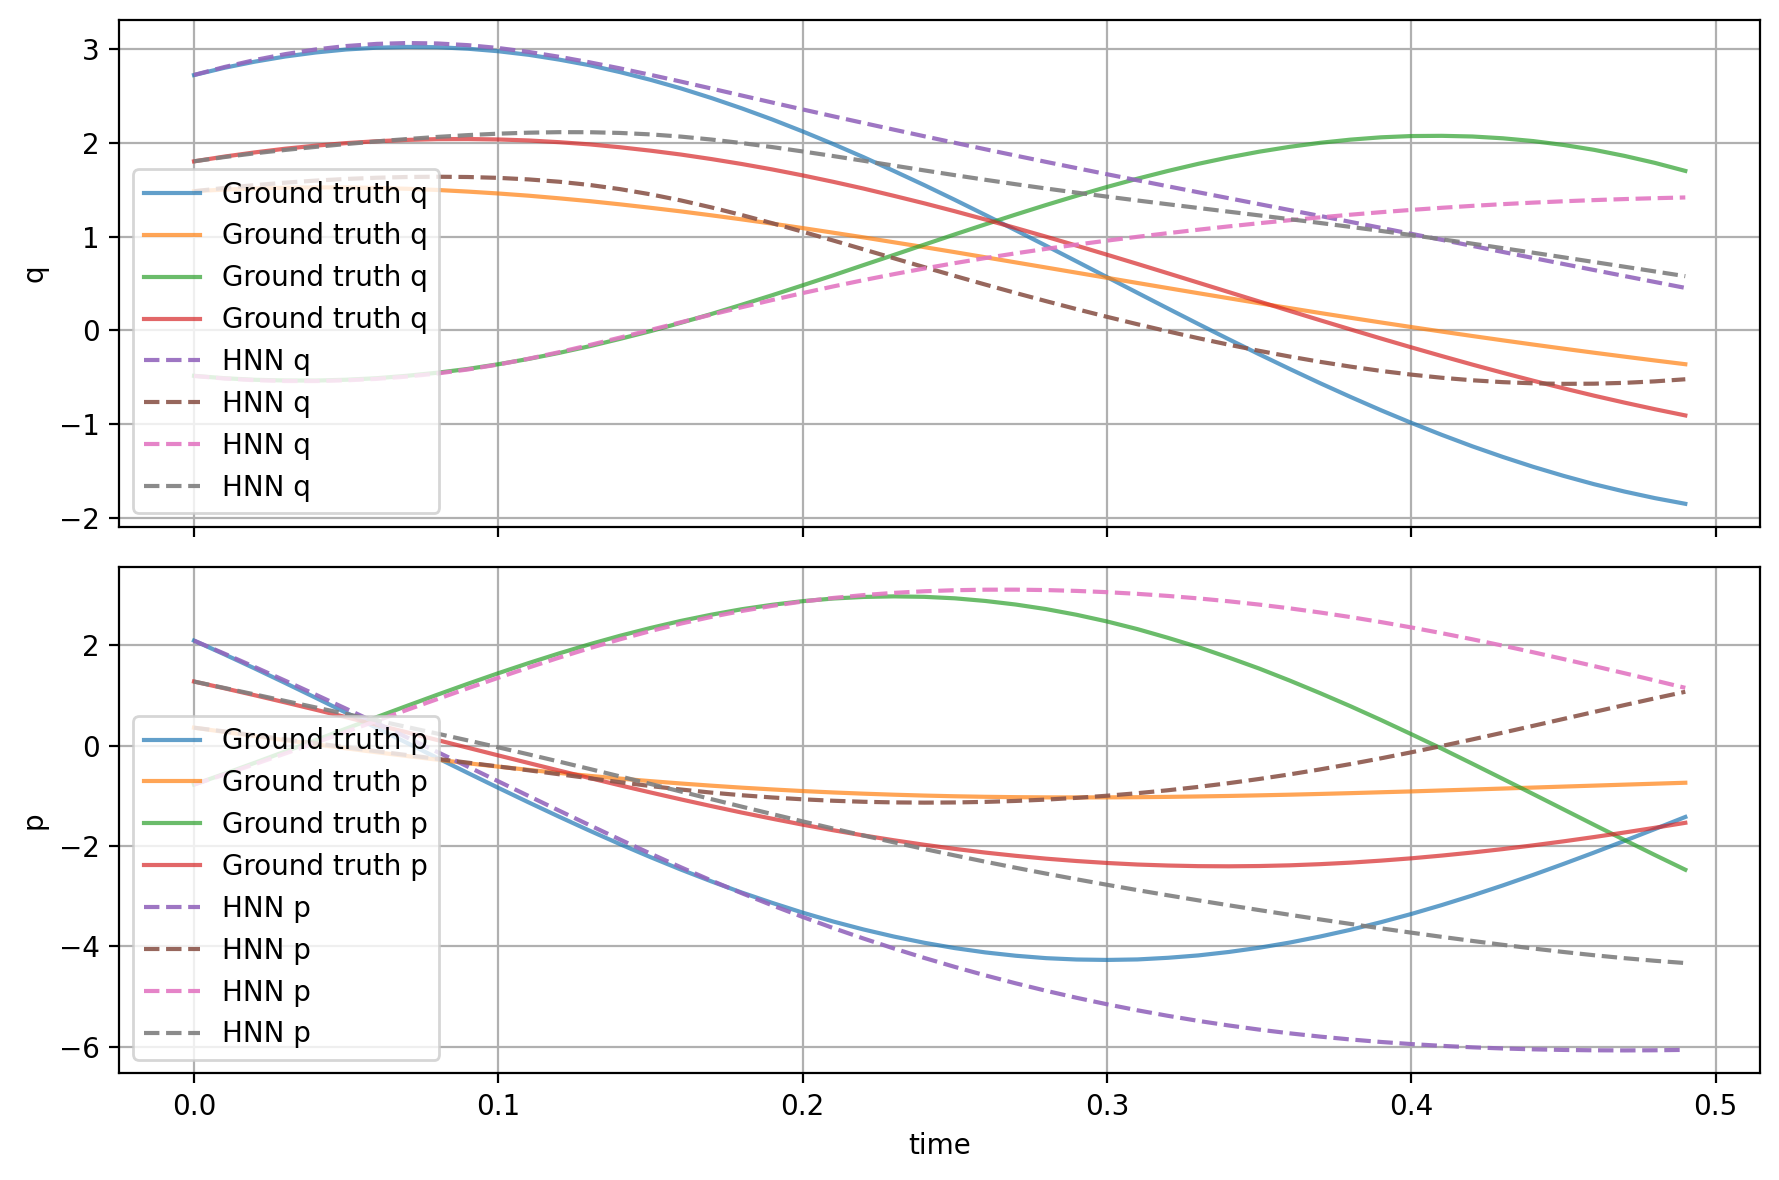

In [57]:

t_short = np.arange(coords_scan.shape[0]) * dt
q_true_arr = np.asarray(q_true)
p_true_arr = np.asarray(p_true)
min_len = min(t_short.shape[0], q_hnn_pred.shape[0], q_true_arr.shape[0], p_true_arr.shape[0])
t_short = t_short[:min_len]
q_pred_plot = q_hnn_pred[:min_len]
p_pred_plot = p_hnn_pred[:min_len]
q_gt_short = q_true_arr[:min_len]
p_gt_short = p_true_arr[:min_len]
if q_gt_short.ndim == 1:
    q_gt_short = q_gt_short[:, None]
if p_gt_short.ndim == 1:
    p_gt_short = p_gt_short[:, None]

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(t_short, q_gt_short[:, :], label='Ground truth q', alpha=0.7)
axes[0].plot(t_short, q_pred_plot[:, :], '--', label='HNN q', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_short, p_gt_short[:, :], label='Ground truth p', alpha=0.7)
axes[1].plot(t_short, p_pred_plot[:, :], '--', label='HNN p', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()



HNN per-horizon RMSE:
   1-step : q RMSE=1.8277e-02, p RMSE=2.4600e-02
   2-step : q RMSE=3.7327e-02, p RMSE=4.9108e-02
   5-step : q RMSE=1.0410e-01, p RMSE=1.2201e-01
  10-step : q RMSE=2.7078e-01, p RMSE=2.5138e-01
  20-step : q RMSE=8.4532e-01, p RMSE=7.7974e-01
  50-step : q RMSE=1.5702e+00, p RMSE=5.5065e+00
Overall q RMSE: 4.7433e-01
Overall p RMSE: 1.1222e+00


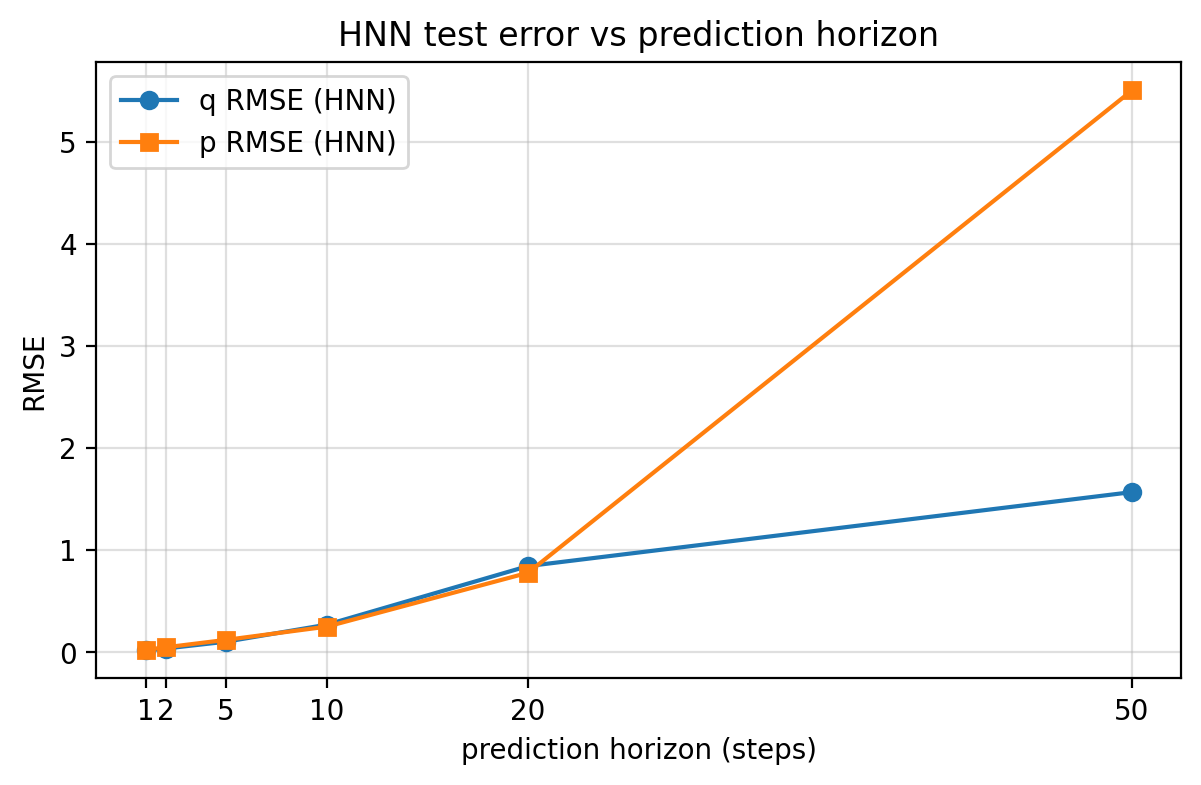

In [58]:
# Evaluate the test error of the simple HNN model

x0_test, x0_dot_test, xt_test, t_test = test_dataset
coords0_test = x0_test
step_counts_np = np.asarray(step_counts_test)

xt_pred_list = []
for i in range(coords0_test.shape[0]):
    num_steps = int(step_counts_np[i])
    _, coords_scan = jax.lax.scan(step_hnn, coords0_test[i:i+1], None, length=num_steps)
    xt_pred_list.append(coords_scan[-1])

xt_pred = jnp.concatenate(xt_pred_list, axis=0)

q_true_hnn = xt_test[:, :n]
p_true_hnn = xt_test[:, n:]
q_pred_hnn = xt_pred[:, :n]
p_pred_hnn = xt_pred[:, n:]

per_sample_q_rmse_hnn = jnp.sqrt(jnp.mean((q_pred_hnn - q_true_hnn) ** 2, axis=1))
per_sample_p_rmse_hnn = jnp.sqrt(jnp.mean((p_pred_hnn - p_true_hnn) ** 2, axis=1))

per_sample_q_rmse_np = np.asarray(per_sample_q_rmse_hnn)
per_sample_p_rmse_np = np.asarray(per_sample_p_rmse_hnn)
unique_steps_hnn = np.unique(step_counts_np)

q_rmse_by_step_hnn = []
p_rmse_by_step_hnn = []
for step in unique_steps_hnn:
    mask = step_counts_np == step
    q_rmse_by_step_hnn.append(per_sample_q_rmse_np[mask].mean())
    p_rmse_by_step_hnn.append(per_sample_p_rmse_np[mask].mean())

overall_q_rmse = float(per_sample_q_rmse_np.mean())
overall_p_rmse = float(per_sample_p_rmse_np.mean())

print('HNN per-horizon RMSE:')
for step, q_rmse, p_rmse in zip(unique_steps_hnn, q_rmse_by_step_hnn, p_rmse_by_step_hnn):
    print(f"  {int(step):2d}-step : q RMSE={q_rmse:.4e}, p RMSE={p_rmse:.4e}")
print(f"Overall q RMSE: {overall_q_rmse:.4e}")
print(f"Overall p RMSE: {overall_p_rmse:.4e}")

plt.figure(figsize=(7, 4))
plt.plot(unique_steps_hnn, q_rmse_by_step_hnn, 'o-', label='q RMSE (HNN)')
plt.plot(unique_steps_hnn, p_rmse_by_step_hnn, 's-', label='p RMSE (HNN)')
plt.xticks(unique_steps_hnn)
plt.xlabel('prediction horizon (steps)')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.4)
plt.legend()
plt.title('HNN test error vs prediction horizon')
plt.show()


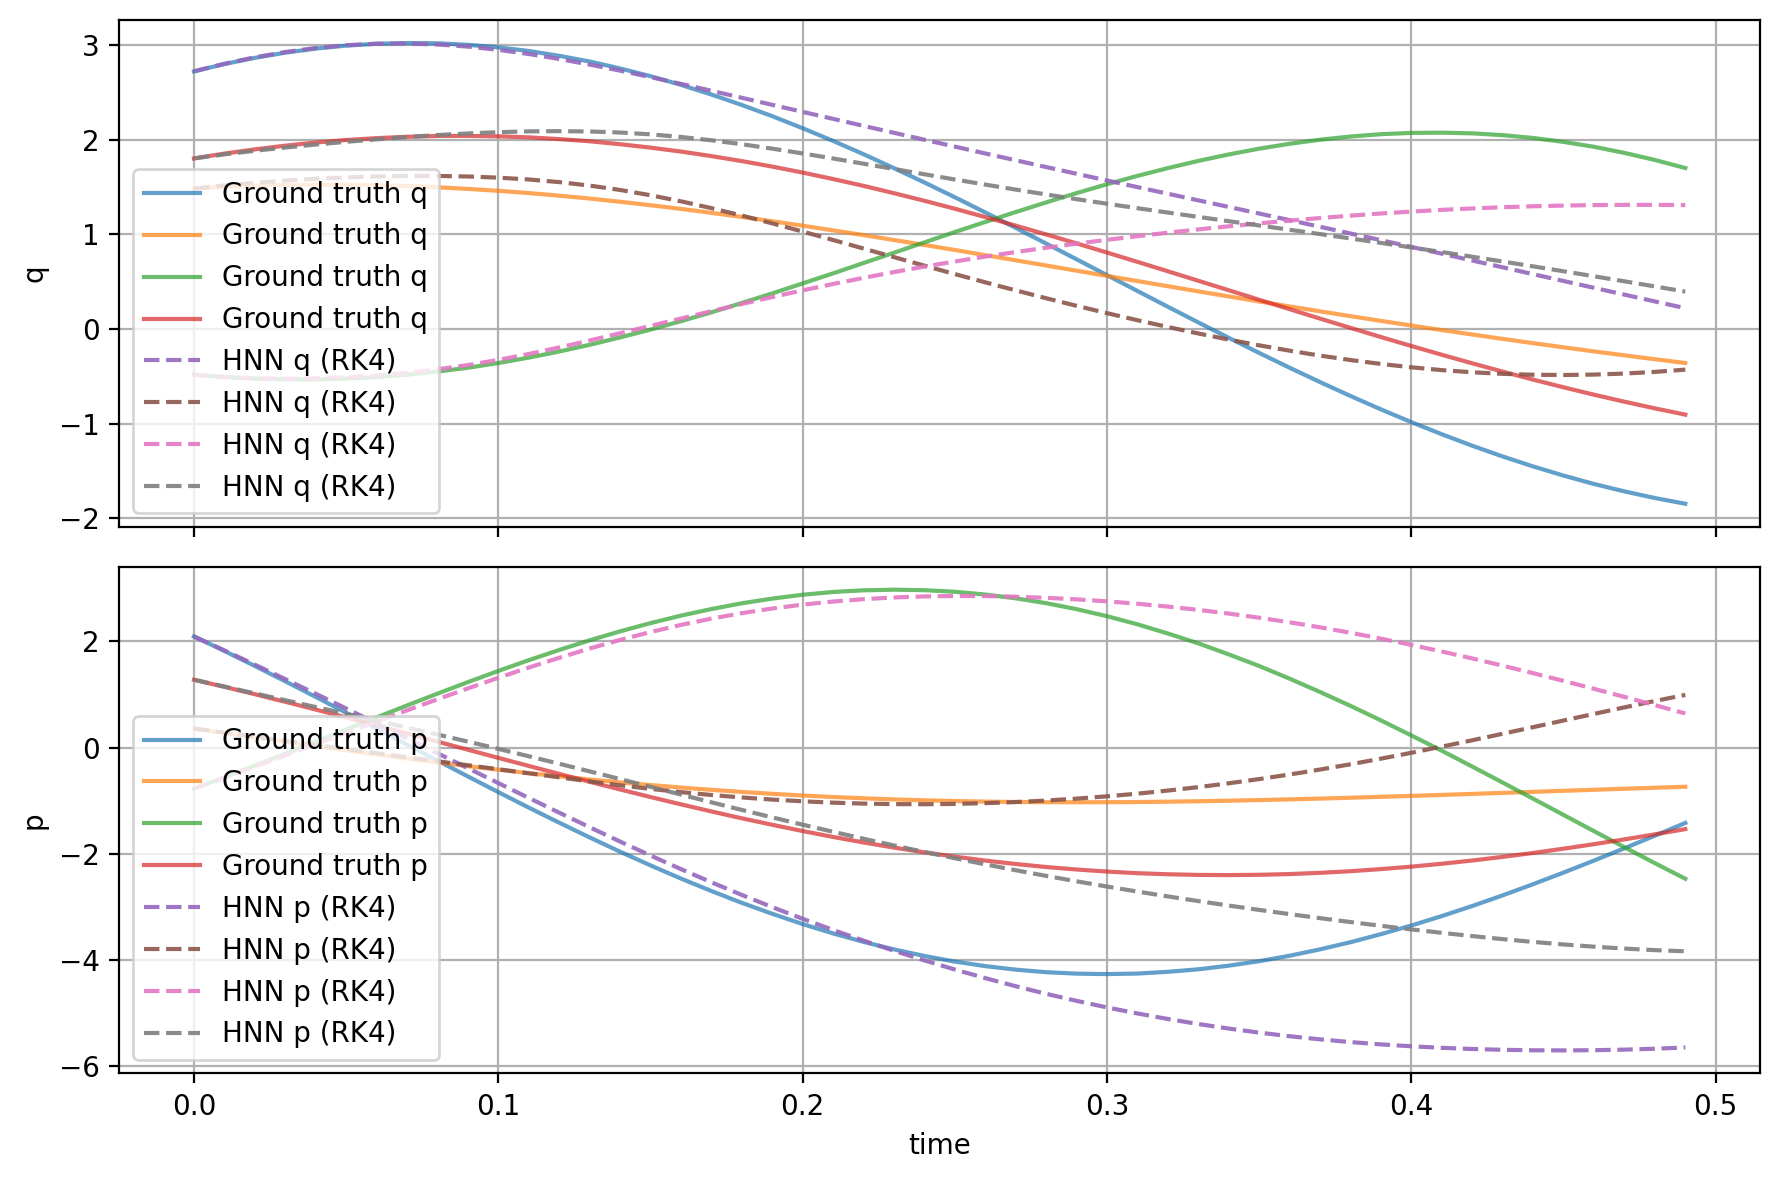

In [59]:
# Runge-Kutta (RK4) integration for HNN rollout

def rk4_step_hnn(carry, _):
    coords = carry
    def f(state):
        return hnn_time_derivative(params_hnn, hnn_model, state)
    k1 = f(coords)
    k2 = f(coords + 0.5 * dt * k1)
    k3 = f(coords + 0.5 * dt * k2)
    k4 = f(coords + dt * k3)
    next_coords = coords + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    return next_coords, next_coords

_, coords_scan_rk = jax.lax.scan(rk4_step_hnn, coords0, None, length=scan_length)
coords_scan_rk = jnp.concatenate([coords0[None, ...], coords_scan_rk], axis=0)
coords_scan_rk = np.asarray(coords_scan_rk)
q_hnn_pred_rk = np.squeeze(coords_scan_rk[..., :n], axis=1)
p_hnn_pred_rk = np.squeeze(coords_scan_rk[..., n:], axis=1)
if q_hnn_pred_rk.ndim == 1:
    q_hnn_pred_rk = q_hnn_pred_rk[:, None]
if p_hnn_pred_rk.ndim == 1:
    p_hnn_pred_rk = p_hnn_pred_rk[:, None]

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(t_short, q_gt_short[:, :], label='Ground truth q', alpha=0.7)
axes[0].plot(t_short, q_hnn_pred_rk[:len(t_short), :], '--', label='HNN q (RK4)', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_short, p_gt_short[:, :], label='Ground truth p', alpha=0.7)
axes[1].plot(t_short, p_hnn_pred_rk[:len(t_short), :], '--', label='HNN p (RK4)', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


HNN per-horizon RMSE:
   1-step : q RMSE=1.7856e-02, p RMSE=2.4232e-02
   2-step : q RMSE=3.6285e-02, p RMSE=4.8440e-02
   5-step : q RMSE=1.0042e-01, p RMSE=1.2056e-01
  10-step : q RMSE=2.6037e-01, p RMSE=2.4411e-01
  20-step : q RMSE=8.1851e-01, p RMSE=7.2082e-01
  50-step : q RMSE=1.4698e+00, p RMSE=5.1666e+00
Overall q RMSE: 4.5054e-01
Overall p RMSE: 1.0541e+00


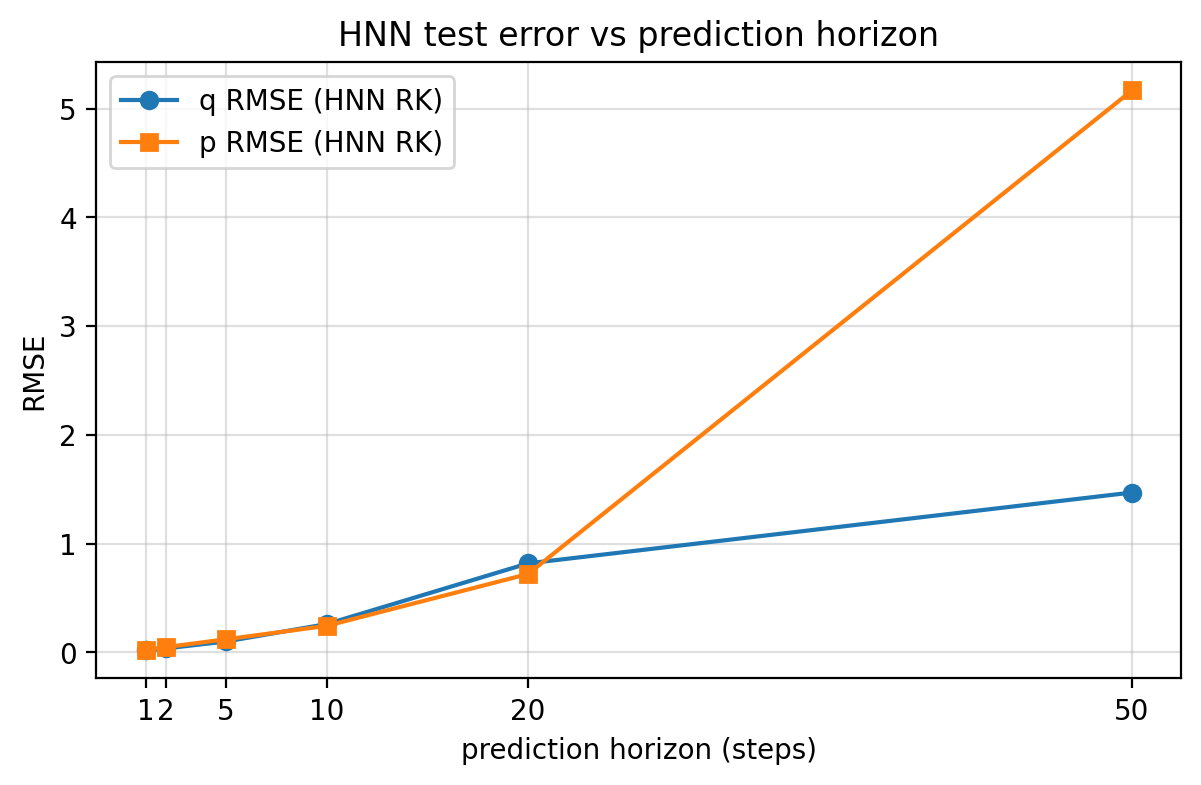

In [60]:
# Evaluate the test error of the simple HNN model

x0_test, x0_dot_test, xt_test, t_test = test_dataset
coords0_test = x0_test
step_counts_np = np.asarray(step_counts_test)

xt_pred_rk_list = []
for i in range(coords0_test.shape[0]):
    num_steps = int(step_counts_np[i])
    _, coords_scan = jax.lax.scan(rk4_step_hnn, coords0_test[i:i+1], None, length=num_steps)
    xt_pred_rk_list.append(coords_scan[-1])

xt_pred_rk = jnp.concatenate(xt_pred_rk_list, axis=0)

q_true_hnn = xt_test[:, :n]
p_true_hnn = xt_test[:, n:]
q_pred_hnn_rk = xt_pred_rk[:, :n]
p_pred_hnn_rk = xt_pred_rk[:, n:]

per_sample_q_rmse_hnn_rk = jnp.sqrt(jnp.mean((q_pred_hnn_rk - q_true_hnn) ** 2, axis=1))
per_sample_p_rmse_hnn_rk = jnp.sqrt(jnp.mean((p_pred_hnn_rk - p_true_hnn) ** 2, axis=1))

per_sample_q_rmse_np = np.asarray(per_sample_q_rmse_hnn_rk)
per_sample_p_rmse_np = np.asarray(per_sample_p_rmse_hnn_rk)
unique_steps_hnn = np.unique(step_counts_np)

q_rmse_by_step_hnn_rk = []
p_rmse_by_step_hnn_rk = []
for step in unique_steps_hnn:
    mask = step_counts_np == step
    q_rmse_by_step_hnn_rk.append(per_sample_q_rmse_np[mask].mean())
    p_rmse_by_step_hnn_rk.append(per_sample_p_rmse_np[mask].mean())

overall_q_rmse = float(per_sample_q_rmse_np.mean())
overall_p_rmse = float(per_sample_p_rmse_np.mean())

print('HNN per-horizon RMSE:')
for step, q_rmse, p_rmse in zip(unique_steps_hnn, q_rmse_by_step_hnn_rk, p_rmse_by_step_hnn_rk):
    print(f"  {int(step):2d}-step : q RMSE={q_rmse:.4e}, p RMSE={p_rmse:.4e}")
print(f"Overall q RMSE: {overall_q_rmse:.4e}")
print(f"Overall p RMSE: {overall_p_rmse:.4e}")

plt.figure(figsize=(7, 4))
plt.plot(unique_steps_hnn, q_rmse_by_step_hnn_rk, 'o-', label='q RMSE (HNN RK)')
plt.plot(unique_steps_hnn, p_rmse_by_step_hnn_rk, 's-', label='p RMSE (HNN RK)')
plt.xticks(unique_steps_hnn)
plt.xlabel('prediction horizon (steps)')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.4)
plt.legend()
plt.title('HNN test error vs prediction horizon')
plt.show()


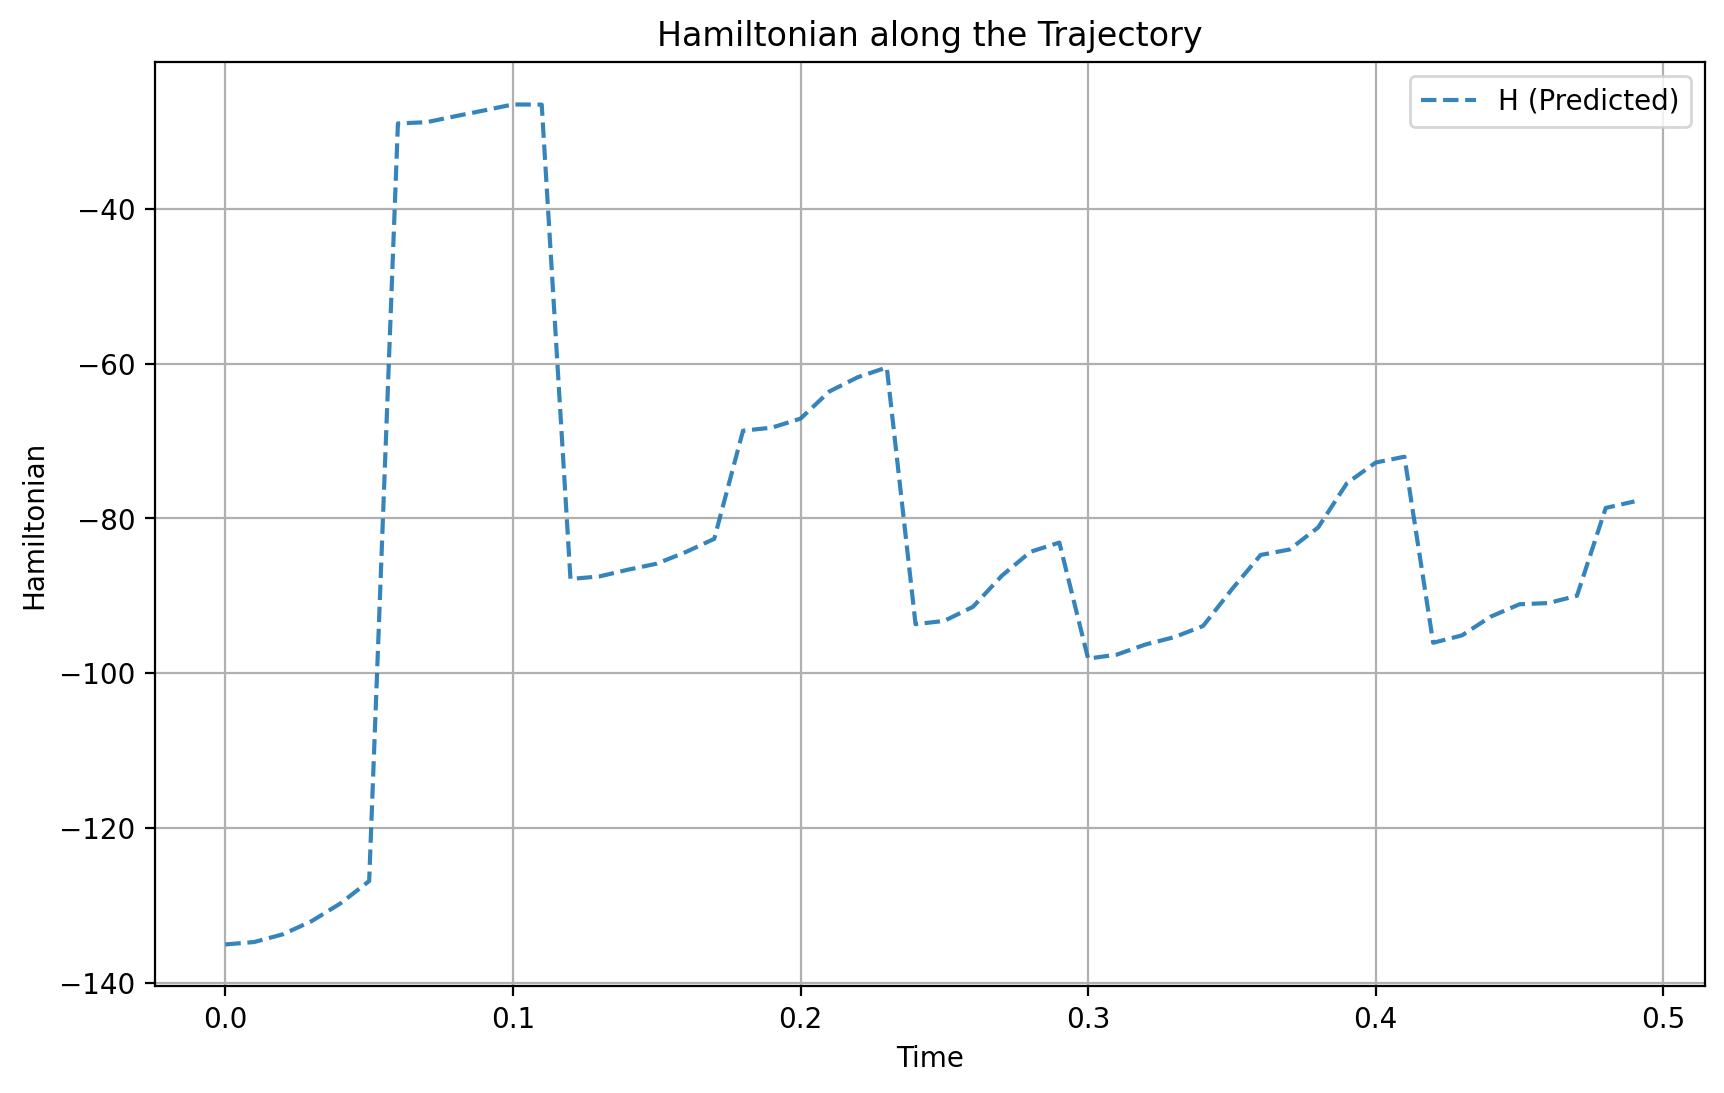

In [61]:
# --- Hamiltonian diagnostics ---
# Calculate true Hamiltonian along the trajectory
#H_true_vals = H_ground_truth(xt[:, :n], xt[:, n:], sim_params)

# Calculate predicted Hamiltonian along the trajectory
H_pred_vals = hnn_model.apply(params_hnn, jnp.concatenate([xt_pred[:, :n], xt_pred[:, n:]], axis=-1))

# Plot Hamiltonian values along the trajectory
plt.figure(figsize=(10, 6))
#plt.plot(t_vec[:min_len], H_true_vals[:min_len], label='H (Ground Truth)', alpha=0.7)
plt.plot(t_vec[:min_len], H_pred_vals[:min_len], '--', label='H (Predicted)', alpha=0.9)
plt.xlabel('Time')
plt.ylabel('Hamiltonian')
plt.title('Hamiltonian along the Trajectory')
plt.legend()
plt.grid(True)
plt.show()


# RMSE of models

In [62]:
plt.figure(figsize=(7, 4))
colors = {
    'our AAN': '#1f77b4',
    'original AAN': '#ff7f0e',
    'HNN': '#2ca02c',
}
model_curves = [
    ('our AAN', q_rmse_by_step, p_rmse_by_step),
    ('original AAN', q_rmse_by_step_orig_aan, p_rmse_by_step_orig_aan),
    ('HNN', q_rmse_by_step_hnn, p_rmse_by_step_hnn),
]
markers = {'q': 'o', 'p': 's'}
linestyles = {'q': '-', 'p': '--'}
for name, q_vals, p_vals in model_curves:
    color = colors[name]
    plt.plot(unique_steps_hnn, q_vals, marker=markers['q'], linestyle=linestyles['q'], color=color, label=f"{name} q")
    plt.plot(unique_steps_hnn, p_vals, marker=markers['p'], linestyle=linestyles['p'], color=color, label=f"{name} p")
plt.xticks(unique_steps_hnn)
plt.xlabel('prediction horizon (steps)')
plt.ylabel('RMSE')
plt.yscale('log')
plt.grid(True, alpha=0.4)
plt.title('RMSE vs prediction horizon')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.tight_layout()
plt.show()


NameError: name 'q_rmse_by_step_orig_aan' is not defined

<Figure size 700x400 with 0 Axes>

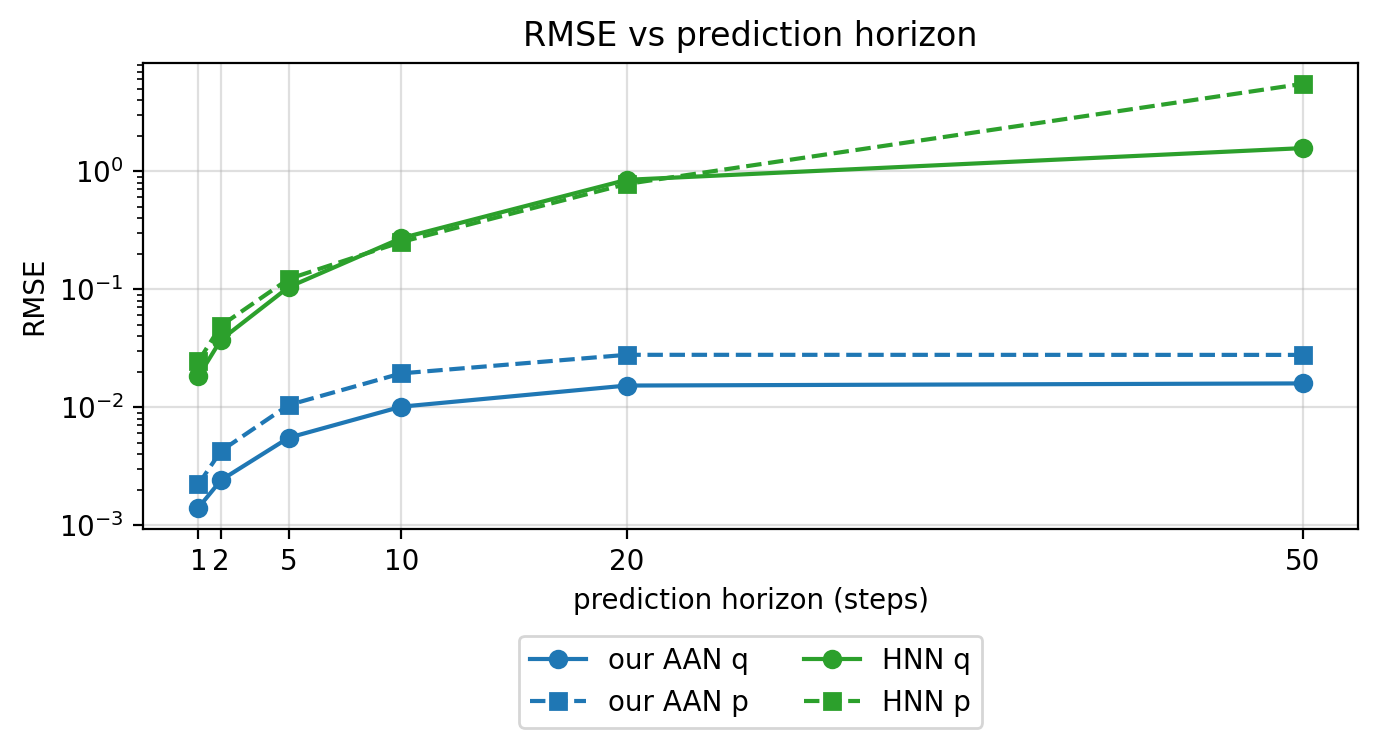

In [63]:
plt.figure(figsize=(7, 4))
colors = {
    'our AAN': '#1f77b4',
    'HNN': '#2ca02c',
}
model_curves = [
    ('our AAN', q_rmse_by_step, p_rmse_by_step),
    ('HNN', q_rmse_by_step_hnn, p_rmse_by_step_hnn),
]
markers = {'q': 'o', 'p': 's'}
linestyles = {'q': '-', 'p': '--'}
for name, q_vals, p_vals in model_curves:
    color = colors[name]
    plt.plot(unique_steps_hnn, q_vals, marker=markers['q'], linestyle=linestyles['q'], color=color, label=f"{name} q")
    plt.plot(unique_steps_hnn, p_vals, marker=markers['p'], linestyle=linestyles['p'], color=color, label=f"{name} p")
plt.xticks(unique_steps_hnn)
plt.xlabel('prediction horizon (steps)')
plt.ylabel('RMSE')
plt.yscale('log')
plt.grid(True, alpha=0.4)
plt.title('RMSE vs prediction horizon')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.tight_layout()
plt.show()


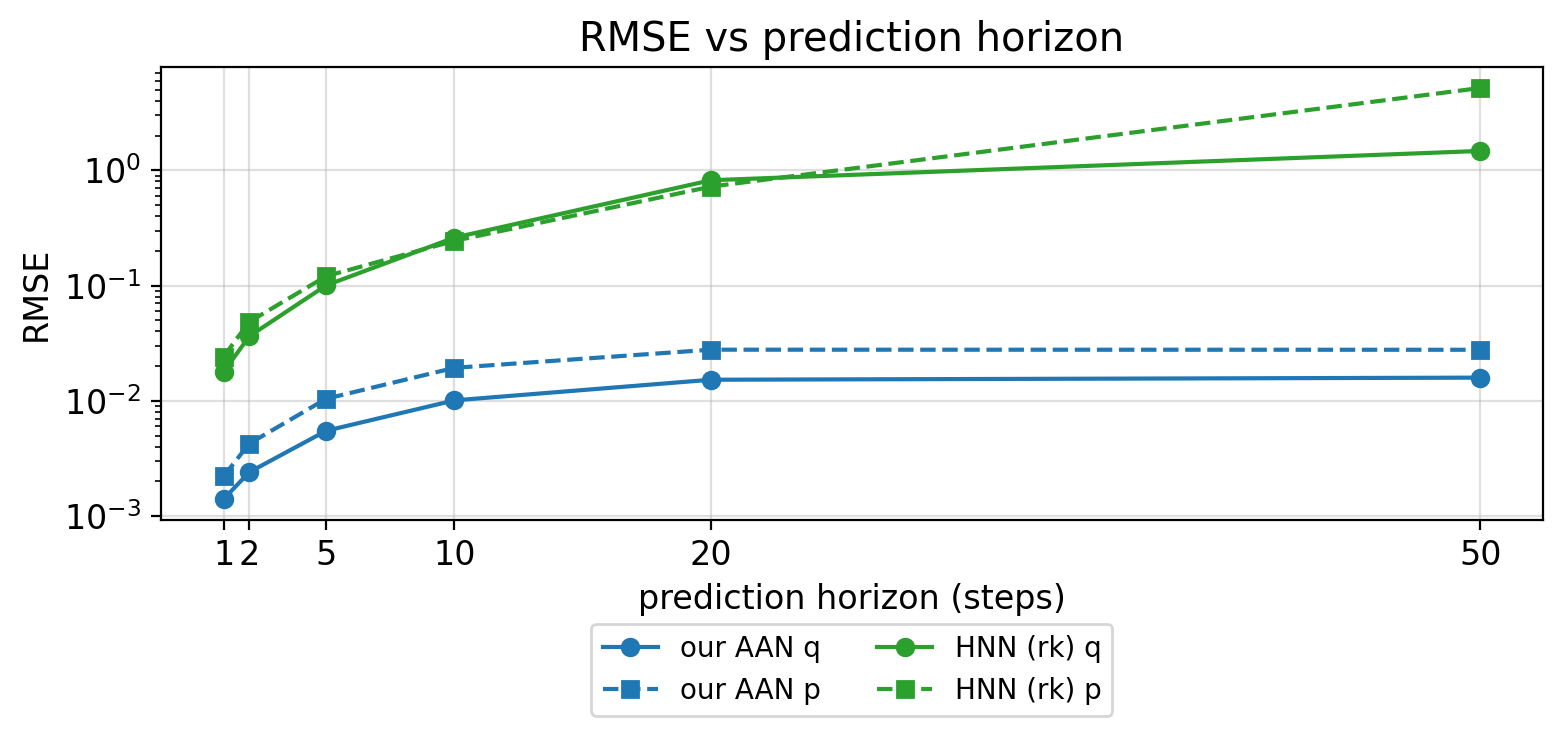

In [64]:
plt.rcParams["font.size"] = 12

fig, ax = plt.subplots(figsize=(8, 4))
#plt.figure(figsize=(8, 4))
colors = {
    'our AAN': '#1f77b4',
    'HNN (rk)': '#2ca02c',
}
model_curves = [
    ('our AAN', q_rmse_by_step, p_rmse_by_step),
    ('HNN (rk)', q_rmse_by_step_hnn_rk, p_rmse_by_step_hnn_rk),
]
markers = {'q': 'o', 'p': 's'}
linestyles = {'q': '-', 'p': '--'}
for name, q_vals, p_vals in model_curves:
    color = colors[name]
    plt.plot(unique_steps_hnn, q_vals, marker=markers['q'], linestyle=linestyles['q'], color=color, label=f"{name} q")
    plt.plot(unique_steps_hnn, p_vals, marker=markers['p'], linestyle=linestyles['p'], color=color, label=f"{name} p")
plt.xticks(unique_steps_hnn)
plt.xlabel('prediction horizon (steps)')
plt.ylabel('RMSE')
plt.yscale('log')
plt.grid(True, alpha=0.4)
plt.title('RMSE vs prediction horizon')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=10)
plt.tight_layout()
plt.show()

fig.savefig(str(proj_path / "results" / "e2025_1109_hhn_vs_aan_cleaner" / "ouraan_vs_hnn_rk.pdf"))

In [65]:
plt.figure(figsize=(7, 4))
colors = {
    'our AAN': '#1f77b4',
    'original AAN': '#ff7f0e',
    'HNN (rk)': '#2ca02c',
}
model_curves = [
    ('our AAN', q_rmse_by_step, p_rmse_by_step),
    ('original AAN', q_rmse_by_step_orig_aan, p_rmse_by_step_orig_aan),
    ('HNN (rk)', q_rmse_by_step_hnn_rk, p_rmse_by_step_hnn_rk),
]
markers = {'q': 'o', 'p': 's'}
linestyles = {'q': '-', 'p': '--'}
for name, q_vals, p_vals in model_curves:
    color = colors[name]
    plt.plot(unique_steps_hnn, q_vals, marker=markers['q'], linestyle=linestyles['q'], color=color, label=f"{name} q")
    plt.plot(unique_steps_hnn, p_vals, marker=markers['p'], linestyle=linestyles['p'], color=color, label=f"{name} p")
plt.xticks(unique_steps_hnn)
plt.xlabel('prediction horizon (steps)')
plt.ylabel('RMSE')
plt.yscale('log')
plt.grid(True, alpha=0.4)
plt.title('RMSE vs prediction horizon')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.tight_layout()
plt.show()


NameError: name 'q_rmse_by_step_orig_aan' is not defined

<Figure size 700x400 with 0 Axes>

# Trajectores in one fig

In [66]:
q_pred_direct_np.shape

(50, 4)

/tmp/1118436.4946/ipykernel_705193/852299386.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "--" (-> linestyle='--'). The keyword argument will take precedence.
  axes[0].plot(t_arr, q_pred_direct_np[:, i], '--', label=f'our AAN q[{i}]', alpha=0.8, color=colors['our AAN'], linestyle=linestyles[i])
/tmp/1118436.4946/ipykernel_705193/852299386.py:29: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "--" (-> linestyle='--'). The keyword argument will take precedence.
  axes[0].plot(t_short, q_hnn_pred_rk[:len(t_short), i], '--', label=f'HNN q[{i}] (RK4)', alpha=0.67, color=colors['HNN (rk)'], linestyle=linestyles[i])


KeyError: 2

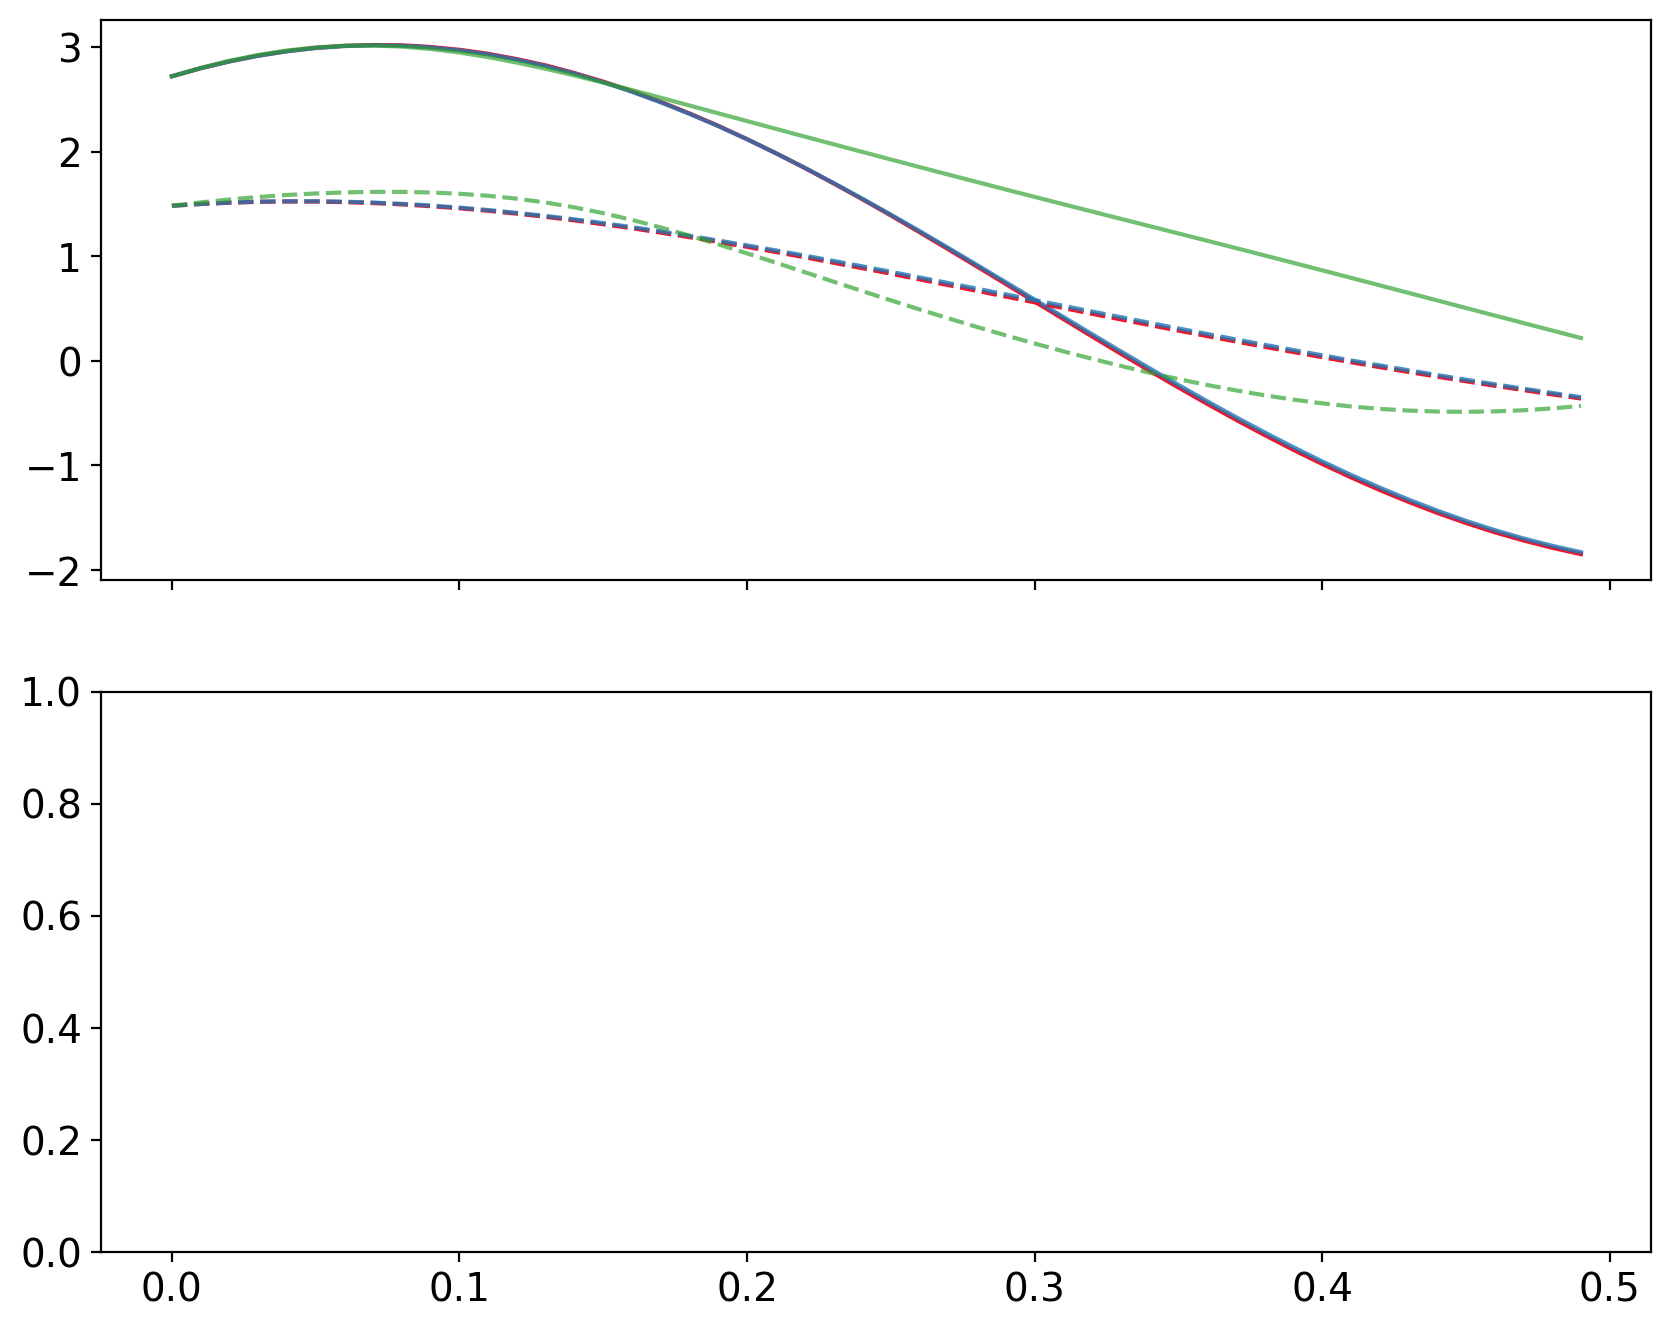

In [67]:
# --- 真値 vs モデル予測（同一初期値；直接推定）---

# delta_t_vec = jnp.arange(T_total) * dt

# q0_batch = jnp.repeat(q0, repeats=T_total, axis=0)
# p0_batch = jnp.repeat(p0, repeats=T_total, axis=0)

# q_pred_direct, p_pred_direct, _, _ = model.apply(
#     {'params': nn_params}, q0_batch, p0_batch, delta_t_vec, train=False
# )

# q_pred_direct_np = np.asarray(q_pred_direct)
# p_pred_direct_np = np.asarray(p_pred_direct)

plt.rcParams["font.size"] = 14

colors = {
    'gt': "#ED0C22",
    'our AAN': '#1f77b4',
    'HNN (rk)': '#2ca02c',
}
linestyles = {0: '-', 1: '--'}

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for i in range(q_pred_direct_np.shape[1]):
    axes[0].plot(t_arr, q_true_np[:, i], label=f'Ground trueth q[{i}]', linewidth=1.5, alpha=0.96, color=colors['gt'], linestyle=linestyles[i])
    axes[0].plot(t_arr, q_pred_direct_np[:, i], '--', label=f'our AAN q[{i}]', alpha=0.8, color=colors['our AAN'], linestyle=linestyles[i])
    axes[0].plot(t_short, q_hnn_pred_rk[:len(t_short), i], '--', label=f'HNN q[{i}] (RK4)', alpha=0.67, color=colors['HNN (rk)'], linestyle=linestyles[i])
axes[0].set_ylabel('q')
axes[0].grid(True)
axes[0].legend(loc='lower left', bbox_to_anchor=(0, 0), ncol=2, fontsize=12)


for i in range(p_pred_direct_np.shape[1]):
    axes[1].plot(t_arr, p_true_np[:, i], label=f'Ground truth p[{i}]', linewidth=1.5,alpha=0.96, color=colors['gt'], linestyle=linestyles[i])
    axes[1].plot(t_arr, p_pred_direct_np[:, i], '--', label=f'our AAN p[{i}]', alpha=0.8, color=colors['our AAN'], linestyle=linestyles[i])
    axes[1].plot(t_short, p_hnn_pred_rk[:len(t_short), i], '--', label=f'HNN p[{i}] (RK4)', alpha=0.67, color=colors['HNN (rk)'], linestyle=linestyles[i])
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].grid(True)
axes[1].legend(loc='lower left', bbox_to_anchor=(0, 0),ncol=2, fontsize=12)


plt.tight_layout()
plt.show()

fig.savefig(str(proj_path / "results" / "e2025_1109_hhn_vs_aan_cleaner" / "ouraan_vs_hnn_rk_trajs.pdf"), bbox_inches="tight")